# Higuchi Fractal Dimension

In [1]:
import importlib

# List of libraries to check
libraries = [
    'numpy',
    'matplotlib',
    'scipy',
    'torch',
    'torchdiffeq',
    'torchsummary',
    'minepy',
    'pyrqa',
    'pyts',
    'MFDFA',
    'pyinform',
    'graphviz',
    'fa2',
    'networkx'
]

for lib in libraries:
    try:
        module = importlib.import_module(lib)
        version = getattr(module, '__version__', 'Unknown version')
        print(f'{lib}: {version}')
    except ImportError:
        print(f'{lib} is not installed.')

numpy: 1.24.3
matplotlib: 3.7.0
scipy: 1.10.1
torch: 2.0.1+cu117
torchdiffeq: 0.2.3
torchsummary: Unknown version
minepy: b'1.2.6'
pyrqa: Unknown version
pyts: 0.12.0
MFDFA: 0.4.3
pyinform: Unknown version
graphviz: 0.20.1
fa2 is not installed.
networkx: 3.0


<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>
            This code calculates the Higuchi Fractal Dimension (HFD) of EEG signals for multiple channels.
            Fractal dimensions are used to quantify the complexity of a data series, which is particularly useful in neuroscience for understanding the complexity of brain activity.
        </p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <p>
            The code uses the Higuchi Fractal Dimension algorithm, which is computationally efficient and particularly useful for analyzing time series data. It works by evaluating the length of the curve created by the data points at different scales.
        </p>
        \[
        L_k = \frac{N-1}{\left\lfloor \frac{N-m}{k} \right\rfloor k} \sum_{m=0}^{k-1} \left[ \sum_{i=1}^{\left\lfloor \frac{N-m}{k} \right\rfloor} \left| x[m+i \cdot k] - x[m+i \cdot k - k] \right| \right]
        \]
        \[
        HFD = \frac{\log(L_{k2}/L_{k1})}{\log(k2/k1)}
        \]
        <p>
            Here, \( L_k \) is the length of the curve for a given \( k \) (delay or time offset). \( N \) is the length of the data, \( x \) is the time series data, and \( m \) is the initial time point for each \( k \).
        </p>
        <p>
            Finally, the HFD values for each channel are stored in the list <code>hfd_values</code>.
        </p>
    </div>
</div>

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec

Higuchi Fractal Dimensions:
   channel  higuchi_fd
0       Fz    1.799540
1      Fpz    1.784749
2      Fp2    1.767727
3       F4    1.763464
4       M2    1.755839
5      Fp1    1.754232
6      FC2    1.751964
7       F8    1.749053
8      FC6    1.742346
9       O2    1.740253
10      T8    1.738121
11      C4    1.737588
12      Oz    1.736772
13      M1    1.734845
14      P4    1.733283
15      O1    1.730683
16     CP2    1.728402
17     CP6    1.726091
18      Cz    1.725796
19     POz    1.725315
20      Pz    1.721862
21     FC1    1.715543
22      F3    1.712586
23      F7    1.710568
24      P3    1.709655
25     CP1    1.707372
26     CP5    1.699183
27      P8    1.695703
28      P7    1.688438
29      C3    1.675265
30      T7    1.673584
31     FC5    1.672366


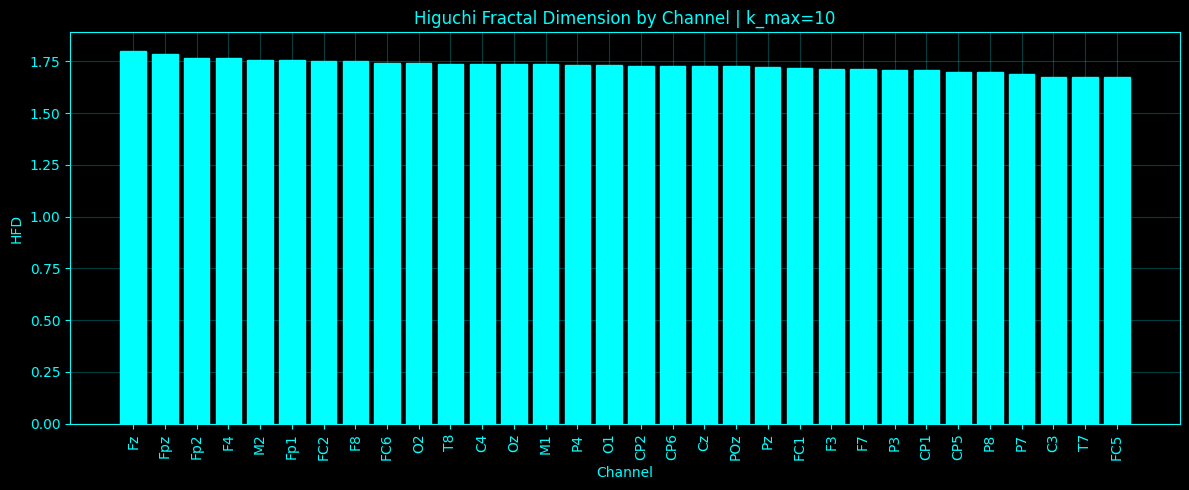

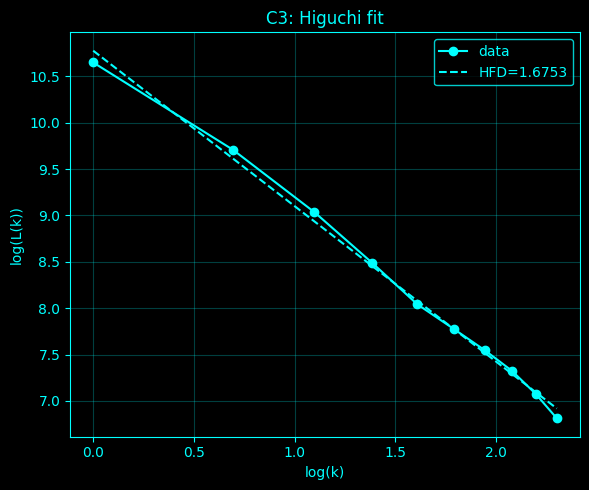


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/higuchi_fd_summary.csv
Curves NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/fractal_dimension_higuchi/higuchi_fd_curves.npz


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "fractal_dimension_higuchi")
os.makedirs(out_dir, exist_ok=True)

# Same segment used in your recent analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

k_max = 10

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_time, n_channels = EEG_segment.shape
print(f"Loaded EEG segment: {n_time} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# HIGUCHI FRACTAL DIMENSION
# -------------------------------------------------------
def higuchi_fd(x, k_max=10):
    """
    Compute Higuchi Fractal Dimension for a 1D time series.

    Notes:
    L(k) ~ k^{-D}
    so if we fit log(L(k)) vs log(k), then D = -slope
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    if N < k_max + 2:
        return np.nan, None, None

    Lk = []
    k_vals = np.arange(1, k_max + 1)

    for k in k_vals:
        Lm_vals = []

        for m in range(k):
            n_max = (N - m - 1) // k
            if n_max < 1:
                continue

            idx1 = m + np.arange(1, n_max + 1) * k
            idx0 = m + np.arange(0, n_max) * k

            diffs = np.abs(x[idx1] - x[idx0]).sum()

            # Standard Higuchi normalization
            Lmk = diffs * (N - 1) / (n_max * k * k)
            Lm_vals.append(Lmk)

        if len(Lm_vals) == 0:
            Lk.append(np.nan)
        else:
            Lk.append(np.mean(Lm_vals))

    Lk = np.asarray(Lk, dtype=float)

    mask = np.isfinite(Lk) & (Lk > 0)
    if np.sum(mask) < 2:
        return np.nan, k_vals, Lk

    slope = np.polyfit(np.log(k_vals[mask]), np.log(Lk[mask]), 1)[0]
    hfd = -slope
    return hfd, k_vals, Lk

# -------------------------------------------------------
# RUN HFD PER CHANNEL
# -------------------------------------------------------
rows = []
curves = {}

for ch_idx, ch_name in enumerate(eeg_channels):
    x = EEG_segment[:, ch_idx].astype(float)
    x = (x - np.mean(x)) / (np.std(x) + 1e-12)

    hfd, k_vals, Lk = higuchi_fd(x, k_max=k_max)

    rows.append({
        "channel": ch_name,
        "higuchi_fd": hfd
    })

    curves[ch_name] = {
        "k_vals": k_vals,
        "Lk": Lk
    }

results_df = pd.DataFrame(rows).sort_values("higuchi_fd", ascending=False).reset_index(drop=True)

csv_path = os.path.join(out_dir, "higuchi_fd_summary.csv")
results_df.to_csv(csv_path, index=False)

print("\nHiguchi Fractal Dimensions:")
print(results_df)

# -------------------------------------------------------
# PLOT 1: BAR PLOT OF HFD BY CHANNEL
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    results_df["channel"],
    results_df["higuchi_fd"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title(f"Higuchi Fractal Dimension by Channel | k_max={k_max}")
ax.set_xlabel("Channel")
ax.set_ylabel("HFD")
ax.tick_params(axis="x", rotation=90)

bar_path = os.path.join(out_dir, "higuchi_fd_barplot.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: EXAMPLE LOG-L(k) FIT FOR C3
# -------------------------------------------------------
example_channel = "C3"
if example_channel in curves and curves[example_channel]["k_vals"] is not None:
    k_vals = curves[example_channel]["k_vals"]
    Lk = curves[example_channel]["Lk"]

    mask = np.isfinite(Lk) & (Lk > 0)
    if np.sum(mask) >= 2:
        logk = np.log(k_vals[mask])
        logL = np.log(Lk[mask])
        slope, intercept = np.polyfit(logk, logL, 1)
        fit_line = slope * logk + intercept
        hfd_example = -slope

        fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
        style_ax(ax)

        ax.plot(
            logk, logL,
            marker="o",
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            label="data"
        )
        ax.plot(
            logk, fit_line,
            color=ACCENT,
            linestyle="--",
            label=f"HFD={hfd_example:.4f}"
        )

        ax.set_title(f"{example_channel}: Higuchi fit")
        ax.set_xlabel("log(k)")
        ax.set_ylabel("log(L(k))")
        ax.legend()

        fit_path = os.path.join(out_dir, f"{example_channel}_higuchi_fit.png")
        plt.tight_layout()
        plt.savefig(fit_path, dpi=160, bbox_inches="tight")
        plt.show()
        plt.close()

# -------------------------------------------------------
# SAVE ALL CURVES
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "higuchi_fd_curves.npz")
save_dict = {}
for ch_name, d in curves.items():
    if d["k_vals"] is not None:
        save_dict[f"{ch_name}_k_vals"] = d["k_vals"]
        save_dict[f"{ch_name}_Lk"] = d["Lk"]

np.savez(npz_path, **save_dict)

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {csv_path}")
print(f"Curves NPZ: {npz_path}")


Channel: Fp1
  m= 2 | n=106940 | boxFD= 1.6024 | D2= 1.9110 | fitPts=15
  m= 3 | n=106936 | boxFD= 1.9638 | D2= 2.6236 | fitPts=14
  m= 4 | n=106932 | boxFD= 2.2119 | D2= 3.0658 | fitPts=14
  m= 5 | n=106928 | boxFD= 2.3270 | D2= 3.3563 | fitPts=13
  m= 6 | n=106924 | boxFD= 2.3110 | D2= 3.6856 | fitPts=13
  m= 7 | n=106920 | boxFD= 2.1917 | D2= 3.8203 | fitPts=13
  m= 8 | n=106916 | boxFD= 2.0231 | D2= 4.0556 | fitPts=13
  m= 9 | n=106912 | boxFD= 1.8271 | D2= 4.2264 | fitPts=13
  m=10 | n=106908 | boxFD= 1.6269 | D2= 4.3401 | fitPts=13

Channel: Fpz
  m= 2 | n=106940 | boxFD= 1.6153 | D2= 1.8747 | fitPts=14
  m= 3 | n=106936 | boxFD= 2.0502 | D2= 2.4104 | fitPts=13
  m= 4 | n=106932 | boxFD= 2.2812 | D2= 2.7114 | fitPts=13
  m= 5 | n=106928 | boxFD= 2.3646 | D2= 2.9608 | fitPts=13
  m= 6 | n=106924 | boxFD= 2.3404 | D2= 3.1028 | fitPts=13
  m= 7 | n=106920 | boxFD= 2.2159 | D2= 3.3853 | fitPts=12
  m= 8 | n=106916 | boxFD= 2.0393 | D2= 3.4386 | fitPts=12
  m= 9 | n=106912 | boxFD= 1

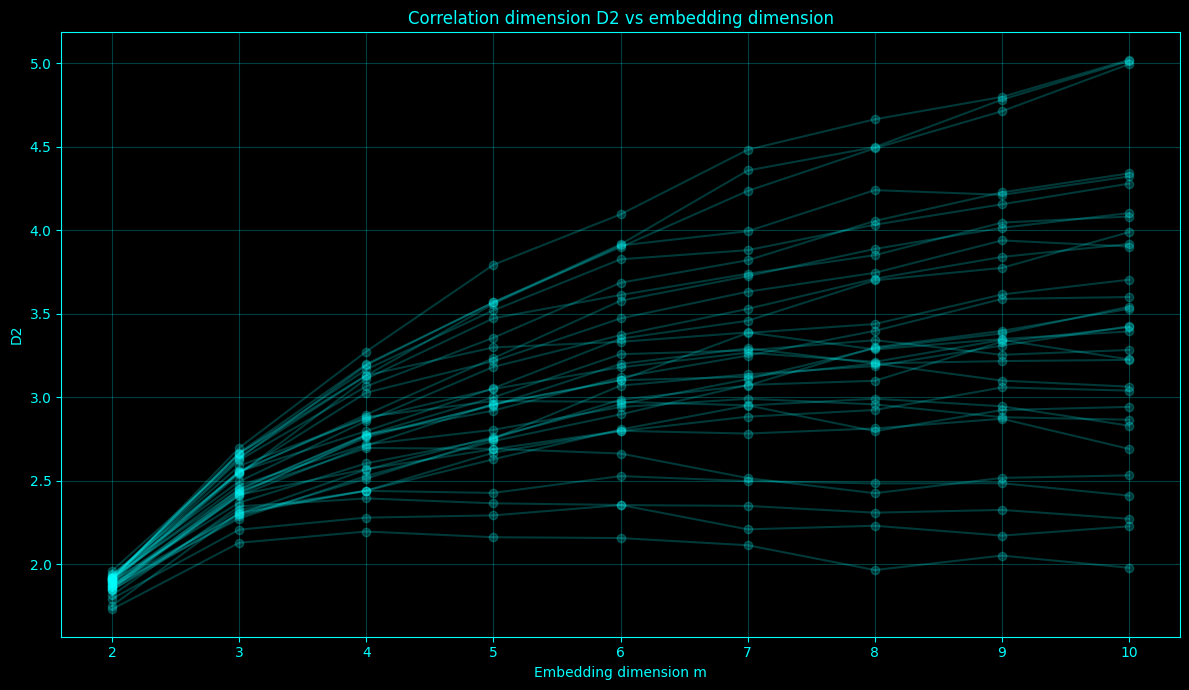

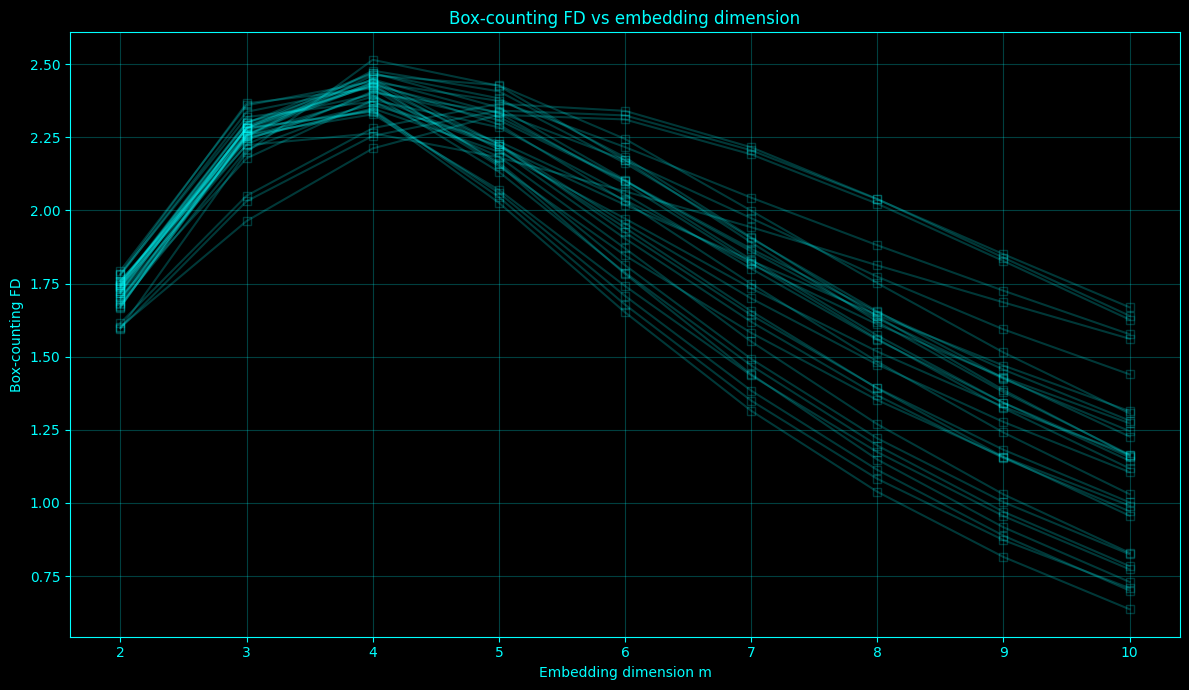

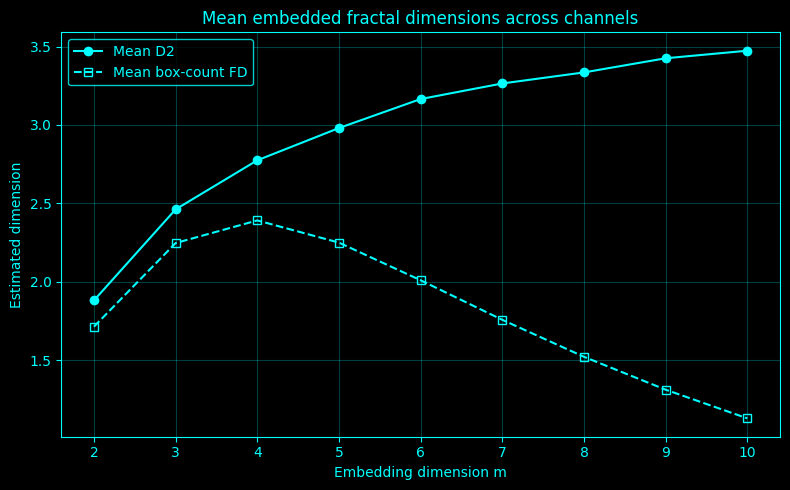

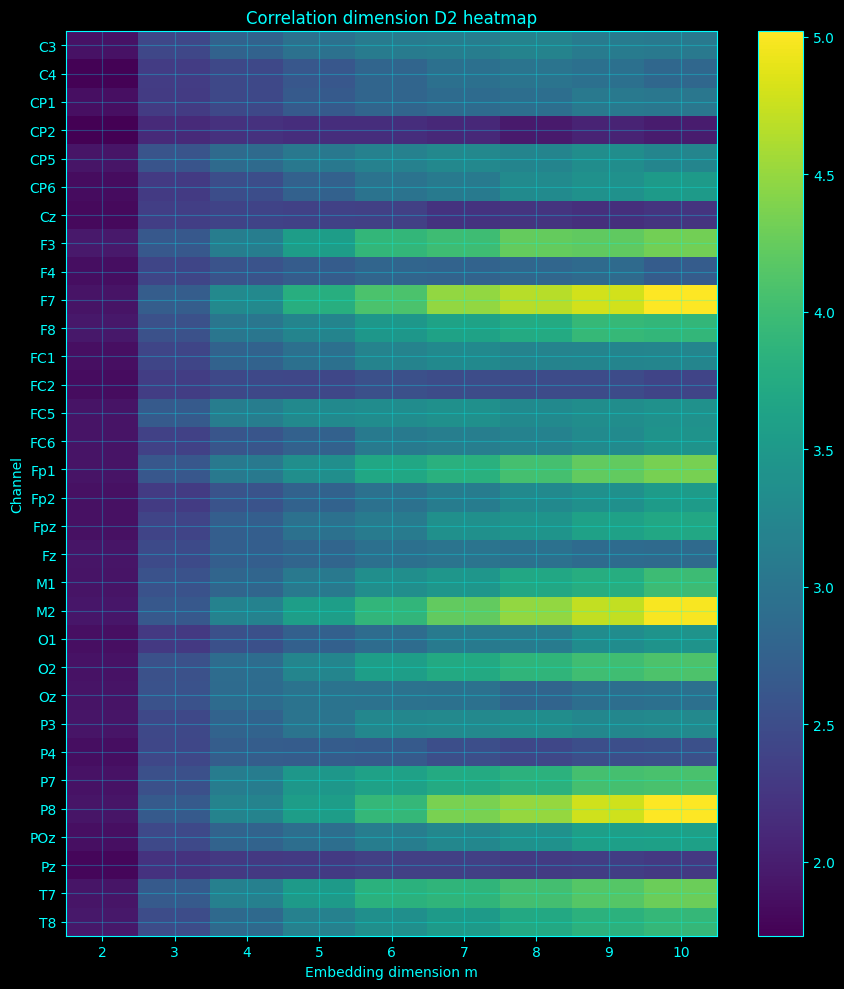

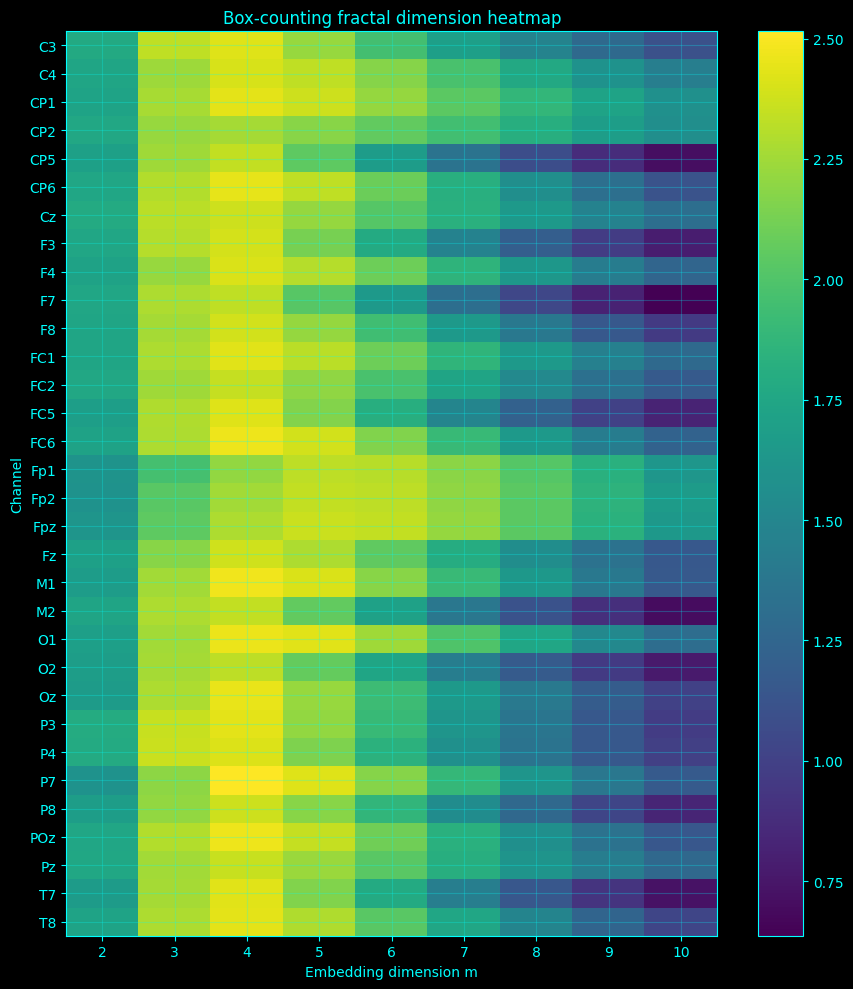


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/embedded_fractal_dimension_research
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/embedded_fractal_dimension_research/embedded_fractal_dimension_summary.csv
Summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/embedded_fractal_dimension_research/embedded_fractal_dimension_summary.txt


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_2d_dir = os.path.join(base_dir, "embedding_data", "2dembedding_data")
embedding_3d_dir = os.path.join(base_dir, "embedding_data", "3dembedding_data")
embedding_4to10_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")

out_dir = os.path.join(base_dir, "embedded_fractal_dimension_research")
os.makedirs(out_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

embedding_dims = list(range(2, 11))

# Correlation dimension settings
corr_subsample_n = 2500
corr_n_pairs = 200000
corr_n_r = 28
corr_cmin = 1e-4
corr_cmax = 1e-1

# Box-counting settings
box_eps = np.logspace(np.log10(1/6), np.log10(1/80), 12)

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

rng = np.random.default_rng(0)

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# PATH HELPERS
# -------------------------------------------------------
def embedding_path(channel_name, emb_dim):
    if emb_dim == 2:
        return os.path.join(embedding_2d_dir, f"2dembedded_{channel_name}.npy")
    elif emb_dim == 3:
        return os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")
    elif 4 <= emb_dim <= 10:
        return os.path.join(embedding_4to10_dir, f"{emb_dim}dembedded_{channel_name}.npy")
    else:
        return None

# -------------------------------------------------------
# NUMERICAL HELPERS
# -------------------------------------------------------
def standardize_cols(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def rescale_to_unit_cube(X):
    X = np.asarray(X, dtype=float)
    xmin = np.min(X, axis=0, keepdims=True)
    xmax = np.max(X, axis=0, keepdims=True)
    rngv = xmax - xmin
    rngv[rngv < 1e-12] = 1.0
    return (X - xmin) / rngv

# -------------------------------------------------------
# BOX-COUNTING DIMENSION
# -------------------------------------------------------
def box_counting_dimension(X, eps_vals):
    """
    Estimate box-counting dimension of a point cloud in R^m.
    """
    X = np.asarray(X, dtype=float)
    X = standardize_cols(X)
    X = rescale_to_unit_cube(X)

    counts = []
    inv_eps = []

    for eps in eps_vals:
        # bin index for each point
        bins = np.floor(X / eps).astype(np.int64)
        bins = np.clip(bins, 0, int(np.ceil(1 / eps)) + 2)

        unique_boxes = np.unique(bins, axis=0)
        n_boxes = len(unique_boxes)

        if n_boxes > 0:
            counts.append(n_boxes)
            inv_eps.append(1.0 / eps)

    counts = np.asarray(counts, dtype=float)
    inv_eps = np.asarray(inv_eps, dtype=float)

    mask = np.isfinite(counts) & (counts > 0) & np.isfinite(inv_eps) & (inv_eps > 0)
    if np.sum(mask) < 3:
        return np.nan, inv_eps, counts, None

    logx = np.log(inv_eps[mask])
    logy = np.log(counts[mask])

    coef = np.polyfit(logx, logy, 1)
    dim_est = float(coef[0])
    fit_line = np.polyval(coef, logx)

    return dim_est, inv_eps[mask], counts[mask], fit_line

# -------------------------------------------------------
# CORRELATION DIMENSION (SAMPLED)
# -------------------------------------------------------
def correlation_dimension_sampled(X, subsample_n=2500, n_pairs=200000, n_r=28,
                                  cmin=1e-4, cmax=1e-1, rng=None):
    """
    Sampled Grassberger-Procaccia style D2 estimate.
    """
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X, dtype=float)
    X = standardize_cols(X)

    N = len(X)
    if N < 50:
        return np.nan, None, None, None, 0

    if N > subsample_n:
        idx = np.sort(rng.choice(N, size=subsample_n, replace=False))
        X = X[idx]
        N = len(X)

    # sample random pairs
    i = rng.integers(0, N, size=n_pairs)
    j = rng.integers(0, N, size=n_pairs)
    keep = i != j
    i = i[keep]
    j = j[keep]

    if len(i) < 1000:
        return np.nan, None, None, None, 0

    d = np.linalg.norm(X[i] - X[j], axis=1)
    d = d[np.isfinite(d) & (d > 0)]

    if len(d) < 1000:
        return np.nan, None, None, None, 0

    qlo = np.quantile(d, 0.01)
    qhi = np.quantile(d, 0.50)

    if not np.isfinite(qlo) or not np.isfinite(qhi) or qhi <= qlo:
        return np.nan, None, None, None, 0

    rs = np.logspace(np.log10(qlo), np.log10(qhi), n_r)
    Cs = np.array([np.mean(d < r) for r in rs], dtype=float)

    mask = np.isfinite(Cs) & (Cs > cmin) & (Cs < cmax) & np.isfinite(rs) & (rs > 0)
    n_fit = int(np.sum(mask))

    if n_fit < 4:
        return np.nan, rs, Cs, None, n_fit

    log_r = np.log(rs[mask])
    log_C = np.log(Cs[mask])

    coef = np.polyfit(log_r, log_C, 1)
    d2_est = float(coef[0])
    fit_line = np.polyval(coef, log_r)

    return d2_est, rs, Cs, fit_line, n_fit

# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
rows = []

for channel_name in eeg_channel_names:
    print(f"\nChannel: {channel_name}")

    for emb_dim in embedding_dims:
        fpath = embedding_path(channel_name, emb_dim)
        if fpath is None or not os.path.exists(fpath):
            print(f"  Missing m={emb_dim}")
            continue

        X = np.load(fpath)
        if X.ndim != 2:
            print(f"  Bad shape for m={emb_dim}: {X.shape}")
            continue

        # box-counting FD
        box_fd, inv_eps_fit, counts_fit, box_fit_line = box_counting_dimension(X, box_eps)

        # sampled correlation dimension
        d2_fd, rs, Cs, d2_fit_line, n_fit = correlation_dimension_sampled(
            X,
            subsample_n=corr_subsample_n,
            n_pairs=corr_n_pairs,
            n_r=corr_n_r,
            cmin=corr_cmin,
            cmax=corr_cmax,
            rng=rng
        )

        rows.append({
            "channel": channel_name,
            "emb_dim": emb_dim,
            "n_points": len(X),
            "ambient_dim": X.shape[1],
            "boxcount_fd": box_fd,
            "corr_dim_d2": d2_fd,
            "corr_fit_points": n_fit
        })

        print(
            f"  m={emb_dim:2d} | n={len(X):6d} | "
            f"boxFD={box_fd:7.4f} | D2={d2_fd:7.4f} | fitPts={n_fit}"
        )

# -------------------------------------------------------
# SAVE SUMMARY TABLE
# -------------------------------------------------------
results_df = pd.DataFrame(rows)
results_csv = os.path.join(out_dir, "embedded_fractal_dimension_summary.csv")
results_df.to_csv(results_csv, index=False)

print("\nSummary table:")
print(results_df)

# -------------------------------------------------------
# PLOT 1: D2 vs embedding dimension for each channel
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
style_ax(ax)

for channel_name in eeg_channel_names:
    sub = results_df[results_df["channel"] == channel_name].sort_values("emb_dim")
    if len(sub) == 0:
        continue

    ax.plot(
        sub["emb_dim"],
        sub["corr_dim_d2"],
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.22
    )

ax.set_title("Correlation dimension D2 vs embedding dimension")
ax.set_xlabel("Embedding dimension m")
ax.set_ylabel("D2")
plot1_path = os.path.join(out_dir, "corr_dimension_vs_embedding_dim_all_channels.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: Box-counting FD vs embedding dimension for each channel
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
style_ax(ax)

for channel_name in eeg_channel_names:
    sub = results_df[results_df["channel"] == channel_name].sort_values("emb_dim")
    if len(sub) == 0:
        continue

    ax.plot(
        sub["emb_dim"],
        sub["boxcount_fd"],
        marker="s",
        color=ACCENT,
        markerfacecolor="none",
        markeredgecolor=ACCENT,
        alpha=0.22
    )

ax.set_title("Box-counting FD vs embedding dimension")
ax.set_xlabel("Embedding dimension m")
ax.set_ylabel("Box-counting FD")
plot2_path = os.path.join(out_dir, "boxcount_dimension_vs_embedding_dim_all_channels.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: Mean across channels
# -------------------------------------------------------
mean_df = (
    results_df.groupby("emb_dim")[["boxcount_fd", "corr_dim_d2"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

ax.plot(
    mean_df["emb_dim"],
    mean_df["corr_dim_d2"],
    marker="o",
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT,
    label="Mean D2"
)
ax.plot(
    mean_df["emb_dim"],
    mean_df["boxcount_fd"],
    marker="s",
    color=ACCENT,
    markerfacecolor="none",
    markeredgecolor=ACCENT,
    linestyle="--",
    label="Mean box-count FD"
)

ax.set_title("Mean embedded fractal dimensions across channels")
ax.set_xlabel("Embedding dimension m")
ax.set_ylabel("Estimated dimension")
ax.legend()

plot3_path = os.path.join(out_dir, "mean_embedded_fractal_dimensions.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: Heatmap of D2
# -------------------------------------------------------
pivot_d2 = results_df.pivot_table(
    index="channel",
    columns="emb_dim",
    values="corr_dim_d2",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(9, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(pivot_d2.values, aspect="auto")
ax.set_title("Correlation dimension D2 heatmap")
ax.set_xlabel("Embedding dimension m")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(pivot_d2.columns)))
ax.set_xticklabels(pivot_d2.columns, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_d2.index)))
ax.set_yticklabels(pivot_d2.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plot4_path = os.path.join(out_dir, "corr_dimension_heatmap.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: Heatmap of box-counting FD
# -------------------------------------------------------
pivot_box = results_df.pivot_table(
    index="channel",
    columns="emb_dim",
    values="boxcount_fd",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(9, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(pivot_box.values, aspect="auto")
ax.set_title("Box-counting fractal dimension heatmap")
ax.set_xlabel("Embedding dimension m")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(pivot_box.columns)))
ax.set_xticklabels(pivot_box.columns, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_box.index)))
ax.set_yticklabels(pivot_box.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plot5_path = os.path.join(out_dir, "boxcount_dimension_heatmap.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "embedded_fractal_dimension_summary.txt")
with open(txt_path, "w") as f:
    f.write("Fractal dimension of embedded EEG attractors\n")
    f.write("==========================================\n\n")
    f.write("Computed on saved 2D, 3D, and 4D..10D embeddings.\n")
    f.write("Metrics:\n")
    f.write("  1) Box-counting fractal dimension\n")
    f.write("  2) Sampled correlation dimension D2\n\n")

    f.write("Mean by embedding dimension:\n")
    for _, row in mean_df.iterrows():
        f.write(
            f"m={int(row['emb_dim'])}: "
            f"mean_boxFD={row['boxcount_fd']:.6f}, "
            f"mean_D2={row['corr_dim_d2']:.6f}\n"
        )

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {results_csv}")
print(f"Summary TXT: {txt_path}")

Loaded summary:
  channel  emb_dim         D
0      C3        2  1.887070
1      C3        3  2.429531
2      C3        4  2.760086
3      C3        5  2.956774
4      C3        6  3.101867

Saturation summary:
   channel  m_min  m_max     D2_m2   D2_mmax  D2_total_gain  mean_delta_D2  \
10     FC2    2.0   10.0  1.845340  2.411511       0.566172       0.070771   
25      Pz    2.0   10.0  1.794332  2.272540       0.478208       0.059776   
15      Cz    2.0   10.0  1.814592  2.227675       0.413084       0.051635   
21     CP2    2.0   10.0  1.731433  1.979492       0.248059       0.031007   
6       F4    2.0   10.0  1.853297  2.690964       0.837667       0.104708   
26      P4    2.0   10.0  1.851545  2.532727       0.681182       0.085148   
30      Oz    2.0   10.0  1.909665  2.942559       1.032895       0.129112   
16      C4    2.0   10.0  1.751866  2.829935       1.078069       0.134759   
4       F3    2.0   10.0  1.961742  4.321722       2.359979       0.294997   
8      FC

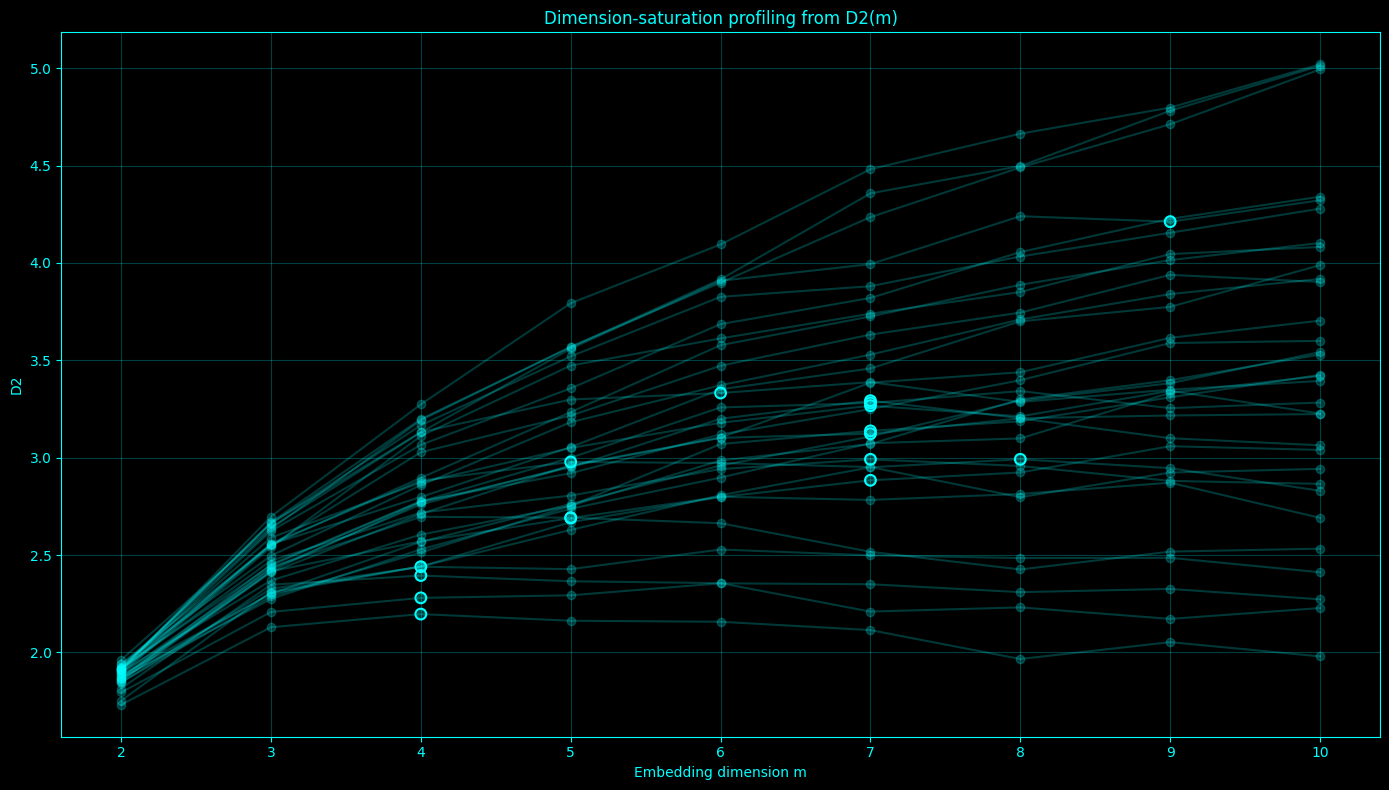

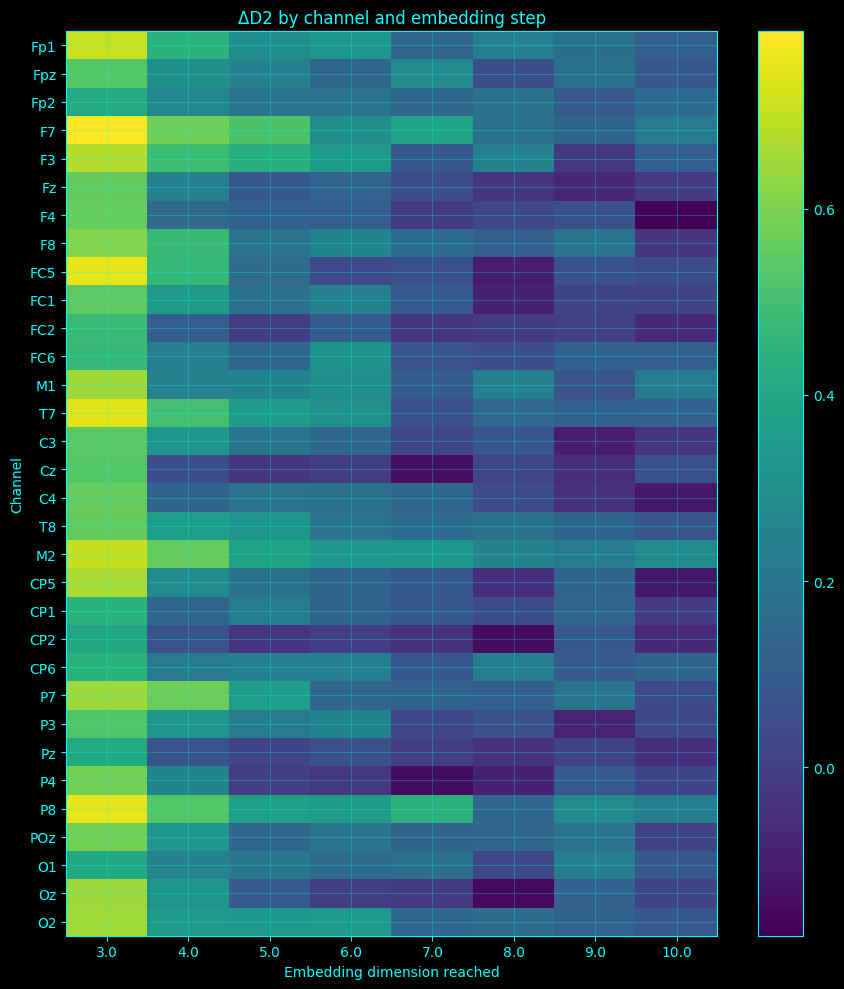

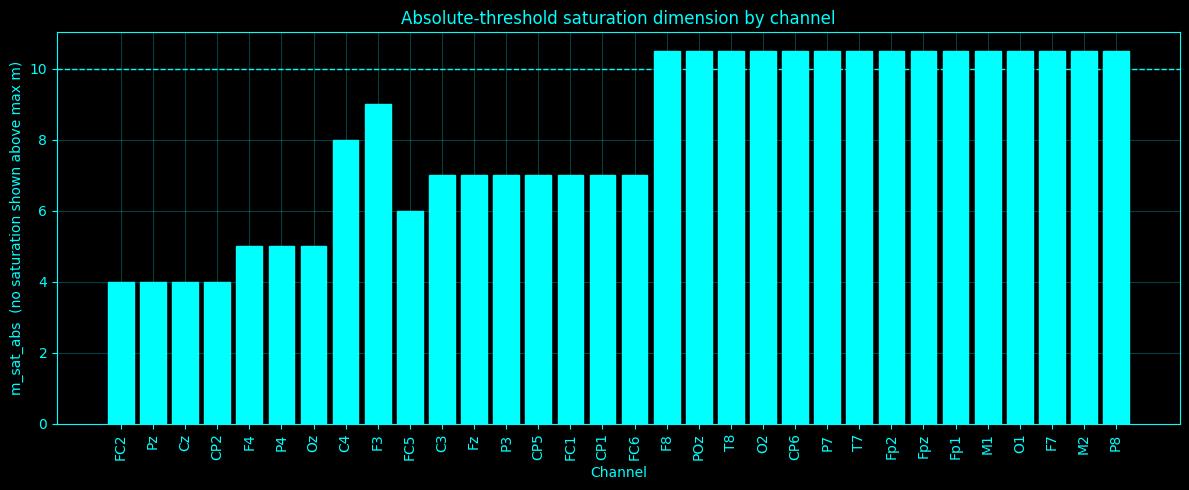

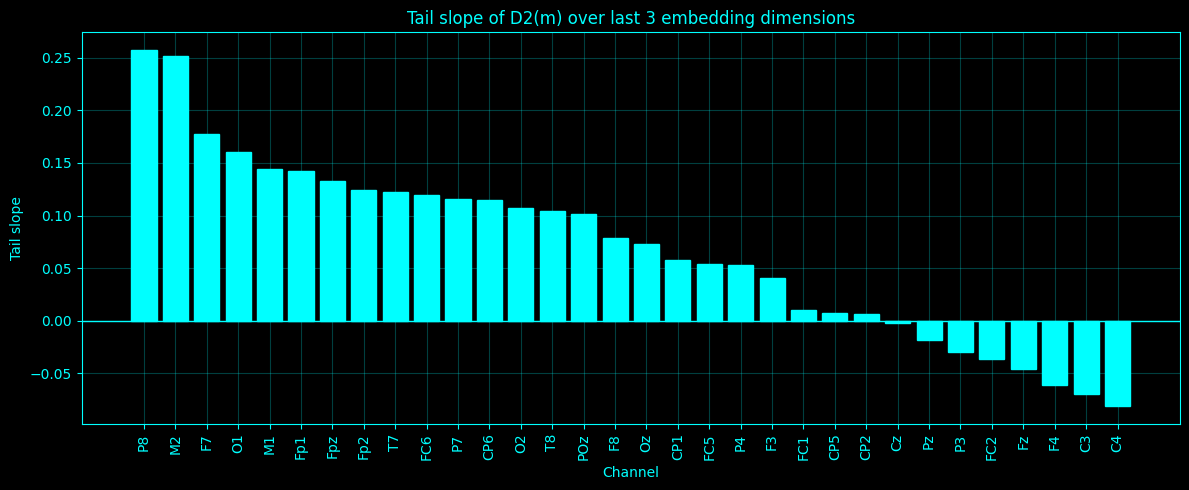

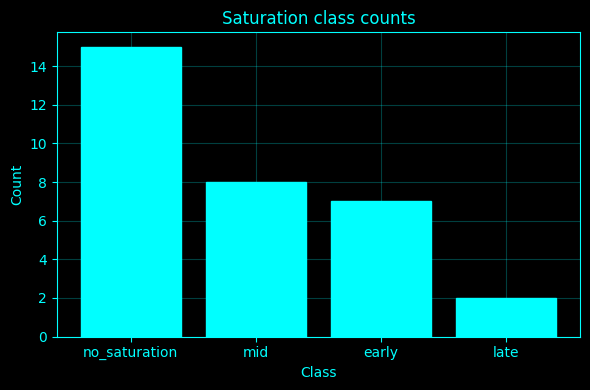


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling
Summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_summary.csv
Delta CSV: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_deltas.csv
Summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/dimension_saturation_profiling/dimension_saturation_summary.txt


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
source_csv = os.path.join(base_dir, "embedded_fractal_dimension_research", "embedded_fractal_dimension_summary.csv")
out_dir = os.path.join(base_dir, "dimension_saturation_profiling")
os.makedirs(out_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Saturation rules
use_metric = "corr_dim_d2"   # use D2, not box-counting
abs_delta_thresh = 0.12      # absolute saturation threshold on ΔD2
rel_delta_thresh = 0.04      # relative saturation threshold on ΔD2 / D2
n_consecutive = 2            # require this many consecutive small increments
tail_points = 3              # slope over final tail

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def first_consecutive_true(mask, n_consecutive=2):
    """
    mask is length K for steps between m_i and m_{i+1}
    returns starting index of first run of n_consecutive True
    """
    mask = np.asarray(mask, dtype=bool)
    if len(mask) < n_consecutive:
        return None

    run = 0
    for i, val in enumerate(mask):
        if val:
            run += 1
            if run >= n_consecutive:
                return i - n_consecutive + 1
        else:
            run = 0
    return None

def tail_slope(x, y, tail_points=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < max(2, tail_points):
        return np.nan

    x_tail = x[-tail_points:]
    y_tail = y[-tail_points:]
    coef = np.polyfit(x_tail, y_tail, 1)
    return float(coef[0])

def classify_saturation(m_sat, max_m):
    if pd.isna(m_sat):
        return "no_saturation"
    if m_sat <= 5:
        return "early"
    if m_sat <= 7:
        return "mid"
    if m_sat <= max_m - 1:
        return "late"
    return "no_saturation"

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
df = pd.read_csv(source_csv)

if use_metric not in df.columns:
    raise ValueError(f"Column '{use_metric}' not found in {source_csv}")

df = df[["channel", "emb_dim", use_metric]].copy()
df = df.rename(columns={use_metric: "D"})
df = df.sort_values(["channel", "emb_dim"]).reset_index(drop=True)

print("Loaded summary:")
print(df.head())

# -------------------------------------------------------
# PROFILE SATURATION PER CHANNEL
# -------------------------------------------------------
summary_rows = []
delta_rows = []

max_m_global = int(df["emb_dim"].max())

for ch in eeg_channel_names:
    sub = df[df["channel"] == ch].sort_values("emb_dim").copy()
    if len(sub) < 3:
        continue

    m = sub["emb_dim"].to_numpy(dtype=float)
    d2 = sub["D"].to_numpy(dtype=float)

    delta = np.diff(d2)
    delta_m = m[1:]  # delta corresponds to arriving at this embedding dimension
    rel_delta = delta / np.maximum(np.abs(d2[:-1]), 1e-12)

    # absolute-threshold saturation
    abs_mask = np.abs(delta) <= abs_delta_thresh
    abs_idx = first_consecutive_true(abs_mask, n_consecutive=n_consecutive)
    if abs_idx is None:
        m_sat_abs = np.nan
    else:
        m_sat_abs = delta_m[abs_idx]

    # relative-threshold saturation
    rel_mask = np.abs(rel_delta) <= rel_delta_thresh
    rel_idx = first_consecutive_true(rel_mask, n_consecutive=n_consecutive)
    if rel_idx is None:
        m_sat_rel = np.nan
    else:
        m_sat_rel = delta_m[rel_idx]

    # tail behavior
    slope_tail = tail_slope(m, d2, tail_points=tail_points)

    # plateau proxy after saturation
    if not pd.isna(m_sat_abs):
        sat_start_idx = np.where(m >= m_sat_abs)[0]
        if len(sat_start_idx) > 0:
            plateau_mean_abs = float(np.mean(d2[sat_start_idx[0]:]))
            plateau_std_abs = float(np.std(d2[sat_start_idx[0]:]))
        else:
            plateau_mean_abs = np.nan
            plateau_std_abs = np.nan
    else:
        plateau_mean_abs = np.nan
        plateau_std_abs = np.nan

    if not pd.isna(m_sat_rel):
        sat_start_idx = np.where(m >= m_sat_rel)[0]
        if len(sat_start_idx) > 0:
            plateau_mean_rel = float(np.mean(d2[sat_start_idx[0]:]))
            plateau_std_rel = float(np.std(d2[sat_start_idx[0]:]))
        else:
            plateau_mean_rel = np.nan
            plateau_std_rel = np.nan
    else:
        plateau_mean_rel = np.nan
        plateau_std_rel = np.nan

    summary_rows.append({
        "channel": ch,
        "m_min": float(np.min(m)),
        "m_max": float(np.max(m)),
        "D2_m2": float(d2[0]) if len(d2) > 0 else np.nan,
        "D2_mmax": float(d2[-1]) if len(d2) > 0 else np.nan,
        "D2_total_gain": float(d2[-1] - d2[0]) if len(d2) > 1 else np.nan,
        "mean_delta_D2": float(np.mean(delta)) if len(delta) > 0 else np.nan,
        "std_delta_D2": float(np.std(delta)) if len(delta) > 0 else np.nan,
        "tail_slope_last_points": slope_tail,
        "m_sat_abs": m_sat_abs,
        "m_sat_rel": m_sat_rel,
        "plateau_mean_abs": plateau_mean_abs,
        "plateau_std_abs": plateau_std_abs,
        "plateau_mean_rel": plateau_mean_rel,
        "plateau_std_rel": plateau_std_rel,
        "class_abs": classify_saturation(m_sat_abs, max_m_global),
        "class_rel": classify_saturation(m_sat_rel, max_m_global),
    })

    for mm, dd, rr in zip(delta_m, delta, rel_delta):
        delta_rows.append({
            "channel": ch,
            "emb_dim_to": mm,
            "delta_D2": dd,
            "rel_delta_D2": rr,
            "small_abs": abs(dd) <= abs_delta_thresh,
            "small_rel": abs(rr) <= rel_delta_thresh,
        })

summary_df = pd.DataFrame(summary_rows)
delta_df = pd.DataFrame(delta_rows)

summary_df = summary_df.sort_values(["class_abs", "m_sat_abs", "tail_slope_last_points"], na_position="last")
delta_df = delta_df.sort_values(["channel", "emb_dim_to"])

# -------------------------------------------------------
# SAVE TABLES
# -------------------------------------------------------
summary_csv = os.path.join(out_dir, "dimension_saturation_summary.csv")
delta_csv = os.path.join(out_dir, "dimension_saturation_deltas.csv")

summary_df.to_csv(summary_csv, index=False)
delta_df.to_csv(delta_csv, index=False)

print("\nSaturation summary:")
print(summary_df)

# -------------------------------------------------------
# PLOT 1: ALL CHANNELS D2(m) WITH ABS-SATURATION MARKERS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8), facecolor=BG)
style_ax(ax)

for ch in eeg_channel_names:
    sub = df[df["channel"] == ch].sort_values("emb_dim")
    if len(sub) == 0:
        continue

    ax.plot(
        sub["emb_dim"],
        sub["D"],
        marker="o",
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.22
    )

    sat_row = summary_df[summary_df["channel"] == ch]
    if len(sat_row) > 0 and not pd.isna(sat_row.iloc[0]["m_sat_abs"]):
        m_sat = sat_row.iloc[0]["m_sat_abs"]
        y_sat = sub.loc[sub["emb_dim"] == m_sat, "D"]
        if len(y_sat) > 0:
            ax.scatter([m_sat], [y_sat.iloc[0]], s=60, facecolors="none", edgecolors=ACCENT, linewidths=1.5)

ax.set_title("Dimension-saturation profiling from D2(m)")
ax.set_xlabel("Embedding dimension m")
ax.set_ylabel("D2")

plot1_path = os.path.join(out_dir, "d2_saturation_profiles_all_channels.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: DELTA D2 HEATMAP
# -------------------------------------------------------
pivot_delta = delta_df.pivot_table(
    index="channel",
    columns="emb_dim_to",
    values="delta_D2",
    aggfunc="mean"
)
pivot_delta = pivot_delta.reindex(index=eeg_channel_names)

fig, ax = plt.subplots(figsize=(9, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(pivot_delta.values, aspect="auto")
ax.set_title("ΔD2 by channel and embedding step")
ax.set_xlabel("Embedding dimension reached")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(pivot_delta.columns)))
ax.set_xticklabels(pivot_delta.columns, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_delta.index)))
ax.set_yticklabels(pivot_delta.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plot2_path = os.path.join(out_dir, "delta_d2_heatmap.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: SATURATION DIMENSION BARPLOT
# -------------------------------------------------------
plot_df = summary_df.copy()
plot_df["m_sat_abs_plot"] = plot_df["m_sat_abs"].fillna(max_m_global + 0.5)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    plot_df["channel"],
    plot_df["m_sat_abs_plot"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(max_m_global, color=ACCENT, linestyle="--", linewidth=1)
ax.set_title("Absolute-threshold saturation dimension by channel")
ax.set_xlabel("Channel")
ax.set_ylabel("m_sat_abs  (no saturation shown above max m)")
ax.tick_params(axis='x', rotation=90)

plot3_path = os.path.join(out_dir, "saturation_dimension_barplot.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: TAIL SLOPE BARPLOT
# -------------------------------------------------------
tail_df = summary_df.sort_values("tail_slope_last_points", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    tail_df["channel"],
    tail_df["tail_slope_last_points"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(0, color=ACCENT, linewidth=1)
ax.set_title(f"Tail slope of D2(m) over last {tail_points} embedding dimensions")
ax.set_xlabel("Channel")
ax.set_ylabel("Tail slope")
ax.tick_params(axis='x', rotation=90)

plot4_path = os.path.join(out_dir, "tail_slope_barplot.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: CLASS COUNTS
# -------------------------------------------------------
class_counts = summary_df["class_abs"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    class_counts.index,
    class_counts.values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Saturation class counts")
ax.set_xlabel("Class")
ax.set_ylabel("Count")

plot5_path = os.path.join(out_dir, "saturation_class_counts.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "dimension_saturation_summary.txt")
with open(txt_path, "w") as f:
    f.write("Dimension-saturation profiling per channel\n")
    f.write("=========================================\n\n")
    f.write(f"Source CSV: {source_csv}\n")
    f.write(f"Metric used: {use_metric}\n")
    f.write(f"Absolute delta threshold: {abs_delta_thresh}\n")
    f.write(f"Relative delta threshold: {rel_delta_thresh}\n")
    f.write(f"Consecutive small increments required: {n_consecutive}\n")
    f.write(f"Tail points for slope: {tail_points}\n\n")

    f.write("Class counts (absolute threshold):\n")
    for k, v in class_counts.items():
        f.write(f"  {k}: {v}\n")

    f.write("\nTop channels with strongest continuing growth (largest tail slope):\n")
    tmp = summary_df.sort_values("tail_slope_last_points", ascending=False).head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"  {row['channel']}: tail_slope={row['tail_slope_last_points']:.6f}, "
            f"m_sat_abs={row['m_sat_abs']}, D2_gain={row['D2_total_gain']:.6f}\n"
        )

    f.write("\nTop channels with earliest apparent saturation:\n")
    tmp = summary_df.dropna(subset=["m_sat_abs"]).sort_values("m_sat_abs", ascending=True).head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"  {row['channel']}: m_sat_abs={row['m_sat_abs']}, "
            f"tail_slope={row['tail_slope_last_points']:.6f}, "
            f"plateau_mean_abs={row['plateau_mean_abs']:.6f}\n"
        )

print(f"\nSaved outputs to: {out_dir}")
print(f"Summary CSV: {summary_csv}")
print(f"Delta CSV: {delta_csv}")
print(f"Summary TXT: {txt_path}")

### Katz Fractal Dimension


<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>The provided Python code illustrates the application of the Katz Fractal Dimension (FD) calculation to datasets, potentially including EEG data, to assess their complexity from a multidisciplinary theoretical standpoint. This explanation delves into concepts from information theory, systems theory, physics, chaos theory, dynamical systems, neuroscience, signal processing, and theoretical mathematics to elucidate the underpinnings of the Katz FD method and its relevance to the analysis of complex systems.</p>
        <h2>Katz Fractal Dimension (FD)</h2>
        <p>The Katz FD is a measure designed to quantify the fractal dimension of a curve representing a time series or a spatial path in a multi-dimensional space. It essentially provides an index of complexity, describing how a pattern fills space. The FD is particularly useful in the analysis of physiological signals like EEG, where the complexity of the signal can relate to different neurological states or conditions.</p>
        <h2>Mathematical Foundation</h2>
        <p>The calculation of the Katz FD involves several steps:</p>
        <ul>
            <li>For 1-dimensional data, the method computes the total path length \(L\) as the sum of the absolute differences between consecutive points.</li>
            <li>For multi-dimensional data, the Euclidean distance between consecutive points in space is calculated, summing these to find the total path length \(L\).</li>
        </ul>
        <p>End-to-end Distance (\(d\)): This is the straight-line distance from the first point in the dataset to the last, capturing the overall scale of the pattern’s spread.</p>
        <p>Fractal Dimension Formula: The Katz FD is given by the formula \(FD = \frac{\log_{10}(n)}{\log_{10}(d) + \log_{10}(L/d)}\), where \(n\) is the total number of points in the dataset. This formula essentially compares the logarithm of the path length to the logarithm of the end-to-end distance, normalized by the number of steps, to yield a dimensionless measure that indicates the signal's fractality or complexity.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Theoretical Implications</h2>
        <p>Information Theory: The Katz FD can be seen as a measure of the information content of the signal, where more complex signals (higher FD) contain more information due to their intricate structure.</p>
        <p>Systems Theory and Dynamical Systems: The FD offers insights into the system's dynamics, with higher values suggesting more complex, possibly chaotic behavior. It's a tool for understanding the order and patterns within the system's state changes over time.</p>
        <p>Neuroscience and Signal Processing: In neuroscience, the Katz FD of EEG data can indicate changes in brain state, such as transitions between different phases of sleep or detecting pathological states like seizures, based on the complexity of neural oscillations.</p>
        <p>Physics and Chaos Theory: The concept of fractal dimensions is closely related to chaos theory, which studies systems with complex, dynamic behavior. The Katz FD helps in quantifying the extent of chaos or order within a system, reflecting its sensitivity to initial conditions and long-term predictability.</p>
        <h2>Computational Implementation</h2>
        <p>The script iterates over .npy files within a designated directory, applying the Katz FD calculation to each dataset. This approach is particularly useful in neuroscience for analyzing EEG data, where signal complexity can correlate with various physiological and pathological states.</p>
        <h2>Application in Neuroscience</h2>
        <p>In the context of EEG analysis, the Katz FD provides a quantitative measure of the complexity of neural activity, offering potential insights into brain dynamics, cognitive states, and neurological disorders. It serves as a tool for identifying changes in neural patterns that may not be evident through traditional analysis methods.</p>
        <h2>Conclusion</h2>
        <p>This methodology exemplifies the interdisciplinary application of mathematical concepts to neuroscience, leveraging the Katz Fractal Dimension to explore the complexities of EEG data. It underscores the utility of fractal analysis in enhancing our understanding of the intricate dynamics of neural signals.</p>
    </div>
</div>


In [ ]:
import os
import numpy as np

# Define directories
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
embedding_3d_dir = os.path.join(base_dir, '3dembedding_data')

# List all .npy files in the directory
file_paths = [os.path.join(embedding_3d_dir, file) for file in os.listdir(embedding_3d_dir) if file.endswith('.npy')]

def katz_fd(data):
    # Assuming data is 2D (time x dimensions) or 3D
    if data.ndim > 1:
        # Calculate the Euclidean distance between consecutive points in multi-dimensional space
        distances = np.sqrt(np.sum(np.diff(data, axis=0)**2, axis=1))
        L = np.sum(distances)
        d = np.sqrt(np.sum((data[-1] - data[0])**2))
        FD = np.log10(len(data)) / (np.log10(d) + np.log10(L/d))
        return FD
    else:
        # Fallback for 1-dimensional data
        n = len(data)
        distances = np.abs(np.diff(data))
        L = np.sum(distances)
        d = np.abs(data[-1] - data[0])
        FD = np.log10(n) / (np.log10(d) + np.log10(L/d))
        return FD

# Calculate the Katz Fractal Dimension for each .npy file in your directory
for file_path in file_paths:
    data = np.load(file_path)
    fd = katz_fd(data)
    print(f"Katz Fractal Dimension for {os.path.basename(file_path)}: {fd}")

### Wavelet-Based Fractal Analysis

In [ ]:
import numpy as np
import pywt
import os

# Define directories
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# EEG channel names
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7',
    'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

sampling_rate = 1000  # Hz
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
filtered_EEG_data = EEG_data[start_index:end_index, :]

# Function to estimate Hurst exponent from wavelet coefficients
def estimate_hurst_exponent(coeffs):
    levels = len(coeffs) - 1
    n = np.array([2 ** i for i in range(1, levels + 1)])
    S = np.array([np.std(coeffs[i], ddof=1) for i in range(1, levels + 1)])
    coeffs = np.polyfit(np.log2(n), np.log2(S), 1)
    hurst = coeffs[0]
    return hurst

# Function for wavelet-based fractal analysis on a single channel
def wavelet_fractal_analysis(signal, wavelet='db4'):
    coeffs = pywt.wavedec(signal, wavelet)
    hurst_exponent = estimate_hurst_exponent(coeffs)
    return hurst_exponent

# Calculate and store Hurst exponent for each channel
hurst_exponents = np.zeros(len(eeg_channel_names))
for i, channel in enumerate(eeg_channel_names):
    signal = EEG_data[:, i]
    hurst_exponents[i] = wavelet_fractal_analysis(signal)
    print(f"Hurst exponent for {channel}: {hurst_exponents[i]}")

In [ ]:
# Multifractal Analysis

In [ ]:
<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>The examination of multifractal properties of EEG data is essential for understanding the underlying complex dynamics. A popular technique for such analysis is Multifractal Detrended Fluctuation Analysis (MFDFA), which is employed here to delineate the multifractal spectrum of EEG data across various channels. The MFDFA technique facilitates the discernment of self-affine properties of signals across multiple scales.</p>
        <h2>Mathematical Foundations</h2>
        <p>MFDFA is grounded on the calculation of fluctuation functions \( F_q(s) \) for different segments of the time series, followed by a scaling analysis. The fluctuation function is given by:</p>
        \[ F_q(s) = \left[ \frac{1}{2N_s} \sum_{v=1}^{2N_s} F^2(v, s) \right]^{1/q} \]
        <p>where \( s \) is the scale, \( N_s \) is the number of segments, \( v \) is the segment index, and \( F(v, s) \) is the fluctuation in segment \( v \) at scale \( s \). The exponent \( q \) allows us to investigate multifractal properties; for \( q=2 \), this reduces to traditional DFA.</p>
        <p>The scaling behavior is then analyzed by fitting a straight line to the log-log plot of \( F_q(s) \) versus \( s \), which reveals the Hurst exponents \( h(q) \), and consequently, the multifractal spectrum \( f(\alpha) \).</p>
        <h2>MFDFA Process</h2>
        <p>The MFDFA begins with the integration of the time series, followed by dividing the integrated series into segments. A local trend is removed from each segment, and the variance of the residual series is computed. This process is performed across multiple scales to obtain the fluctuation function \( F_q(s) \).</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Implementation Synopsis</h2>
        <p>The EEG data is loaded, followed by the configuration of the scale and \( q \) values for the MFDFA. The scale range and \( q \) values are chosen to cover a broad range, encapsulating various fractal properties.</p>
        <p>A loop iterates through each EEG channel, invoking the MFDFA function to calculate the scale and fluctuation functions. These results are stored for further analysis, and a visual representation is generated for each channel, showcasing the raw EEG data alongside its multifractal spectrum.</p>
        <h2>Data Visualization</h2>
        <p>Each channel's data is plotted in time domain, and its corresponding multifractal spectrum is exhibited in a log-log plot. This juxtaposition elucidates the multifractal nature of the EEG data and its manifestation across different channels.</p>
        <h2>Conclusion</h2>
        <p>The exercise unveils the multifractal characteristics of EEG data, furnishing crucial insights into the underlying dynamics. The visual representation augments comprehension of the multifractal behavior inherent in EEG data across different channels, forming a foundation for further explorations into the complex dynamics of brain signals.</p>
    </div>
</div>


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# MFDFA parameters
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)
q_vals = np.linspace(-5, 5, 41)   # includes q=0
poly_order = 1                    # DFA-1 (linear detrending)

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

# Handle either (time, channels) or (channels, time)
if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    # shape = (time, channels)
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    # shape = (channels, time)
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# Keep only valid scales
lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    """
    Manual Multifractal DFA (MFDFA).

    Parameters
    ----------
    x : 1D array
        Signal.
    scales : 1D array
        Window sizes.
    q_vals : 1D array
        q values for multifractal fluctuation functions.
    order : int
        Polynomial detrending order (1 = DFA-1).

    Returns
    -------
    scales_out : 1D array
    Fq : 2D array of shape (n_scales, n_q)
        Fluctuation function for each scale and q.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    # Step 1: build profile
    profile = np.cumsum(x - np.mean(x))

    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # Forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2 = np.mean((seg - trend) ** 2)
            F2_segments.append(F2)

        # Backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2 = np.mean((seg - trend) ** 2)
            F2_segments.append(F2)

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                # q -> 0 limit
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

# -------------------------------------------------------
# OPTIONAL: generalized Hurst exponents h(q)
# -------------------------------------------------------
def estimate_hq(scales, Fq):
    """
    Fit log Fq(s) vs log s for each q.
    Returns h(q) for each q.
    """
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

# -------------------------------------------------------
# RUN FOR EACH CHANNEL
# -------------------------------------------------------
mfdfa_results = []

for ch in range(num_channels):
    x = EEG_segment[:, ch].astype(float)

    scales_out, fluct = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, fluct)

    mfdfa_results.append({
        "channel": eeg_channels[ch],
        "scales": scales_out,
        "q_vals": q_vals,
        "Fq": fluct,
        "hq": hq
    })

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(x)
    plt.title(f"Channel {ch+1}: {eeg_channels[ch]}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")

    plt.subplot(1, 2, 2)
    plt.loglog(scales_out, fluct)   # one curve per q
    plt.title(f"Channel {ch+1}: Manual MFDFA")
    plt.xlabel("Scale")
    plt.ylabel("Fq(s)")

    plt.tight_layout()
    plt.show()

    # Optional h(q) plot
    plt.figure(figsize=(5, 4))
    plt.plot(q_vals, hq, marker='o')
    plt.title(f"Channel {ch+1}: h(q)")
    plt.xlabel("q")
    plt.ylabel("Generalized Hurst exponent")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_manual_spectrum_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous code
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# MFDFA parameters
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)
q_vals = np.linspace(-5, 5, 41)
poly_order = 1  # DFA-1

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    """
    Manual MFDFA.
    Returns:
        scales_out, Fq   where Fq.shape = (n_scales, n_q)
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    # Profile
    profile = np.cumsum(x - np.mean(x))

    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # Forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2 = np.mean((seg - trend) ** 2)
            F2_segments.append(F2)

        # Backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2 = np.mean((seg - trend) ** 2)
            F2_segments.append(F2)

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    """
    Fit log Fq(s) vs log s for each q.
    Returns h(q).
    """
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    """
    tau(q)   = q*h(q) - 1
    alpha(q) = d tau / d q
    f(alpha) = q*alpha - tau
    """
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    # shape = (time, channels)
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    # shape = (channels, time)
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# Keep only valid scales for this segment length
lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

# -------------------------------------------------------
# RUN CHANNELS
# -------------------------------------------------------
summary_rows = []

for ch in range(num_channels):
    channel_name = eeg_channels[ch]
    x = EEG_segment[:, ch].astype(float)

    # MFDFA
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, Fq)

    # Spectrum
    spec = compute_multifractal_spectrum(q_vals, hq)
    tau = spec["tau"]
    alpha = spec["alpha"]
    f_alpha = spec["f_alpha"]

    summary = summarize_spectrum(alpha, f_alpha)

    # Save per-channel numerical results
    npz_path = os.path.join(out_dir, f"{channel_name}_mfdfa_manual_spectrum.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        scales=scales_out,
        q_vals=q_vals,
        Fq=Fq,
        hq=hq,
        tau=tau,
        alpha=alpha,
        f_alpha=f_alpha,
        alpha_min=summary["alpha_min"],
        alpha_max=summary["alpha_max"],
        alpha_width=summary["alpha_width"],
        alpha_at_peak=summary["alpha_at_peak"],
        f_peak=summary["f_peak"],
        asymmetry=summary["asymmetry"],
    )

    summary_rows.append({
        "channel": channel_name,
        "alpha_min": summary["alpha_min"],
        "alpha_max": summary["alpha_max"],
        "alpha_width": summary["alpha_width"],
        "alpha_at_peak": summary["alpha_at_peak"],
        "f_peak": summary["f_peak"],
        "asymmetry": summary["asymmetry"],
    })

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)

    for ax in axes:
        style_ax(ax)

    axes[0].plot(
        q_vals, hq,
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[0].set_title(f"{channel_name}: h(q)")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")

    axes[1].plot(
        q_vals, tau,
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[1].set_title(f"{channel_name}: tau(q)")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("tau(q)")

    mask = np.isfinite(alpha) & np.isfinite(f_alpha)
    axes[2].plot(
        alpha[mask], f_alpha[mask],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[2].set_title(f"{channel_name}: singularity spectrum")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")

    plt.tight_layout()

    fig_path = os.path.join(out_dir, f"{channel_name}_mfdfa_spectrum.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
mf_summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "mfdfa_manual_spectrum_summary.csv")
mf_summary_df.to_csv(summary_csv, index=False)

print("\nSummary table:")
print(mf_summary_df)

# -------------------------------------------------------
# COMPARE SPECTRUM WIDTH ACROSS CHANNELS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
style_ax(ax)
ax.bar(
    mf_summary_df["channel"],
    mf_summary_df["alpha_width"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_ylabel("Spectrum width (alpha_max - alpha_min)")
ax.set_title("Multifractal spectrum width by channel")
ax.tick_params(axis='x', rotation=90, colors=ACCENT)

plt.tight_layout()
bar_path = os.path.join(out_dir, "mfdfa_spectrum_width_by_channel.png")
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_shuffle_surrogate_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous code
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Start with C3; change to eeg_channels to run all channels
channels_to_run = ["C3"]

# MFDFA parameters
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)
q_vals = np.linspace(-5, 5, 41)
poly_order = 1

# Shuffle surrogates
n_shuffles = 20
seed = 0

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {"tau": tau, "alpha": alpha, "f_alpha": f_alpha}

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

def run_mfdfa_width(x, scales, q_vals, order=1):
    scales_out, Fq = mfdfa_manual(x, scales, q_vals, order=order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}
rng = np.random.default_rng(seed)

# -------------------------------------------------------
# RUN ORIGINAL VS SHUFFLED
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch = channel_to_idx[channel_name]
    x = EEG_segment[:, ch].astype(float)

    # Original
    original = run_mfdfa_width(x, lag, q_vals, order=poly_order)
    orig_width = original["alpha_width"]

    # Shuffles
    shuffle_widths = []
    for s in range(n_shuffles):
        xs = rng.permutation(x)
        shuffled = run_mfdfa_width(xs, lag, q_vals, order=poly_order)
        shuffle_widths.append(shuffled["alpha_width"])

    shuffle_widths = np.asarray(shuffle_widths, dtype=float)

    shuffle_mean = np.nanmean(shuffle_widths)
    shuffle_std = np.nanstd(shuffle_widths, ddof=1) if np.sum(np.isfinite(shuffle_widths)) > 1 else np.nan

    # one-sided empirical p-value: how often shuffled width >= original width
    p_upper = (np.sum(shuffle_widths >= orig_width) + 1.0) / (len(shuffle_widths) + 1.0)

    summary_rows.append({
        "channel": channel_name,
        "alpha_width_original": orig_width,
        "alpha_width_shuffle_mean": shuffle_mean,
        "alpha_width_shuffle_std": shuffle_std,
        "delta_width": orig_width - shuffle_mean,
        "p_upper_shuffle_ge_original": p_upper,
        "alpha_min_original": original["alpha_min"],
        "alpha_max_original": original["alpha_max"],
        "alpha_at_peak_original": original["alpha_at_peak"],
        "f_peak_original": original["f_peak"],
        "asymmetry_original": original["asymmetry"],
    })

    # Save detailed NPZ
    npz_path = os.path.join(out_dir, f"{channel_name}_shuffle_mfdfa_comparison.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        q_vals=q_vals,
        scales=original["scales"],
        hq_original=original["hq"],
        tau_original=original["tau"],
        alpha_original=original["alpha"],
        f_alpha_original=original["f_alpha"],
        alpha_width_original=orig_width,
        shuffle_widths=shuffle_widths,
        alpha_width_shuffle_mean=shuffle_mean,
        alpha_width_shuffle_std=shuffle_std,
        p_upper_shuffle_ge_original=p_upper,
        n_shuffles=n_shuffles,
        seed=seed,
    )

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    # h(q)
    axes[0].plot(
        q_vals, original["hq"],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[0].set_title(f"{channel_name}: original h(q)")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")

    # original singularity spectrum
    mask = np.isfinite(original["alpha"]) & np.isfinite(original["f_alpha"])
    axes[1].plot(
        original["alpha"][mask], original["f_alpha"][mask],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[1].set_title(f"{channel_name}: original f(alpha)")
    axes[1].set_xlabel("alpha")
    axes[1].set_ylabel("f(alpha)")

    # shuffle histogram
    axes[2].hist(shuffle_widths[np.isfinite(shuffle_widths)], bins=12, color=ACCENT, edgecolor=ACCENT, alpha=0.8)
    axes[2].axvline(orig_width, color="white", linestyle="--", linewidth=2)
    axes[2].set_title(f"{channel_name}: shuffle alpha-widths")
    axes[2].set_xlabel("alpha width")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_shuffle_mfdfa_comparison.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "shuffle_mfdfa_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nShuffle-comparison summary:")
print(summary_df)

# -------------------------------------------------------
# SUMMARY BAR PLOT
# -------------------------------------------------------
if len(summary_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
    style_ax(ax)

    xloc = np.arange(len(summary_df))
    width = 0.38

    ax.bar(
        xloc - width/2,
        summary_df["alpha_width_original"],
        width=width,
        color=ACCENT,
        edgecolor=ACCENT,
        label="Original"
    )
    ax.bar(
        xloc + width/2,
        summary_df["alpha_width_shuffle_mean"],
        width=width,
        color="none",
        edgecolor=ACCENT,
        hatch="//",
        label="Shuffle mean"
    )

    ax.set_xticks(xloc)
    ax.set_xticklabels(summary_df["channel"], rotation=90)
    ax.set_ylabel("Alpha width")
    ax.set_title("Original vs shuffled multifractal width")
    ax.legend()

    plt.tight_layout()
    summary_plot = os.path.join(out_dir, "shuffle_mfdfa_summary_plot.png")
    plt.savefig(summary_plot, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_iaaft_surrogate_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous code
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Start with C3
channels_to_run = ["C3"]

# MFDFA parameters
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)
q_vals = np.linspace(-5, 5, 41)
poly_order = 1

# IAAFT surrogate settings
n_surrogates = 20
iaaft_iters = 200
seed = 0

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {"tau": tau, "alpha": alpha, "f_alpha": f_alpha}

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

def run_mfdfa_width(x, scales, q_vals, order=1):
    scales_out, Fq = mfdfa_manual(x, scales, q_vals, order=order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

def iaaft_surrogate(x, n_iter=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    x = np.asarray(x, dtype=float)
    N = len(x)

    x_sorted = np.sort(x)
    X = np.fft.rfft(x)
    target_mag = np.abs(X)

    y = rng.permutation(x)

    for _ in range(n_iter):
        # enforce spectrum
        Y = np.fft.rfft(y)
        Y = target_mag * np.exp(1j * np.angle(Y))
        y = np.fft.irfft(Y, n=N)

        # enforce amplitude distribution
        ranks = np.argsort(y)
        y2 = np.empty_like(y)
        y2[ranks] = x_sorted
        y = y2

    return y

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}
rng = np.random.default_rng(seed)

# -------------------------------------------------------
# RUN ORIGINAL VS IAAFT SURROGATES
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch = channel_to_idx[channel_name]
    x = EEG_segment[:, ch].astype(float)

    # Original
    original = run_mfdfa_width(x, lag, q_vals, order=poly_order)
    orig_width = original["alpha_width"]

    # IAAFT surrogates
    surrogate_widths = []
    for s in range(n_surrogates):
        xs = iaaft_surrogate(x, n_iter=iaaft_iters, rng=rng)
        sur = run_mfdfa_width(xs, lag, q_vals, order=poly_order)
        surrogate_widths.append(sur["alpha_width"])

    surrogate_widths = np.asarray(surrogate_widths, dtype=float)

    surr_mean = np.nanmean(surrogate_widths)
    surr_std = np.nanstd(surrogate_widths, ddof=1) if np.sum(np.isfinite(surrogate_widths)) > 1 else np.nan

    # one-sided empirical p-value: how often surrogate width >= original width
    p_upper = (np.sum(surrogate_widths >= orig_width) + 1.0) / (len(surrogate_widths) + 1.0)

    summary_rows.append({
        "channel": channel_name,
        "alpha_width_original": orig_width,
        "alpha_width_iaaft_mean": surr_mean,
        "alpha_width_iaaft_std": surr_std,
        "delta_width": orig_width - surr_mean,
        "p_upper_iaaft_ge_original": p_upper,
        "alpha_min_original": original["alpha_min"],
        "alpha_max_original": original["alpha_max"],
        "alpha_at_peak_original": original["alpha_at_peak"],
        "f_peak_original": original["f_peak"],
        "asymmetry_original": original["asymmetry"],
    })

    # Save detailed NPZ
    npz_path = os.path.join(out_dir, f"{channel_name}_iaaft_mfdfa_comparison.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        q_vals=q_vals,
        scales=original["scales"],
        hq_original=original["hq"],
        tau_original=original["tau"],
        alpha_original=original["alpha"],
        f_alpha_original=original["f_alpha"],
        alpha_width_original=orig_width,
        iaaft_widths=surrogate_widths,
        alpha_width_iaaft_mean=surr_mean,
        alpha_width_iaaft_std=surr_std,
        p_upper_iaaft_ge_original=p_upper,
        n_surrogates=n_surrogates,
        iaaft_iters=iaaft_iters,
        seed=seed,
    )

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    axes[0].plot(
        q_vals, original["hq"],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[0].set_title(f"{channel_name}: original h(q)")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")

    mask = np.isfinite(original["alpha"]) & np.isfinite(original["f_alpha"])
    axes[1].plot(
        original["alpha"][mask], original["f_alpha"][mask],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[1].set_title(f"{channel_name}: original f(alpha)")
    axes[1].set_xlabel("alpha")
    axes[1].set_ylabel("f(alpha)")

    axes[2].hist(
        surrogate_widths[np.isfinite(surrogate_widths)],
        bins=12,
        color=ACCENT,
        edgecolor=ACCENT,
        alpha=0.8
    )
    axes[2].axvline(orig_width, color="white", linestyle="--", linewidth=2)
    axes[2].set_title(f"{channel_name}: IAAFT alpha-widths")
    axes[2].set_xlabel("alpha width")
    axes[2].set_ylabel("count")

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_iaaft_mfdfa_comparison.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "iaaft_mfdfa_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nIAAFT-comparison summary:")
print(summary_df)

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "wavelet_leader_manual_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous code
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Analyze all channels by default
channels_to_run = eeg_channels.copy()

# q-grid for multifractal scaling
q_vals = np.linspace(-4, 4, 33)

# Fit-scale controls
# We fit zeta(q) vs dyadic scale exponent j
# using only intermediate scales.
fit_j_min = 2
min_leaders_per_scale = 16

# Optional hard cap on maximum level used in the fit
# Set to None to auto-use all valid scales
fit_j_max = None

# Numerical floor
eps = 1e-12

# Plot style
ACCENT = "cyan"
BG = "black"

# Save per-channel plots; set False if you only want summary
save_per_channel_plots = True
show_per_channel_plots = False

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def trim_to_power_of_two(x):
    """
    Trim to the largest power-of-two length for exact dyadic Haar decomposition.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)
    J = int(np.floor(np.log2(N)))
    N2 = 2 ** J
    return x[:N2], J

def haar_multilevel_details(x):
    """
    Manual orthonormal Haar decomposition.

    Returns
    -------
    x_use : trimmed signal
    details : list of detail coefficient arrays
        details[j-1] corresponds to dyadic level j
        where j=1 is the finest scale.
    approx_last : coarsest approximation
    """
    x_use, J = trim_to_power_of_two(x)
    approx = x_use.copy()
    details = []

    for _ in range(J):
        n = len(approx) // 2
        a = (approx[0:2*n:2] + approx[1:2*n:2]) / np.sqrt(2.0)
        d = (approx[0:2*n:2] - approx[1:2*n:2]) / np.sqrt(2.0)
        details.append(d)
        approx = a

    return x_use, details, approx

def compute_wavelet_leaders(details, eps=1e-12):
    """
    Manual 1D wavelet leaders from Haar detail coefficients.

    For each dyadic interval lambda_{j,k}, define the leader as the supremum
    of |d_{j',k'}| over all finer/equal scales j' <= j whose support intersects
    the 3-neighborhood of lambda_{j,k}.

    Here:
      - details[j-1] is level j
      - j=1 is finest
      - interval length at level j is 2^j samples
    """
    J = len(details)
    leaders = []

    for j in range(1, J + 1):
        coeffs_j = details[j - 1]
        n_blocks = len(coeffs_j)
        L_j = np.full(n_blocks, eps, dtype=float)

        block_len_j = 2 ** j

        for k in range(n_blocks):
            # 3-neighborhood of lambda_{j,k}
            # lambda_{j,k} spans [k*2^j, (k+1)*2^j - 1]
            # 3lambda spans [(k-1)*2^j, (k+2)*2^j - 1]
            start = (k - 1) * block_len_j
            end   = (k + 2) * block_len_j - 1

            max_val = eps

            # include all finer/equal scales jp <= j
            for jp in range(1, j + 1):
                coeffs_jp = details[jp - 1]
                block_len_jp = 2 ** jp

                kp_min = int(np.floor(start / block_len_jp))
                kp_max = int(np.floor(end   / block_len_jp))

                kp_min = max(0, kp_min)
                kp_max = min(len(coeffs_jp) - 1, kp_max)

                if kp_min <= kp_max:
                    local_max = np.max(np.abs(coeffs_jp[kp_min:kp_max + 1]))
                    if local_max > max_val:
                        max_val = local_max

            L_j[k] = max(max_val, eps)

        leaders.append(L_j)

    return leaders

def leader_structure_functions(leaders, q_vals, eps=1e-12):
    """
    Compute leader-based structure functions:
        S(q,j) = mean( L_{j,k}^q )

    For q=0, use the geometric mean:
        S(0,j) = exp(mean(log L_{j,k}))
    """
    J = len(leaders)
    S = np.full((J, len(q_vals)), np.nan, dtype=float)

    for j in range(J):
        Lj = np.asarray(leaders[j], dtype=float)
        Lj = np.maximum(Lj, eps)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                S[j, qi] = np.exp(np.mean(np.log(Lj)))
            else:
                S[j, qi] = np.mean(Lj ** q)

    return S

def estimate_zeta_from_leaders(scale_exponents, S_qj, q_vals, fit_j_min=2, fit_j_max=None, min_leaders_per_scale=16, leaders=None):
    """
    Estimate zeta(q) from:
        S(q,j) ~ 2^{ j * zeta(q) }

    Since log2(scale) = j, fitting log2 S(q,j) vs j gives zeta(q).

    We only fit scales that:
      - satisfy j >= fit_j_min
      - satisfy j <= fit_j_max (if given)
      - have enough leader coefficients
    """
    zeta = np.full(len(q_vals), np.nan, dtype=float)

    valid_scale_mask = np.ones_like(scale_exponents, dtype=bool)
    valid_scale_mask &= (scale_exponents >= fit_j_min)

    if fit_j_max is not None:
        valid_scale_mask &= (scale_exponents <= fit_j_max)

    if leaders is not None:
        counts = np.array([len(L) for L in leaders], dtype=int)
        valid_scale_mask &= (counts >= min_leaders_per_scale)

    for qi in range(len(q_vals)):
        y = S_qj[:, qi]
        mask = valid_scale_mask & np.isfinite(y) & (y > 0)

        if np.sum(mask) >= 4:
            xfit = scale_exponents[mask]
            yfit = np.log2(y[mask])
            coef = np.polyfit(xfit, yfit, 1)
            zeta[qi] = coef[0]

    return zeta, valid_scale_mask

def legendre_singularity_spectrum(q_vals, zeta):
    """
    Legendre transform in dimension d=1:
        alpha(q) = d zeta / d q
        f(alpha) = q*alpha - zeta(q) + 1
    """
    q_vals = np.asarray(q_vals, dtype=float)
    zeta = np.asarray(zeta, dtype=float)

    alpha = np.full_like(zeta, np.nan, dtype=float)
    f_alpha = np.full_like(zeta, np.nan, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(zeta)
    if np.sum(valid) >= 5:
        qv = q_vals[valid]
        zv = zeta[valid]
        av = np.gradient(zv, qv)
        fv = qv * av - zv + 1.0

        alpha[valid] = av
        f_alpha[valid] = fv

    return alpha, f_alpha

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

# -------------------------------------------------------
# LOAD EEG FROM PATH, SAME SEGMENT AS BEFORE
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    # shape = (time, channels)
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    # shape = (channels, time)
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# -------------------------------------------------------
# RUN ALL REQUESTED CHANNELS
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch = channel_to_idx[channel_name]
    x = EEG_segment[:, ch].astype(float)

    # Manual Haar multiresolution analysis
    x_use, details, approx_last = haar_multilevel_details(x)

    # Manual leaders
    leaders = compute_wavelet_leaders(details, eps=eps)

    # Structure functions
    S_qj = leader_structure_functions(leaders, q_vals, eps=eps)

    # Dyadic scale exponent j = 1,2,...,J
    J = len(leaders)
    scale_exponents = np.arange(1, J + 1)

    # Estimate zeta(q)
    zeta, fit_mask = estimate_zeta_from_leaders(
        scale_exponents,
        S_qj,
        q_vals,
        fit_j_min=fit_j_min,
        fit_j_max=fit_j_max,
        min_leaders_per_scale=min_leaders_per_scale,
        leaders=leaders
    )

    # Singularity spectrum
    alpha, f_alpha = legendre_singularity_spectrum(q_vals, zeta)

    # Summary
    summary = summarize_spectrum(alpha, f_alpha)

    # Save per-channel arrays
    npz_path = os.path.join(out_dir, f"{channel_name}_wavelet_leader_manual.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        trimmed_length=len(x_use),
        scale_exponents=scale_exponents,
        q_vals=q_vals,
        zeta=zeta,
        alpha=alpha,
        f_alpha=f_alpha,
        fit_mask=fit_mask,
        alpha_min=summary["alpha_min"],
        alpha_max=summary["alpha_max"],
        alpha_width=summary["alpha_width"],
        alpha_at_peak=summary["alpha_at_peak"],
        f_peak=summary["f_peak"],
        asymmetry=summary["asymmetry"],
    )

    summary_rows.append({
        "channel": channel_name,
        "trimmed_length": len(x_use),
        "alpha_min": summary["alpha_min"],
        "alpha_max": summary["alpha_max"],
        "alpha_width": summary["alpha_width"],
        "alpha_at_peak": summary["alpha_at_peak"],
        "f_peak": summary["f_peak"],
        "asymmetry": summary["asymmetry"],
    })

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)

    for ax in axes:
        style_ax(ax)

    # zeta(q)
    axes[0].plot(
        q_vals, zeta,
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[0].set_title(f"{channel_name}: zeta(q)")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("zeta(q)")

    # alpha(q)
    axes[1].plot(
        q_vals, alpha,
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[1].set_title(f"{channel_name}: alpha(q)")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("alpha(q)")

    # f(alpha)
    mask = np.isfinite(alpha) & np.isfinite(f_alpha)
    axes[2].plot(
        alpha[mask], f_alpha[mask],
        color=ACCENT, marker='o',
        markerfacecolor=ACCENT, markeredgecolor=ACCENT
    )
    axes[2].set_title(f"{channel_name}: wavelet leader spectrum")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")

    plt.tight_layout()

    if save_per_channel_plots:
        fig_path = os.path.join(out_dir, f"{channel_name}_wavelet_leader_spectrum.png")
        plt.savefig(fig_path, dpi=150, bbox_inches="tight")

    if show_per_channel_plots:
        plt.show()

    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "wavelet_leader_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nWavelet-leader summary:")
print(summary_df)

# -------------------------------------------------------
# SUMMARY BAR PLOT
# -------------------------------------------------------
if len(summary_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
    style_ax(ax)

    ax.bar(
        summary_df["channel"],
        summary_df["alpha_width"],
        color=ACCENT,
        edgecolor=ACCENT
    )
    ax.set_ylabel("alpha width")
    ax.set_title("Wavelet leader multifractal width by channel")
    ax.tick_params(axis='x', rotation=90, colors=ACCENT)

    plt.tight_layout()
    summary_plot = os.path.join(out_dir, "wavelet_leader_width_by_channel.png")
    plt.savefig(summary_plot, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_qrange_sensitivity")
os.makedirs(out_dir, exist_ok=True)

# Same segment as before
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Run all channels; change to ["C3"] if you want a lighter run
channels_to_run = eeg_channels.copy()

# q-range sensitivity settings
q_range_specs = [
    (-2,  2, 21),
    (-3,  3, 25),
    (-5,  5, 41),
    (-8,  8, 65),
]

poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

def run_mfdfa_setting(x, lag, q_vals, poly_order):
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# -------------------------------------------------------
# RUN Q-RANGE SENSITIVITY
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch_idx = channel_to_idx[channel_name]
    x = EEG_segment[:, ch_idx].astype(float)

    channel_results = []

    for qmin, qmax, nq in q_range_specs:
        q_vals = np.linspace(qmin, qmax, nq)
        res = run_mfdfa_setting(x, lag, q_vals, poly_order)

        tag = f"q{qmin}_{qmax}_n{nq}".replace("-", "m").replace(".", "p")
        npz_path = os.path.join(out_dir, f"{channel_name}_{tag}.npz")
        np.savez(
            npz_path,
            channel=channel_name,
            start_time=start_time,
            end_time=end_time,
            sampling_rate=sampling_rate,
            q_vals=q_vals,
            scales=res["scales"],
            Fq=res["Fq"],
            hq=res["hq"],
            tau=res["tau"],
            alpha=res["alpha"],
            f_alpha=res["f_alpha"],
            alpha_min=res["alpha_min"],
            alpha_max=res["alpha_max"],
            alpha_width=res["alpha_width"],
            alpha_at_peak=res["alpha_at_peak"],
            f_peak=res["f_peak"],
            asymmetry=res["asymmetry"],
        )

        channel_results.append((qmin, qmax, nq, q_vals, res))

        summary_rows.append({
            "channel": channel_name,
            "q_min": qmin,
            "q_max": qmax,
            "n_q": nq,
            "alpha_min": res["alpha_min"],
            "alpha_max": res["alpha_max"],
            "alpha_width": res["alpha_width"],
            "alpha_at_peak": res["alpha_at_peak"],
            "f_peak": res["f_peak"],
            "asymmetry": res["asymmetry"],
            "h_qmin": res["hq"][0] if len(res["hq"]) > 0 else np.nan,
            "h_qmax": res["hq"][-1] if len(res["hq"]) > 0 else np.nan,
            "delta_h": (res["hq"][-1] - res["hq"][0]) if len(res["hq"]) > 1 else np.nan,
        })

    # ---------------------------------------------------
    # PER-CHANNEL PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    for qmin, qmax, nq, q_vals, res in channel_results:
        label = f"[{qmin},{qmax}], n={nq}"

        axes[0].plot(
            q_vals, res["hq"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        axes[1].plot(
            q_vals, res["tau"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        mask = np.isfinite(res["alpha"]) & np.isfinite(res["f_alpha"])
        axes[2].plot(
            res["alpha"][mask], res["f_alpha"][mask],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

    axes[0].set_title(f"{channel_name}: h(q) sensitivity")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")
    axes[0].legend()

    axes[1].set_title(f"{channel_name}: tau(q) sensitivity")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("tau(q)")
    axes[1].legend()

    axes[2].set_title(f"{channel_name}: f(alpha) sensitivity")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")
    axes[2].legend()

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_qrange_sensitivity.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "qrange_sensitivity_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nQ-range sensitivity summary:")
print(summary_df)

# -------------------------------------------------------
# SUMMARY HEATMAP-LIKE MATRIX VIA IMAGESHOW
# alpha_width by channel x q-range
# -------------------------------------------------------
pivot = summary_df.pivot_table(
    index="channel",
    columns="q_max",
    values="alpha_width",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Alpha width sensitivity to q-range")
ax.set_xlabel("q_max (with symmetric q_min = -q_max)")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], color=ACCENT)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(list(pivot.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plt.tight_layout()
heatmap_path = os.path.join(out_dir, "qrange_alpha_width_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_negative_q_stability")
os.makedirs(out_dir, exist_ok=True)

# Same segment as before
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channels_to_run = eeg_channels.copy()

# Negative-q study:
# hold q_max fixed, progressively extend q_min leftward
q_max_fixed = 5
q_min_list = [0, -1, -2, -3, -5, -8]
q_step = 0.25

poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
            "peak_locked_max": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    peak_locked_max = np.isclose(alpha_at_peak, alpha_max)

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
        "peak_locked_max": peak_locked_max,
    }

def run_mfdfa_setting(x, lag, q_vals, poly_order):
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# -------------------------------------------------------
# RUN NEGATIVE-Q STABILITY STUDY
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        continue

    ch_idx = channel_to_idx[channel_name]
    x = EEG_segment[:, ch_idx].astype(float)

    channel_results = []

    for q_min in q_min_list:
        q_vals = np.arange(q_min, q_max_fixed + q_step / 2, q_step)
        if not np.any(np.isclose(q_vals, 0.0)):
            q_vals = np.sort(np.unique(np.append(q_vals, 0.0)))

        res = run_mfdfa_setting(x, lag, q_vals, poly_order)

        tag = f"qmin_{str(q_min).replace('-', 'm').replace('.', 'p')}_qmax_{str(q_max_fixed).replace('.', 'p')}"
        npz_path = os.path.join(out_dir, f"{channel_name}_{tag}.npz")
        np.savez(
            npz_path,
            channel=channel_name,
            start_time=start_time,
            end_time=end_time,
            sampling_rate=sampling_rate,
            q_vals=q_vals,
            scales=res["scales"],
            Fq=res["Fq"],
            hq=res["hq"],
            tau=res["tau"],
            alpha=res["alpha"],
            f_alpha=res["f_alpha"],
            alpha_min=res["alpha_min"],
            alpha_max=res["alpha_max"],
            alpha_width=res["alpha_width"],
            alpha_at_peak=res["alpha_at_peak"],
            f_peak=res["f_peak"],
            asymmetry=res["asymmetry"],
            peak_locked_max=res["peak_locked_max"],
        )

        channel_results.append((q_min, q_vals, res))

        summary_rows.append({
            "channel": channel_name,
            "q_min": q_min,
            "q_max": q_max_fixed,
            "n_q": len(q_vals),
            "alpha_min": res["alpha_min"],
            "alpha_max": res["alpha_max"],
            "alpha_width": res["alpha_width"],
            "alpha_at_peak": res["alpha_at_peak"],
            "f_peak": res["f_peak"],
            "asymmetry": res["asymmetry"],
            "peak_locked_max": int(bool(res["peak_locked_max"])) if np.isfinite(res["peak_locked_max"]) else np.nan,
            "h_qmin": res["hq"][0] if len(res["hq"]) > 0 else np.nan,
            "h_qmax": res["hq"][-1] if len(res["hq"]) > 0 else np.nan,
            "delta_h": (res["hq"][-1] - res["hq"][0]) if len(res["hq"]) > 1 else np.nan,
        })

    # ---------------------------------------------------
    # PER-CHANNEL PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    for q_min, q_vals, res in channel_results:
        label = f"qmin={q_min}"

        axes[0].plot(
            q_vals, res["hq"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        axes[1].plot(
            q_vals, res["tau"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        mask = np.isfinite(res["alpha"]) & np.isfinite(res["f_alpha"])
        axes[2].plot(
            res["alpha"][mask], res["f_alpha"][mask],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

    axes[0].set_title(f"{channel_name}: h(q) negative-q sensitivity")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")
    axes[0].legend()

    axes[1].set_title(f"{channel_name}: tau(q) negative-q sensitivity")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("tau(q)")
    axes[1].legend()

    axes[2].set_title(f"{channel_name}: f(alpha) negative-q sensitivity")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")
    axes[2].legend()

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_negative_q_sensitivity.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "negative_q_stability_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nNegative-q stability summary:")
print(summary_df)

# -------------------------------------------------------
# GLOBAL SUMMARY PLOTS
# -------------------------------------------------------
# 1) mean alpha width vs q_min
mean_width = summary_df.groupby("q_min")["alpha_width"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(
    mean_width["q_min"], mean_width["alpha_width"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT
)
ax.set_title("Mean alpha width vs negative q extent")
ax.set_xlabel("q_min (with q_max fixed at 5)")
ax.set_ylabel("Mean alpha width")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "mean_alpha_width_vs_qmin.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 2) heatmap of alpha width by channel and q_min
pivot = summary_df.pivot_table(
    index="channel",
    columns="q_min",
    values="alpha_width",
    aggfunc="mean"
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Alpha width sensitivity to negative-q extent")
ax.set_xlabel("q_min")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], color=ACCENT)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(list(pivot.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "alpha_width_negative_q_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_positive_q_dominance")
os.makedirs(out_dir, exist_ok=True)

# Same segment as before
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channels_to_run = eeg_channels.copy()

# Positive-q study:
# hold q_min fixed, progressively extend q_max rightward
q_min_fixed = -5
q_max_list = [0, 1, 2, 3, 5, 8]
q_step = 0.25

poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)
    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
            "peak_locked_min": np.nan,
            "peak_locked_max": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    peak_locked_min = np.isclose(alpha_at_peak, alpha_min)
    peak_locked_max = np.isclose(alpha_at_peak, alpha_max)

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
        "peak_locked_min": peak_locked_min,
        "peak_locked_max": peak_locked_max,
    }

def run_mfdfa_setting(x, lag, q_vals, poly_order):
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, Fq)
    spec = compute_multifractal_spectrum(q_vals, hq)
    summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])
    return {
        "scales": scales_out,
        "Fq": Fq,
        "hq": hq,
        "tau": spec["tau"],
        "alpha": spec["alpha"],
        "f_alpha": spec["f_alpha"],
        **summary
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# -------------------------------------------------------
# RUN POSITIVE-Q DOMINANCE STUDY
# -------------------------------------------------------
summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        continue

    ch_idx = channel_to_idx[channel_name]
    x = EEG_segment[:, ch_idx].astype(float)

    channel_results = []

    for q_max in q_max_list:
        q_vals = np.arange(q_min_fixed, q_max + q_step / 2, q_step)
        if not np.any(np.isclose(q_vals, 0.0)):
            q_vals = np.sort(np.unique(np.append(q_vals, 0.0)))

        res = run_mfdfa_setting(x, lag, q_vals, poly_order)

        tag = f"qmin_{str(q_min_fixed).replace('-', 'm').replace('.', 'p')}_qmax_{str(q_max).replace('-', 'm').replace('.', 'p')}"
        npz_path = os.path.join(out_dir, f"{channel_name}_{tag}.npz")
        np.savez(
            npz_path,
            channel=channel_name,
            start_time=start_time,
            end_time=end_time,
            sampling_rate=sampling_rate,
            q_vals=q_vals,
            scales=res["scales"],
            Fq=res["Fq"],
            hq=res["hq"],
            tau=res["tau"],
            alpha=res["alpha"],
            f_alpha=res["f_alpha"],
            alpha_min=res["alpha_min"],
            alpha_max=res["alpha_max"],
            alpha_width=res["alpha_width"],
            alpha_at_peak=res["alpha_at_peak"],
            f_peak=res["f_peak"],
            asymmetry=res["asymmetry"],
            peak_locked_min=res["peak_locked_min"],
            peak_locked_max=res["peak_locked_max"],
        )

        channel_results.append((q_max, q_vals, res))

        summary_rows.append({
            "channel": channel_name,
            "q_min": q_min_fixed,
            "q_max": q_max,
            "n_q": len(q_vals),
            "alpha_min": res["alpha_min"],
            "alpha_max": res["alpha_max"],
            "alpha_width": res["alpha_width"],
            "alpha_at_peak": res["alpha_at_peak"],
            "f_peak": res["f_peak"],
            "asymmetry": res["asymmetry"],
            "peak_locked_min": int(bool(res["peak_locked_min"])) if np.isfinite(res["peak_locked_min"]) else np.nan,
            "peak_locked_max": int(bool(res["peak_locked_max"])) if np.isfinite(res["peak_locked_max"]) else np.nan,
            "h_qmin": res["hq"][0] if len(res["hq"]) > 0 else np.nan,
            "h_qmax": res["hq"][-1] if len(res["hq"]) > 0 else np.nan,
            "delta_h": (res["hq"][-1] - res["hq"][0]) if len(res["hq"]) > 1 else np.nan,
        })

    # ---------------------------------------------------
    # PER-CHANNEL PLOTS
    # ---------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor=BG)
    for ax in axes:
        style_ax(ax)

    for q_max, q_vals, res in channel_results:
        label = f"qmax={q_max}"

        axes[0].plot(
            q_vals, res["hq"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        axes[1].plot(
            q_vals, res["tau"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

        mask = np.isfinite(res["alpha"]) & np.isfinite(res["f_alpha"])
        axes[2].plot(
            res["alpha"][mask], res["f_alpha"][mask],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.8,
            label=label
        )

    axes[0].set_title(f"{channel_name}: h(q) positive-q sensitivity")
    axes[0].set_xlabel("q")
    axes[0].set_ylabel("h(q)")
    axes[0].legend()

    axes[1].set_title(f"{channel_name}: tau(q) positive-q sensitivity")
    axes[1].set_xlabel("q")
    axes[1].set_ylabel("tau(q)")
    axes[1].legend()

    axes[2].set_title(f"{channel_name}: f(alpha) positive-q sensitivity")
    axes[2].set_xlabel("alpha")
    axes[2].set_ylabel("f(alpha)")
    axes[2].legend()

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"{channel_name}_positive_q_sensitivity.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "positive_q_dominance_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nPositive-q dominance summary:")
print(summary_df)

# -------------------------------------------------------
# GLOBAL SUMMARY PLOTS
# -------------------------------------------------------
mean_width = summary_df.groupby("q_max")["alpha_width"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(
    mean_width["q_max"], mean_width["alpha_width"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT
)
ax.set_title("Mean alpha width vs positive q extent")
ax.set_xlabel("q_max (with q_min fixed at -5)")
ax.set_ylabel("Mean alpha width")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "mean_alpha_width_vs_qmax.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

pivot = summary_df.pivot_table(
    index="channel",
    columns="q_max",
    values="alpha_width",
    aggfunc="mean"
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Alpha width sensitivity to positive-q extent")
ax.set_xlabel("q_max")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], color=ACCENT)
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(list(pivot.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "alpha_width_positive_q_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

# Baseline multifractal summary from the standard [-5,5] run
summary_path = os.path.join(
    base_dir,
    "mfdfa_manual_spectrum_results",
    "mfdfa_manual_spectrum_summary.csv"
)

out_dir = os.path.join(base_dir, "mfdfa_topography")
os.makedirs(out_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# LOAD SUMMARY
# -------------------------------------------------------
summary_df = pd.read_csv(summary_path)

required_cols = {"channel", "alpha_width"}
missing = required_cols - set(summary_df.columns)
if missing:
    raise ValueError(f"Missing required columns in summary: {missing}")

# -------------------------------------------------------
# APPROXIMATE 10-20 2D POSITIONS
# Manual coordinates for plotting only
# x: left(-) to right(+)
# y: posterior(-) to anterior(+)
# -------------------------------------------------------
channel_pos = {
    "Fp1": (-0.50,  1.00),
    "Fpz": ( 0.00,  1.05),
    "Fp2": ( 0.50,  1.00),

    "F7":  (-0.95,  0.65),
    "F3":  (-0.40,  0.62),
    "Fz":  ( 0.00,  0.67),
    "F4":  ( 0.40,  0.62),
    "F8":  ( 0.95,  0.65),

    "FC5": (-0.72,  0.38),
    "FC1": (-0.22,  0.34),
    "FC2": ( 0.22,  0.34),
    "FC6": ( 0.72,  0.38),

    "M1":  (-1.12,  0.02),
    "T7":  (-0.98,  0.08),
    "C3":  (-0.40,  0.08),
    "Cz":  ( 0.00,  0.10),
    "C4":  ( 0.40,  0.08),
    "T8":  ( 0.98,  0.08),
    "M2":  ( 1.12,  0.02),

    "CP5": (-0.72, -0.18),
    "CP1": (-0.22, -0.16),
    "CP2": ( 0.22, -0.16),
    "CP6": ( 0.72, -0.18),

    "P7":  (-0.90, -0.48),
    "P3":  (-0.38, -0.44),
    "Pz":  ( 0.00, -0.42),
    "P4":  ( 0.38, -0.44),
    "P8":  ( 0.90, -0.48),

    "POz": ( 0.00, -0.72),
    "O1":  (-0.36, -0.92),
    "Oz":  ( 0.00, -0.96),
    "O2":  ( 0.36, -0.92),
}

plot_df = summary_df[summary_df["channel"].isin(channel_pos.keys())].copy()

plot_df["x"] = plot_df["channel"].map(lambda c: channel_pos[c][0])
plot_df["y"] = plot_df["channel"].map(lambda c: channel_pos[c][1])

# -------------------------------------------------------
# SIMPLE IDW INTERPOLATION
# -------------------------------------------------------
def idw_interpolate(xy_points, values, grid_x, grid_y, power=2, eps=1e-12):
    """
    Inverse-distance weighting interpolation.
    """
    gx = grid_x[..., None]
    gy = grid_y[..., None]

    px = xy_points[:, 0][None, None, :]
    py = xy_points[:, 1][None, None, :]

    dist2 = (gx - px)**2 + (gy - py)**2
    dist2 = np.maximum(dist2, eps)

    weights = 1.0 / (dist2 ** (power / 2.0))
    z = np.sum(weights * values[None, None, :], axis=2) / np.sum(weights, axis=2)
    return z

# -------------------------------------------------------
# HEAD GEOMETRY
# -------------------------------------------------------
theta = np.linspace(0, 2 * np.pi, 400)
head_r = 1.12
head_x = head_r * np.cos(theta)
head_y = head_r * np.sin(theta)

# nose
nose_x = np.array([-0.08, 0.00, 0.08])
nose_y = np.array([1.10, 1.20, 1.10])

# ears
ear_left_x  = np.array([-1.12, -1.20, -1.20, -1.12])
ear_left_y  = np.array([ 0.20,  0.10, -0.10, -0.20])
ear_right_x = -ear_left_x
ear_right_y = ear_left_y

# -------------------------------------------------------
# GRID FOR INTERPOLATION
# -------------------------------------------------------
gx = np.linspace(-1.2, 1.2, 300)
gy = np.linspace(-1.2, 1.2, 300)
GX, GY = np.meshgrid(gx, gy)

points = plot_df[["x", "y"]].values
values = plot_df["alpha_width"].values.astype(float)

Z = idw_interpolate(points, values, GX, GY, power=2)

# mask outside head
mask = (GX**2 + GY**2) <= (head_r**2)
Z_masked = np.where(mask, Z, np.nan)

# -------------------------------------------------------
# 1) LABELLED ELECTRODE SCATTER MAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    plot_df["x"], plot_df["y"],
    c=plot_df["alpha_width"],
    s=380,
    edgecolors=ACCENT,
    linewidths=1.2
)

for _, row in plot_df.iterrows():
    ax.text(row["x"], row["y"], row["channel"], ha="center", va="center", fontsize=9, color="black")

ax.plot(head_x, head_y, color=ACCENT, linewidth=2)
ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)
ax.plot(ear_left_x, ear_left_y, color=ACCENT, linewidth=2)
ax.plot(ear_right_x, ear_right_y, color=ACCENT, linewidth=2)

ax.set_title("Channel topography of multifractal width (alpha_width)")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

scatter_path = os.path.join(out_dir, "alpha_width_topography_scatter.png")
plt.tight_layout()
plt.savefig(scatter_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) INTERPOLATED SCALP MAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    Z_masked,
    origin="lower",
    extent=[gx.min(), gx.max(), gy.min(), gy.max()],
    aspect="equal"
)

ax.scatter(
    plot_df["x"], plot_df["y"],
    color=ACCENT,
    s=18
)

for _, row in plot_df.iterrows():
    ax.text(row["x"], row["y"] + 0.04, row["channel"], ha="center", va="bottom", fontsize=8, color=ACCENT)

ax.plot(head_x, head_y, color=ACCENT, linewidth=2)
ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)
ax.plot(ear_left_x, ear_left_y, color=ACCENT, linewidth=2)
ax.plot(ear_right_x, ear_right_y, color=ACCENT, linewidth=2)

ax.set_title("Interpolated scalp map of multifractal width")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

interp_path = os.path.join(out_dir, "alpha_width_topography_interpolated.png")
plt.tight_layout()
plt.savefig(interp_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) SAVE TOPOGRAPHY TABLE
# -------------------------------------------------------
topo_table_path = os.path.join(out_dir, "alpha_width_topography_table.csv")
plot_df[["channel", "alpha_width", "x", "y"]].to_csv(topo_table_path, index=False)

print("\nSaved outputs to:", out_dir)
print("Scatter map:", scatter_path)
print("Interpolated map:", interp_path)
print("Table:", topo_table_path)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
source_dir = os.path.join(base_dir, "mfdfa_manual_spectrum_results")
summary_path = os.path.join(source_dir, "mfdfa_manual_spectrum_summary.csv")

out_dir = os.path.join(base_dir, "mfdfa_cross_channel_clustering")
os.makedirs(out_dir, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Clustering settings
n_clusters = 4
n_init = 50
max_iter = 300
seed = 0

# Use full curve shape, not just width
use_hq = True
use_falpha = True
use_tau = False   # set True if you want to include tau(q) too

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# NUMERICAL HELPERS
# -------------------------------------------------------
def fill_nan_interp(y):
    y = np.asarray(y, dtype=float)
    idx = np.arange(len(y))
    valid = np.isfinite(y)

    if np.sum(valid) == 0:
        return None
    if np.sum(valid) == 1:
        out = np.full_like(y, y[valid][0], dtype=float)
        return out

    out = y.copy()
    out[~valid] = np.interp(idx[~valid], idx[valid], y[valid])
    return out

def zscore_vector(y, eps=1e-12):
    y = np.asarray(y, dtype=float)
    mu = np.mean(y)
    sd = np.std(y)
    if not np.isfinite(sd) or sd < eps:
        return np.zeros_like(y)
    return (y - mu) / sd

def build_shape_feature(hq, tau, f_alpha):
    parts = []

    if use_hq:
        hq_f = fill_nan_interp(hq)
        if hq_f is None:
            return None
        parts.append(zscore_vector(hq_f))

    if use_tau:
        tau_f = fill_nan_interp(tau)
        if tau_f is None:
            return None
        parts.append(zscore_vector(tau_f))

    if use_falpha:
        f_f = fill_nan_interp(f_alpha)
        if f_f is None:
            return None
        parts.append(zscore_vector(f_f))

    if len(parts) == 0:
        return None

    return np.concatenate(parts)

def pairwise_distance_matrix(X):
    X = np.asarray(X, dtype=float)
    sq = np.sum(X**2, axis=1, keepdims=True)
    D2 = np.maximum(sq + sq.T - 2 * (X @ X.T), 0.0)
    return np.sqrt(D2)

# -------------------------------------------------------
# MANUAL K-MEANS
# -------------------------------------------------------
def kmeans_manual(X, k, n_init=20, max_iter=200, seed=0):
    X = np.asarray(X, dtype=float)
    n, p = X.shape
    rng = np.random.default_rng(seed)

    best = None

    for run in range(n_init):
        init_idx = rng.choice(n, size=k, replace=False)
        centers = X[init_idx].copy()

        labels = np.full(n, -1, dtype=int)

        for _ in range(max_iter):
            # assign
            d2 = np.sum((X[:, None, :] - centers[None, :, :])**2, axis=2)
            new_labels = np.argmin(d2, axis=1)

            if np.array_equal(new_labels, labels):
                break

            labels = new_labels

            # update
            for j in range(k):
                mask = labels == j
                if np.any(mask):
                    centers[j] = np.mean(X[mask], axis=0)
                else:
                    # re-seed empty cluster
                    centers[j] = X[rng.integers(0, n)]

        inertia = np.sum((X - centers[labels])**2)

        if best is None or inertia < best["inertia"]:
            best = {
                "labels": labels.copy(),
                "centers": centers.copy(),
                "inertia": float(inertia),
            }

    return best["labels"], best["centers"], best["inertia"]

# -------------------------------------------------------
# MANUAL PCA VIA SVD
# -------------------------------------------------------
def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = Xc @ Vt[:2].T

    var = (S**2) / max(X.shape[0] - 1, 1)
    frac = var / np.sum(var)

    return scores, Vt[:2], frac[:2]

# -------------------------------------------------------
# LOAD SAVED PER-CHANNEL MFDFA RESULTS
# -------------------------------------------------------
rows = []
q_ref = None

for ch in eeg_channels:
    npz_path = os.path.join(source_dir, f"{ch}_mfdfa_manual_spectrum.npz")
    if not os.path.exists(npz_path):
        print(f"Missing file for {ch}: {npz_path}")
        continue

    dat = np.load(npz_path, allow_pickle=True)

    q_vals = np.asarray(dat["q_vals"], dtype=float)
    hq = np.asarray(dat["hq"], dtype=float)
    tau = np.asarray(dat["tau"], dtype=float)
    f_alpha = np.asarray(dat["f_alpha"], dtype=float)

    if q_ref is None:
        q_ref = q_vals.copy()
    else:
        if len(q_vals) != len(q_ref) or not np.allclose(q_vals, q_ref):
            raise ValueError(f"q-grid mismatch for channel {ch}")

    feat = build_shape_feature(hq, tau, f_alpha)
    if feat is None:
        print(f"Skipping {ch}: could not build feature vector")
        continue

    rows.append({
        "channel": ch,
        "q_vals": q_vals,
        "hq": hq,
        "tau": tau,
        "f_alpha": f_alpha,
        "feature": feat
    })

if len(rows) < n_clusters:
    raise RuntimeError(f"Need at least {n_clusters} usable channels, got {len(rows)}")

channels = [r["channel"] for r in rows]
X = np.vstack([r["feature"] for r in rows])

# -------------------------------------------------------
# CLUSTER
# -------------------------------------------------------
labels, centers, inertia = kmeans_manual(
    X, k=n_clusters, n_init=n_init, max_iter=max_iter, seed=seed
)

# PCA projection for visualization
scores, pcs, explained = pca_2d(X)

# Optional merge with summary widths
if os.path.exists(summary_path):
    summary_df = pd.read_csv(summary_path)
else:
    summary_df = pd.DataFrame(columns=["channel", "alpha_width", "alpha_at_peak", "asymmetry"])

cluster_df = pd.DataFrame({
    "channel": channels,
    "cluster": labels,
    "pc1": scores[:, 0],
    "pc2": scores[:, 1],
})
cluster_df = cluster_df.merge(summary_df, on="channel", how="left")
cluster_df = cluster_df.sort_values(["cluster", "pc1"]).reset_index(drop=True)

cluster_csv = os.path.join(out_dir, "cross_channel_cluster_assignments.csv")
cluster_df.to_csv(cluster_csv, index=False)

print("Cluster assignments:")
print(cluster_df)
print("\nK-means inertia:", inertia)
print("Explained variance (PC1, PC2):", explained)

# -------------------------------------------------------
# CLUSTER-AVERAGE CURVES
# -------------------------------------------------------
cluster_curve_rows = []

for cl in range(n_clusters):
    idx = np.where(labels == cl)[0]
    if len(idx) == 0:
        continue

    hq_stack = np.vstack([rows[i]["hq"] for i in idx])
    falpha_stack = np.vstack([rows[i]["f_alpha"] for i in idx])

    hq_mean = np.nanmean(hq_stack, axis=0)
    hq_std = np.nanstd(hq_stack, axis=0)

    falpha_mean = np.nanmean(falpha_stack, axis=0)
    falpha_std = np.nanstd(falpha_stack, axis=0)

    for qi, q in enumerate(q_ref):
        cluster_curve_rows.append({
            "cluster": cl,
            "q": q,
            "hq_mean": hq_mean[qi],
            "hq_std": hq_std[qi],
            "falpha_mean": falpha_mean[qi],
            "falpha_std": falpha_std[qi],
        })

cluster_curve_df = pd.DataFrame(cluster_curve_rows)
cluster_curve_csv = os.path.join(out_dir, "cluster_mean_curves.csv")
cluster_curve_df.to_csv(cluster_curve_csv, index=False)

# -------------------------------------------------------
# 1) PCA SCATTER OF CHANNELS
# -------------------------------------------------------
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax)

for cl in range(n_clusters):
    mask = cluster_df["cluster"] == cl
    if np.sum(mask) == 0:
        continue

    m = markers[cl % len(markers)]
    ax.scatter(
        cluster_df.loc[mask, "pc1"],
        cluster_df.loc[mask, "pc2"],
        s=120,
        marker=m,
        facecolors="none",
        edgecolors=ACCENT,
        linewidths=1.5,
        label=f"Cluster {cl}"
    )

for _, row in cluster_df.iterrows():
    ax.text(row["pc1"], row["pc2"], row["channel"], fontsize=9, color=ACCENT)

ax.set_title("Cross-channel clustering by spectrum shape")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
ax.legend()

pca_path = os.path.join(out_dir, "cluster_pca_scatter.png")
plt.tight_layout()
plt.savefig(pca_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) CLUSTER-MEAN h(q)
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

linestyles = ['-', '--', '-.', ':']

for cl in range(n_clusters):
    dfc = cluster_curve_df[cluster_curve_df["cluster"] == cl]
    if len(dfc) == 0:
        continue

    ls = linestyles[cl % len(linestyles)]
    ax.plot(
        dfc["q"], dfc["hq_mean"],
        linestyle=ls,
        color=ACCENT,
        marker='o',
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.9,
        label=f"Cluster {cl}"
    )

ax.set_title("Cluster-average h(q)")
ax.set_xlabel("q")
ax.set_ylabel("h(q)")
ax.legend()

hq_path = os.path.join(out_dir, "cluster_mean_hq.png")
plt.tight_layout()
plt.savefig(hq_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) CLUSTER-MEAN f(alpha) vs q-index-aligned values
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

for cl in range(n_clusters):
    dfc = cluster_curve_df[cluster_curve_df["cluster"] == cl]
    if len(dfc) == 0:
        continue

    ls = linestyles[cl % len(linestyles)]
    ax.plot(
        dfc["q"], dfc["falpha_mean"],
        linestyle=ls,
        color=ACCENT,
        marker='o',
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.9,
        label=f"Cluster {cl}"
    )

ax.set_title("Cluster-average f(alpha) (q-index aligned)")
ax.set_xlabel("q")
ax.set_ylabel("f(alpha)")
ax.legend()

fa_path = os.path.join(out_dir, "cluster_mean_falpha.png")
plt.tight_layout()
plt.savefig(fa_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 4) PAIRWISE DISTANCE MATRIX SORTED BY CLUSTER
# -------------------------------------------------------
D = pairwise_distance_matrix(X)

sort_idx = np.argsort(cluster_df["cluster"].values * 1000 + np.argsort(cluster_df["pc1"].values))
cluster_df_sorted = cluster_df.iloc[sort_idx].reset_index(drop=True)
D_sorted = D[sort_idx][:, sort_idx]

fig, ax = plt.subplots(figsize=(9, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(D_sorted, aspect="auto")
ax.set_title("Pairwise channel distance by spectrum shape")
ax.set_xticks(np.arange(len(cluster_df_sorted)))
ax.set_xticklabels(cluster_df_sorted["channel"], rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(cluster_df_sorted)))
ax.set_yticklabels(cluster_df_sorted["channel"], color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

dist_path = os.path.join(out_dir, "pairwise_distance_matrix.png")
plt.tight_layout()
plt.savefig(dist_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 5) TEXT SUMMARY PER CLUSTER
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "cluster_summary.txt")
with open(txt_path, "w") as f:
    f.write("Cross-channel clustering by multifractal spectrum shape\n")
    f.write("=====================================================\n\n")
    f.write(f"Number of clusters: {n_clusters}\n")
    f.write(f"Inertia: {inertia}\n")
    f.write(f"Explained variance PC1: {explained[0]:.6f}\n")
    f.write(f"Explained variance PC2: {explained[1]:.6f}\n\n")

    for cl in range(n_clusters):
        members = cluster_df[cluster_df["cluster"] == cl]["channel"].tolist()
        f.write(f"Cluster {cl} ({len(members)} channels):\n")
        f.write(", ".join(members) + "\n\n")

print("\nSaved outputs to:", out_dir)
print("Cluster assignments:", cluster_csv)
print("Cluster mean curves:", cluster_curve_csv)
print("PCA scatter:", pca_path)
print("Mean h(q):", hq_path)
print("Mean f(alpha):", fa_path)
print("Distance matrix:", dist_path)
print("Text summary:", txt_path)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
summary_path = os.path.join(
    base_dir,
    "mfdfa_manual_spectrum_results",
    "mfdfa_manual_spectrum_summary.csv"
)

out_dir = os.path.join(base_dir, "mfdfa_asymmetry_decomposition")
os.makedirs(out_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# LOAD SUMMARY
# -------------------------------------------------------
df = pd.read_csv(summary_path)

required = {
    "channel",
    "alpha_min",
    "alpha_max",
    "alpha_width",
    "alpha_at_peak",
    "f_peak",
    "asymmetry",
}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# -------------------------------------------------------
# ASYMMETRY DECOMPOSITION
# -------------------------------------------------------
# left side of spectrum: from alpha_min to peak
df["left_width"] = df["alpha_at_peak"] - df["alpha_min"]

# right side of spectrum: from peak to alpha_max
df["right_width"] = df["alpha_max"] - df["alpha_at_peak"]

# recomputed total width for consistency check
df["width_recomputed"] = df["left_width"] + df["right_width"]

# signed asymmetry: positive => broader right side, negative => broader left side
df["asymmetry_signed"] = df["right_width"] - df["left_width"]

# normalized asymmetry in [-1, 1]
df["asymmetry_norm"] = df["asymmetry_signed"] / np.maximum(df["width_recomputed"], 1e-12)

# peak position inside the spectrum
# 0 = peak at alpha_min, 1 = peak at alpha_max
df["peak_fraction"] = df["left_width"] / np.maximum(df["width_recomputed"], 1e-12)

# side dominance labels
def classify_side(row):
    if row["asymmetry_signed"] > 1e-10:
        return "broader_right_side"
    elif row["asymmetry_signed"] < -1e-10:
        return "broader_left_side"
    else:
        return "balanced"

df["side_dominance"] = df.apply(classify_side, axis=1)

# peak locking diagnostics
df["peak_locked_min"] = np.isclose(df["alpha_at_peak"], df["alpha_min"])
df["peak_locked_max"] = np.isclose(df["alpha_at_peak"], df["alpha_max"])

# sort for readability
df = df.sort_values("channel").reset_index(drop=True)

# save table
csv_path = os.path.join(out_dir, "asymmetry_decomposition_table.csv")
df.to_csv(csv_path, index=False)

print("Asymmetry decomposition table:")
print(df[[
    "channel",
    "alpha_min",
    "alpha_at_peak",
    "alpha_max",
    "left_width",
    "right_width",
    "alpha_width",
    "asymmetry_signed",
    "asymmetry_norm",
    "peak_fraction",
    "side_dominance",
    "peak_locked_min",
    "peak_locked_max",
]].round(6))

# -------------------------------------------------------
# 1) LEFT VS RIGHT WIDTH PER CHANNEL
# -------------------------------------------------------
x = np.arange(len(df))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    x - w/2,
    df["left_width"],
    width=w,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85,
    label="Left width"
)
ax.bar(
    x + w/2,
    df["right_width"],
    width=w,
    color="none",
    edgecolor=ACCENT,
    hatch="//",
    linewidth=1.5,
    label="Right width"
)

ax.set_xticks(x)
ax.set_xticklabels(df["channel"], rotation=90)
ax.set_ylabel("Width")
ax.set_title("Asymmetry decomposition: left vs right spectrum width")
ax.legend()

left_right_path = os.path.join(out_dir, "left_vs_right_width.png")
plt.tight_layout()
plt.savefig(left_right_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) NORMALIZED ASYMMETRY BAR PLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    x,
    df["asymmetry_norm"],
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.9
)
ax.axhline(0, color=ACCENT, linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(df["channel"], rotation=90)
ax.set_ylabel("Normalized asymmetry")
ax.set_title("Normalized spectrum asymmetry by channel")

asym_bar_path = os.path.join(out_dir, "normalized_asymmetry_bar.png")
plt.tight_layout()
plt.savefig(asym_bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) PEAK POSITION VS TOTAL WIDTH
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    df["peak_fraction"],
    df["alpha_width"],
    s=120,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=1.5
)

for _, row in df.iterrows():
    ax.text(row["peak_fraction"], row["alpha_width"], row["channel"], fontsize=9, color=ACCENT)

ax.set_xlabel("Peak fraction (0=min side, 1=max side)")
ax.set_ylabel("Total alpha width")
ax.set_title("Peak position inside spectrum vs total width")

scatter_path = os.path.join(out_dir, "peak_fraction_vs_width.png")
plt.tight_layout()
plt.savefig(scatter_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 4) TOP CHANNELS BY LEFT/RIGHT DOMINANCE
# -------------------------------------------------------
left_dom = df.sort_values("asymmetry_norm").head(10)[
    ["channel", "left_width", "right_width", "asymmetry_norm"]
].copy()

right_dom = df.sort_values("asymmetry_norm", ascending=False).head(10)[
    ["channel", "left_width", "right_width", "asymmetry_norm"]
].copy()

left_dom_path = os.path.join(out_dir, "top_left_dominant_channels.csv")
right_dom_path = os.path.join(out_dir, "top_right_dominant_channels.csv")
left_dom.to_csv(left_dom_path, index=False)
right_dom.to_csv(right_dom_path, index=False)

print("\nTop broader-left-side channels:")
print(left_dom.round(6))

print("\nTop broader-right-side channels:")
print(right_dom.round(6))

# -------------------------------------------------------
# 5) MANUAL TOPOGRAPHY OF NORMALIZED ASYMMETRY
# -------------------------------------------------------
channel_pos = {
    "Fp1": (-0.50,  1.00),
    "Fpz": ( 0.00,  1.05),
    "Fp2": ( 0.50,  1.00),

    "F7":  (-0.95,  0.65),
    "F3":  (-0.40,  0.62),
    "Fz":  ( 0.00,  0.67),
    "F4":  ( 0.40,  0.62),
    "F8":  ( 0.95,  0.65),

    "FC5": (-0.72,  0.38),
    "FC1": (-0.22,  0.34),
    "FC2": ( 0.22,  0.34),
    "FC6": ( 0.72,  0.38),

    "M1":  (-1.12,  0.02),
    "T7":  (-0.98,  0.08),
    "C3":  (-0.40,  0.08),
    "Cz":  ( 0.00,  0.10),
    "C4":  ( 0.40,  0.08),
    "T8":  ( 0.98,  0.08),
    "M2":  ( 1.12,  0.02),

    "CP5": (-0.72, -0.18),
    "CP1": (-0.22, -0.16),
    "CP2": ( 0.22, -0.16),
    "CP6": ( 0.72, -0.18),

    "P7":  (-0.90, -0.48),
    "P3":  (-0.38, -0.44),
    "Pz":  ( 0.00, -0.42),
    "P4":  ( 0.38, -0.44),
    "P8":  ( 0.90, -0.48),

    "POz": ( 0.00, -0.72),
    "O1":  (-0.36, -0.92),
    "Oz":  ( 0.00, -0.96),
    "O2":  ( 0.36, -0.92),
}

topo_df = df[df["channel"].isin(channel_pos.keys())].copy()
topo_df["x"] = topo_df["channel"].map(lambda c: channel_pos[c][0])
topo_df["y"] = topo_df["channel"].map(lambda c: channel_pos[c][1])

def idw_interpolate(xy_points, values, grid_x, grid_y, power=2, eps=1e-12):
    gx = grid_x[..., None]
    gy = grid_y[..., None]
    px = xy_points[:, 0][None, None, :]
    py = xy_points[:, 1][None, None, :]
    dist2 = (gx - px)**2 + (gy - py)**2
    dist2 = np.maximum(dist2, eps)
    weights = 1.0 / (dist2 ** (power / 2.0))
    z = np.sum(weights * values[None, None, :], axis=2) / np.sum(weights, axis=2)
    return z

theta = np.linspace(0, 2*np.pi, 400)
head_r = 1.12
head_x = head_r * np.cos(theta)
head_y = head_r * np.sin(theta)

nose_x = np.array([-0.08, 0.00, 0.08])
nose_y = np.array([1.10, 1.20, 1.10])

ear_left_x  = np.array([-1.12, -1.20, -1.20, -1.12])
ear_left_y  = np.array([ 0.20,  0.10, -0.10, -0.20])
ear_right_x = -ear_left_x
ear_right_y = ear_left_y

gx = np.linspace(-1.2, 1.2, 300)
gy = np.linspace(-1.2, 1.2, 300)
GX, GY = np.meshgrid(gx, gy)

points = topo_df[["x", "y"]].values
values = topo_df["asymmetry_norm"].values.astype(float)

Z = idw_interpolate(points, values, GX, GY, power=2)
mask = (GX**2 + GY**2) <= (head_r**2)
Z_masked = np.where(mask, Z, np.nan)

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    Z_masked,
    origin="lower",
    extent=[gx.min(), gx.max(), gy.min(), gy.max()],
    aspect="equal",
    vmin=-np.nanmax(np.abs(values)),
    vmax= np.nanmax(np.abs(values)),
)

ax.scatter(topo_df["x"], topo_df["y"], color=ACCENT, s=20)

for _, row in topo_df.iterrows():
    ax.text(row["x"], row["y"] + 0.04, row["channel"], ha="center", va="bottom", fontsize=8, color=ACCENT)

ax.plot(head_x, head_y, color=ACCENT, linewidth=2)
ax.plot(nose_x, nose_y, color=ACCENT, linewidth=2)
ax.plot(ear_left_x, ear_left_y, color=ACCENT, linewidth=2)
ax.plot(ear_right_x, ear_right_y, color=ACCENT, linewidth=2)

ax.set_title("Topography of normalized asymmetry")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

topo_path = os.path.join(out_dir, "asymmetry_topography.png")
plt.tight_layout()
plt.savefig(topo_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 6) TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "asymmetry_summary.txt")
with open(txt_path, "w") as f:
    f.write("Asymmetry decomposition of multifractal spectrum\n")
    f.write("===============================================\n\n")
    f.write("Definitions:\n")
    f.write("left_width  = alpha_at_peak - alpha_min\n")
    f.write("right_width = alpha_max - alpha_at_peak\n")
    f.write("signed_asymmetry = right_width - left_width\n")
    f.write("normalized_asymmetry = (right_width - left_width) / (left_width + right_width)\n\n")

    f.write("Most broader-left-side channels:\n")
    for _, row in left_dom.iterrows():
        f.write(f"{row['channel']}: asym_norm={row['asymmetry_norm']:.6f}\n")

    f.write("\nMost broader-right-side channels:\n")
    for _, row in right_dom.iterrows():
        f.write(f"{row['channel']}: asym_norm={row['asymmetry_norm']:.6f}\n")

print("\nSaved outputs to:", out_dir)
print("Main table:", csv_path)
print("Left/right widths plot:", left_right_path)
print("Normalized asymmetry plot:", asym_bar_path)
print("Peak-vs-width plot:", scatter_path)
print("Topography:", topo_path)
print("Left-dominant CSV:", left_dom_path)
print("Right-dominant CSV:", right_dom_path)
print("Summary text:", txt_path)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

baseline_summary_path = os.path.join(
    base_dir, "mfdfa_manual_spectrum_results", "mfdfa_manual_spectrum_summary.csv"
)
qrange_summary_path = os.path.join(
    base_dir, "mfdfa_qrange_sensitivity", "qrange_sensitivity_summary.csv"
)
negq_summary_path = os.path.join(
    base_dir, "mfdfa_negative_q_stability", "negative_q_stability_summary.csv"
)
posq_summary_path = os.path.join(
    base_dir, "mfdfa_positive_q_dominance", "positive_q_dominance_summary.csv"
)

out_dir = os.path.join(base_dir, "mfdfa_peak_locking_analysis")
os.makedirs(out_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# PEAK-LOCK HELPERS
# -------------------------------------------------------
def add_peak_lock_metrics(df, atol=1e-8):
    df = df.copy()

    required = {"channel", "alpha_min", "alpha_max", "alpha_at_peak"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["alpha_width_recomputed"] = df["alpha_max"] - df["alpha_min"]
    df["left_width"] = df["alpha_at_peak"] - df["alpha_min"]
    df["right_width"] = df["alpha_max"] - df["alpha_at_peak"]

    denom = np.maximum(df["alpha_width_recomputed"].to_numpy(dtype=float), 1e-12)
    df["peak_fraction"] = df["left_width"] / denom

    df["dist_to_min"] = np.abs(df["alpha_at_peak"] - df["alpha_min"])
    df["dist_to_max"] = np.abs(df["alpha_max"] - df["alpha_at_peak"])

    df["peak_locked_min"] = np.isclose(
        df["alpha_at_peak"].to_numpy(dtype=float),
        df["alpha_min"].to_numpy(dtype=float),
        atol=atol,
        rtol=0.0
    )
    df["peak_locked_max"] = np.isclose(
        df["alpha_at_peak"].to_numpy(dtype=float),
        df["alpha_max"].to_numpy(dtype=float),
        atol=atol,
        rtol=0.0
    )

    def classify_row(row):
        if row["peak_locked_min"] and row["peak_locked_max"]:
            return "collapsed"
        if row["peak_locked_min"]:
            return "locked_min"
        if row["peak_locked_max"]:
            return "locked_max"
        return "interior"

    df["peak_class"] = df.apply(classify_row, axis=1)
    return df

def save_table(df, path):
    df.to_csv(path, index=False)

def heatmap_plot(pivot_df, title, xlabel, ylabel, save_path):
    fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(pivot_df.values, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_xticklabels([str(c) for c in pivot_df.columns], color=ACCENT)
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_yticklabels(list(pivot_df.index), color=ACCENT)

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# LOAD BASELINE SUMMARY
# -------------------------------------------------------
baseline_df = pd.read_csv(baseline_summary_path)
baseline_df = add_peak_lock_metrics(baseline_df)
baseline_df = baseline_df.sort_values("channel").reset_index(drop=True)

baseline_csv = os.path.join(out_dir, "baseline_peak_lock_metrics.csv")
save_table(baseline_df, baseline_csv)

print("Baseline peak-lock metrics:")
print(baseline_df[[
    "channel", "alpha_min", "alpha_at_peak", "alpha_max",
    "peak_fraction", "dist_to_min", "dist_to_max",
    "peak_locked_min", "peak_locked_max", "peak_class"
]].round(6))

# -------------------------------------------------------
# 1) BASELINE PEAK FRACTION BAR PLOT
# -------------------------------------------------------
x = np.arange(len(baseline_df))

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
style_ax(ax)

ax.bar(x, baseline_df["peak_fraction"], color=ACCENT, edgecolor=ACCENT, alpha=0.9)
ax.axhline(0.0, color=ACCENT, linewidth=1.0)
ax.axhline(0.5, color=ACCENT, linewidth=1.0, linestyle="--")
ax.axhline(1.0, color=ACCENT, linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels(baseline_df["channel"], rotation=90)
ax.set_ylabel("Peak fraction inside spectrum")
ax.set_title("Baseline peak position inside singularity spectrum")

peak_fraction_path = os.path.join(out_dir, "baseline_peak_fraction_bar.png")
plt.tight_layout()
plt.savefig(peak_fraction_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) BASELINE DISTANCE TO BOUNDARIES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    baseline_df["dist_to_min"],
    baseline_df["dist_to_max"],
    s=120,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=1.5
)

for _, row in baseline_df.iterrows():
    ax.text(row["dist_to_min"], row["dist_to_max"], row["channel"], fontsize=9, color=ACCENT)

ax.set_xlabel("Distance from peak to alpha_min")
ax.set_ylabel("Distance from peak to alpha_max")
ax.set_title("Baseline peak distance to spectrum boundaries")

dist_scatter_path = os.path.join(out_dir, "baseline_peak_distance_scatter.png")
plt.tight_layout()
plt.savefig(dist_scatter_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) BASELINE CLASS COUNTS
# -------------------------------------------------------
class_counts = baseline_df["peak_class"].value_counts().sort_index()
class_counts_csv = os.path.join(out_dir, "baseline_peak_class_counts.csv")
class_counts.to_csv(class_counts_csv, header=["count"])

fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
style_ax(ax)

ax.bar(class_counts.index, class_counts.values, color=ACCENT, edgecolor=ACCENT)
ax.set_ylabel("Count")
ax.set_title("Baseline peak-lock class counts")

class_count_path = os.path.join(out_dir, "baseline_peak_class_counts.png")
plt.tight_layout()
plt.savefig(class_count_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 4) SYMMETRIC Q-RANGE PEAK-LOCK ANALYSIS
# -------------------------------------------------------
if os.path.exists(qrange_summary_path):
    qrange_df = pd.read_csv(qrange_summary_path)
    qrange_df = add_peak_lock_metrics(qrange_df)

    # Use q_max as symmetric range index
    qrange_df["q_extent"] = qrange_df["q_max"]

    qrange_csv = os.path.join(out_dir, "qrange_peak_lock_metrics.csv")
    save_table(qrange_df, qrange_csv)

    # Heatmap: peak fraction by channel x q_extent
    qrange_pivot = qrange_df.pivot_table(
        index="channel",
        columns="q_extent",
        values="peak_fraction",
        aggfunc="mean"
    ).sort_index(axis=1)
    qrange_heatmap_path = os.path.join(out_dir, "qrange_peak_fraction_heatmap.png")
    heatmap_plot(
        qrange_pivot,
        "Peak fraction across symmetric q-range settings",
        "q_max (with q_min = -q_max)",
        "channel",
        qrange_heatmap_path
    )

    # Lock rates by q_extent
    qrange_rates = qrange_df.groupby("q_extent")[["peak_locked_min", "peak_locked_max"]].mean().reset_index()
    qrange_rates["peak_locked_min"] *= 100.0
    qrange_rates["peak_locked_max"] *= 100.0
    qrange_rates_csv = os.path.join(out_dir, "qrange_peak_lock_rates.csv")
    qrange_rates.to_csv(qrange_rates_csv, index=False)

    fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
    style_ax(ax)
    ax.plot(qrange_rates["q_extent"], qrange_rates["peak_locked_min"],
            marker='o', color=ACCENT, label="Locked to alpha_min (%)")
    ax.plot(qrange_rates["q_extent"], qrange_rates["peak_locked_max"],
            marker='s', color=ACCENT, linestyle="--", label="Locked to alpha_max (%)")
    ax.set_xlabel("q_max (with q_min = -q_max)")
    ax.set_ylabel("Percent of channels")
    ax.set_title("Peak-lock rates across symmetric q-ranges")
    ax.legend()

    qrange_rates_path = os.path.join(out_dir, "qrange_peak_lock_rates.png")
    plt.tight_layout()
    plt.savefig(qrange_rates_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# 5) NEGATIVE-Q PEAK-LOCK ANALYSIS
# -------------------------------------------------------
if os.path.exists(negq_summary_path):
    negq_df = pd.read_csv(negq_summary_path)
    negq_df = add_peak_lock_metrics(negq_df)

    negq_csv = os.path.join(out_dir, "negative_q_peak_lock_metrics.csv")
    save_table(negq_df, negq_csv)

    negq_pivot = negq_df.pivot_table(
        index="channel",
        columns="q_min",
        values="peak_fraction",
        aggfunc="mean"
    ).sort_index(axis=1)

    negq_heatmap_path = os.path.join(out_dir, "negative_q_peak_fraction_heatmap.png")
    heatmap_plot(
        negq_pivot,
        "Peak fraction across negative-q extension",
        "q_min (with q_max fixed)",
        "channel",
        negq_heatmap_path
    )

    negq_rates = negq_df.groupby("q_min")[["peak_locked_min", "peak_locked_max"]].mean().reset_index()
    negq_rates["peak_locked_min"] *= 100.0
    negq_rates["peak_locked_max"] *= 100.0
    negq_rates_csv = os.path.join(out_dir, "negative_q_peak_lock_rates.csv")
    negq_rates.to_csv(negq_rates_csv, index=False)

    fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
    style_ax(ax)
    ax.plot(negq_rates["q_min"], negq_rates["peak_locked_min"],
            marker='o', color=ACCENT, label="Locked to alpha_min (%)")
    ax.plot(negq_rates["q_min"], negq_rates["peak_locked_max"],
            marker='s', color=ACCENT, linestyle="--", label="Locked to alpha_max (%)")
    ax.set_xlabel("q_min (with q_max fixed)")
    ax.set_ylabel("Percent of channels")
    ax.set_title("Peak-lock rates across negative-q extension")
    ax.legend()

    negq_rates_path = os.path.join(out_dir, "negative_q_peak_lock_rates.png")
    plt.tight_layout()
    plt.savefig(negq_rates_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# 6) POSITIVE-Q PEAK-LOCK ANALYSIS
# -------------------------------------------------------
if os.path.exists(posq_summary_path):
    posq_df = pd.read_csv(posq_summary_path)
    posq_df = add_peak_lock_metrics(posq_df)

    posq_csv = os.path.join(out_dir, "positive_q_peak_lock_metrics.csv")
    save_table(posq_df, posq_csv)

    posq_pivot = posq_df.pivot_table(
        index="channel",
        columns="q_max",
        values="peak_fraction",
        aggfunc="mean"
    ).sort_index(axis=1)

    posq_heatmap_path = os.path.join(out_dir, "positive_q_peak_fraction_heatmap.png")
    heatmap_plot(
        posq_pivot,
        "Peak fraction across positive-q extension",
        "q_max (with q_min fixed)",
        "channel",
        posq_heatmap_path
    )

    posq_rates = posq_df.groupby("q_max")[["peak_locked_min", "peak_locked_max"]].mean().reset_index()
    posq_rates["peak_locked_min"] *= 100.0
    posq_rates["peak_locked_max"] *= 100.0
    posq_rates_csv = os.path.join(out_dir, "positive_q_peak_lock_rates.csv")
    posq_rates.to_csv(posq_rates_csv, index=False)

    fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
    style_ax(ax)
    ax.plot(posq_rates["q_max"], posq_rates["peak_locked_min"],
            marker='o', color=ACCENT, label="Locked to alpha_min (%)")
    ax.plot(posq_rates["q_max"], posq_rates["peak_locked_max"],
            marker='s', color=ACCENT, linestyle="--", label="Locked to alpha_max (%)")
    ax.set_xlabel("q_max (with q_min fixed)")
    ax.set_ylabel("Percent of channels")
    ax.set_title("Peak-lock rates across positive-q extension")
    ax.legend()

    posq_rates_path = os.path.join(out_dir, "positive_q_peak_lock_rates.png")
    plt.tight_layout()
    plt.savefig(posq_rates_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# 7) CHANNEL-WISE LOCK SUMMARY ACROSS ALL STUDIES
# -------------------------------------------------------
summary_rows = []

# baseline
for _, row in baseline_df.iterrows():
    summary_rows.append({
        "study": "baseline",
        "channel": row["channel"],
        "peak_class": row["peak_class"],
        "peak_fraction": row["peak_fraction"],
    })

if os.path.exists(qrange_summary_path):
    for _, row in qrange_df.iterrows():
        summary_rows.append({
            "study": "qrange",
            "channel": row["channel"],
            "peak_class": row["peak_class"],
            "peak_fraction": row["peak_fraction"],
        })

if os.path.exists(negq_summary_path):
    for _, row in negq_df.iterrows():
        summary_rows.append({
            "study": "negative_q",
            "channel": row["channel"],
            "peak_class": row["peak_class"],
            "peak_fraction": row["peak_fraction"],
        })

if os.path.exists(posq_summary_path):
    for _, row in posq_df.iterrows():
        summary_rows.append({
            "study": "positive_q",
            "channel": row["channel"],
            "peak_class": row["peak_class"],
            "peak_fraction": row["peak_fraction"],
        })

all_peak_df = pd.DataFrame(summary_rows)
all_peak_csv = os.path.join(out_dir, "all_studies_peak_lock_table.csv")
all_peak_df.to_csv(all_peak_csv, index=False)

lock_rate_by_channel = all_peak_df.groupby("channel").agg(
    mean_peak_fraction=("peak_fraction", "mean"),
    locked_min_rate=("peak_class", lambda s: np.mean(s == "locked_min")),
    locked_max_rate=("peak_class", lambda s: np.mean(s == "locked_max")),
    interior_rate=("peak_class", lambda s: np.mean(s == "interior")),
).reset_index()

lock_rate_by_channel["locked_min_rate"] *= 100.0
lock_rate_by_channel["locked_max_rate"] *= 100.0
lock_rate_by_channel["interior_rate"] *= 100.0

lock_rate_by_channel_csv = os.path.join(out_dir, "channel_peak_lock_rates_across_studies.csv")
lock_rate_by_channel.to_csv(lock_rate_by_channel_csv, index=False)

print("\nChannel-wise lock rates across studies:")
print(lock_rate_by_channel.round(4))

# -------------------------------------------------------
# 8) TOP MOST LOCKED CHANNELS
# -------------------------------------------------------
top_locked_max = lock_rate_by_channel.sort_values("locked_max_rate", ascending=False).head(10)
top_locked_min = lock_rate_by_channel.sort_values("locked_min_rate", ascending=False).head(10)
top_interior = lock_rate_by_channel.sort_values("interior_rate", ascending=False).head(10)

top_locked_max.to_csv(os.path.join(out_dir, "top_locked_max_channels.csv"), index=False)
top_locked_min.to_csv(os.path.join(out_dir, "top_locked_min_channels.csv"), index=False)
top_interior.to_csv(os.path.join(out_dir, "top_interior_peak_channels.csv"), index=False)

print("\nTop locked-max channels:")
print(top_locked_max.round(4))

print("\nTop locked-min channels:")
print(top_locked_min.round(4))

print("\nTop interior-peak channels:")
print(top_interior.round(4))

# -------------------------------------------------------
# 9) TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "peak_locking_summary.txt")
with open(txt_path, "w") as f:
    f.write("Peak-locking analysis of multifractal spectra\n")
    f.write("============================================\n\n")
    f.write("Definitions:\n")
    f.write("peak_fraction = (alpha_at_peak - alpha_min) / (alpha_max - alpha_min)\n")
    f.write("locked_min: alpha_at_peak ≈ alpha_min\n")
    f.write("locked_max: alpha_at_peak ≈ alpha_max\n")
    f.write("interior: peak not locked to either boundary\n\n")

    baseline_counts = baseline_df["peak_class"].value_counts()
    f.write("Baseline peak-class counts:\n")
    for k, v in baseline_counts.items():
        f.write(f"  {k}: {v}\n")

    f.write("\nTop locked-max channels across all studies:\n")
    for _, row in top_locked_max.iterrows():
        f.write(f"  {row['channel']}: {row['locked_max_rate']:.2f}%\n")

    f.write("\nTop locked-min channels across all studies:\n")
    for _, row in top_locked_min.iterrows():
        f.write(f"  {row['channel']}: {row['locked_min_rate']:.2f}%\n")

    f.write("\nTop interior-peak channels across all studies:\n")
    for _, row in top_interior.iterrows():
        f.write(f"  {row['channel']}: {row['interior_rate']:.2f}%\n")

print("\nSaved outputs to:", out_dir)
print("Baseline table:", baseline_csv)
print("All-studies table:", all_peak_csv)
print("Channel lock rates:", lock_rate_by_channel_csv)
print("Summary text:", txt_path)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_local_slope_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Run all channels; change to ["C3"] if you want lighter output
channels_to_run = eeg_channels.copy()

# Standard q-grid
q_vals = np.linspace(-5, 5, 41)

# q values to display as line plots
q_plot_vals = [-5, -2, 0, 2, 5]

# MFDFA settings
poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Local slope settings
# sliding regression window length in number of scales
local_window = 5
min_points_fit = 5

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)

    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq_global(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= min_points_fit:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

# -------------------------------------------------------
# LOCAL SLOPE ANALYSIS
# -------------------------------------------------------
def local_slope_mfdfa(scales, Fq, window=5):
    """
    For each q and each center scale index, fit a local slope of:
        log Fq(s) vs log s
    over a moving window of scales.

    Returns:
        centers_log_s : 1D array of log(scale) centers
        local_h       : 2D array shape (n_centers, n_q)
    """
    scales = np.asarray(scales, dtype=float)
    Fq = np.asarray(Fq, dtype=float)

    log_s = np.log(scales)
    n_scales, n_q = Fq.shape

    half = window // 2
    centers = []
    local_h_rows = []

    for i in range(n_scales):
        lo = max(0, i - half)
        hi = min(n_scales, i + half + 1)

        # require exact window length where possible
        if (hi - lo) < max(3, window - 1):
            continue

        xw = log_s[lo:hi]
        row = np.full(n_q, np.nan, dtype=float)

        for qi in range(n_q):
            yw_full = Fq[lo:hi, qi]
            mask = np.isfinite(yw_full) & (yw_full > 0)

            if np.sum(mask) >= 3:
                yw = np.log(yw_full[mask])
                xfit = xw[mask]
                coef = np.polyfit(xfit, yw, 1)
                row[qi] = coef[0]

        centers.append(log_s[i])
        local_h_rows.append(row)

    return np.asarray(centers, dtype=float), np.asarray(local_h_rows, dtype=float)

def summarize_local_slopes(q_vals, local_h, channel_name):
    rows = []

    for qi, q in enumerate(q_vals):
        vals = local_h[:, qi]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            rows.append({
                "channel": channel_name,
                "q": q,
                "local_h_mean": np.nan,
                "local_h_std": np.nan,
                "local_h_min": np.nan,
                "local_h_max": np.nan,
                "local_h_range": np.nan,
            })
        else:
            rows.append({
                "channel": channel_name,
                "q": q,
                "local_h_mean": float(np.mean(vals)),
                "local_h_std": float(np.std(vals)),
                "local_h_min": float(np.min(vals)),
                "local_h_max": float(np.max(vals)),
                "local_h_range": float(np.max(vals) - np.min(vals)),
            })

    return pd.DataFrame(rows)

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# map q values to nearest indices for plotting
q_plot_idx = []
for q in q_plot_vals:
    q_plot_idx.append(int(np.argmin(np.abs(q_vals - q))))

# -------------------------------------------------------
# RUN LOCAL SLOPE ANALYSIS
# -------------------------------------------------------
all_summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch_idx = channel_to_idx[channel_name]
    x = EEG_segment[:, ch_idx].astype(float)

    # MFDFA
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq_global = estimate_hq_global(scales_out, Fq)

    # Local slopes
    centers_log_s, local_h = local_slope_mfdfa(scales_out, Fq, window=local_window)
    centers_s = np.exp(centers_log_s)

    # Per-channel summary
    summary_df = summarize_local_slopes(q_vals, local_h, channel_name)
    all_summary_rows.append(summary_df)

    # Save numerical output
    npz_path = os.path.join(out_dir, f"{channel_name}_local_slope_mfdfa.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        scales=scales_out,
        q_vals=q_vals,
        Fq=Fq,
        hq_global=hq_global,
        centers_log_s=centers_log_s,
        centers_s=centers_s,
        local_h=local_h,
        local_window=local_window,
    )

    summary_csv_path = os.path.join(out_dir, f"{channel_name}_local_slope_summary.csv")
    summary_df.to_csv(summary_csv_path, index=False)

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------

    # 1) logFq vs logs for selected q
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    for qi in q_plot_idx:
        ax.plot(
            np.log(scales_out),
            np.log(Fq[:, qi]),
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.75,
            label=f"q={q_vals[qi]:.2f}"
        )

    ax.set_title(f"{channel_name}: log Fq(s) vs log s")
    ax.set_xlabel("log s")
    ax.set_ylabel("log Fq(s)")
    ax.legend()

    fig1_path = os.path.join(out_dir, f"{channel_name}_logFq_selected_q.png")
    plt.tight_layout()
    plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # 2) local slope curves for selected q
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    for qi in q_plot_idx:
        ax.plot(
            centers_log_s,
            local_h[:, qi],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.75,
            label=f"q={q_vals[qi]:.2f} | global h={hq_global[qi]:.3f}"
        )

    ax.set_title(f"{channel_name}: local MFDFA slopes across scale")
    ax.set_xlabel("log scale")
    ax.set_ylabel("local slope h(q, s)")
    ax.legend()

    fig2_path = os.path.join(out_dir, f"{channel_name}_local_slope_selected_q.png")
    plt.tight_layout()
    plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # 3) heatmap of local slopes: q x scale
    fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        local_h.T,
        aspect="auto",
        origin="lower",
        extent=[centers_log_s.min(), centers_log_s.max(), q_vals.min(), q_vals.max()]
    )

    ax.set_title(f"{channel_name}: local slope heatmap")
    ax.set_xlabel("log scale")
    ax.set_ylabel("q")

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    fig3_path = os.path.join(out_dir, f"{channel_name}_local_slope_heatmap.png")
    plt.tight_layout()
    plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE GLOBAL SUMMARY
# -------------------------------------------------------
global_summary_df = pd.concat(all_summary_rows, ignore_index=True)
global_summary_csv = os.path.join(out_dir, "local_slope_global_summary.csv")
global_summary_df.to_csv(global_summary_csv, index=False)

print("\nLocal slope global summary:")
print(global_summary_df)

# -------------------------------------------------------
# ACROSS-CHANNEL SUMMARY PLOTS
# -------------------------------------------------------
# 1) local slope variability by channel for q = 2
q_target = 2.0
q_idx = int(np.argmin(np.abs(q_vals - q_target)))
q_actual = q_vals[q_idx]

var_df = global_summary_df[np.isclose(global_summary_df["q"], q_actual)].copy()
var_df = var_df.sort_values("local_h_std", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(var_df["channel"], var_df["local_h_std"], color=ACCENT, edgecolor=ACCENT)
ax.set_title(f"Across-scale variability of local slope at q={q_actual:.2f}")
ax.set_xlabel("channel")
ax.set_ylabel("std of local slope across scales")
ax.tick_params(axis='x', rotation=90)

fig4_path = os.path.join(out_dir, f"local_slope_std_q_{q_actual:.2f}.png")
plt.tight_layout()
plt.savefig(fig4_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 2) local slope range by channel for q = 2
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(var_df["channel"], var_df["local_h_range"], color=ACCENT, edgecolor=ACCENT)
ax.set_title(f"Across-scale range of local slope at q={q_actual:.2f}")
ax.set_xlabel("channel")
ax.set_ylabel("range of local slope across scales")
ax.tick_params(axis='x', rotation=90)

fig5_path = os.path.join(out_dir, f"local_slope_range_q_{q_actual:.2f}.png")
plt.tight_layout()
plt.savefig(fig5_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved global summary CSV: {global_summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
source_dir = os.path.join(base_dir, "mfdfa_local_slope_results")
out_dir = os.path.join(base_dir, "mfdfa_crossover_detection")
os.makedirs(out_dir, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channels_to_run = eeg_channels.copy()

# q values to inspect closely
q_plot_vals = [-5, -2, 0, 2, 5]

# piecewise fit settings
min_seg_points = 4
min_total_points = 8
improvement_threshold = 0.10

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# FIT HELPERS
# -------------------------------------------------------
def linear_fit(x, y):
    coef = np.polyfit(x, y, 1)
    yhat = np.polyval(coef, x)
    sse = float(np.sum((y - yhat) ** 2))
    return float(coef[0]), float(coef[1]), yhat, sse

def best_piecewise_break(x, y, min_seg_points=4):
    n = len(x)
    best = None

    for b in range(min_seg_points - 1, n - min_seg_points):
        x1, y1 = x[:b+1], y[:b+1]
        x2, y2 = x[b+1:], y[b+1:]

        m1, c1, yhat1, sse1 = linear_fit(x1, y1)
        m2, c2, yhat2, sse2 = linear_fit(x2, y2)

        sse_total = sse1 + sse2
        if best is None or sse_total < best["sse_piecewise"]:
            best = {
                "break_idx": b,
                "break_x": float(x[b]),
                "break_x_next": float(x[b+1]),
                "break_x_mid": float(0.5 * (x[b] + x[b+1])),
                "left_slope": m1,
                "left_intercept": c1,
                "right_slope": m2,
                "right_intercept": c2,
                "yhat_left": yhat1,
                "yhat_right": yhat2,
                "sse_piecewise": sse_total,
            }

    return best

def detect_crossover_for_curve(scales, Fq_curve, min_seg_points=4, min_total_points=8):
    scales = np.asarray(scales, dtype=float)
    Fq_curve = np.asarray(Fq_curve, dtype=float)

    mask = np.isfinite(Fq_curve) & (Fq_curve > 0)
    x = np.log(scales[mask])
    y = np.log(Fq_curve[mask])

    if len(x) < min_total_points:
        return None

    slope1, intercept1, yhat1, sse1 = linear_fit(x, y)

    piece = best_piecewise_break(x, y, min_seg_points=min_seg_points)
    if piece is None:
        return None

    improvement = (sse1 - piece["sse_piecewise"]) / max(sse1, 1e-12)

    result = {
        "x": x,
        "y": y,
        "one_slope": slope1,
        "one_intercept": intercept1,
        "yhat_one": yhat1,
        "sse_one": sse1,
        "break_idx": piece["break_idx"],
        "break_log_scale_left": piece["break_x"],
        "break_log_scale_right": piece["break_x_next"],
        "break_log_scale_mid": piece["break_x_mid"],
        "break_scale_mid": float(np.exp(piece["break_x_mid"])),
        "left_slope": piece["left_slope"],
        "right_slope": piece["right_slope"],
        "left_intercept": piece["left_intercept"],
        "right_intercept": piece["right_intercept"],
        "yhat_left": piece["yhat_left"],
        "yhat_right": piece["yhat_right"],
        "sse_piecewise": piece["sse_piecewise"],
        "improvement_ratio": improvement,
        "delta_slope": piece["right_slope"] - piece["left_slope"],
        "abs_delta_slope": abs(piece["right_slope"] - piece["left_slope"]),
        "is_meaningful": improvement >= improvement_threshold,
    }
    return result

# -------------------------------------------------------
# LOAD ONE FILE TO GET REFERENCE Q GRID
# -------------------------------------------------------
q_ref = None
for ch in channels_to_run:
    npz_path = os.path.join(source_dir, f"{ch}_local_slope_mfdfa.npz")
    if os.path.exists(npz_path):
        dat = np.load(npz_path, allow_pickle=True)
        q_ref = np.asarray(dat["q_vals"], dtype=float)
        break

if q_ref is None:
    raise FileNotFoundError(f"No local-slope NPZ files found in {source_dir}")

q_plot_idx = [int(np.argmin(np.abs(q_ref - q))) for q in q_plot_vals]

# -------------------------------------------------------
# RUN CROSSOVER DETECTION
# -------------------------------------------------------
summary_rows = []

for ch in channels_to_run:
    npz_path = os.path.join(source_dir, f"{ch}_local_slope_mfdfa.npz")
    if not os.path.exists(npz_path):
        print(f"Missing file for {ch}: {npz_path}")
        continue

    dat = np.load(npz_path, allow_pickle=True)

    scales = np.asarray(dat["scales"], dtype=float)
    q_vals = np.asarray(dat["q_vals"], dtype=float)
    Fq = np.asarray(dat["Fq"], dtype=float)

    if Fq.shape != (len(scales), len(q_vals)):
        raise ValueError(f"Unexpected Fq shape for {ch}: {Fq.shape}")

    channel_results = []
    for qi, q in enumerate(q_vals):
        res = detect_crossover_for_curve(
            scales,
            Fq[:, qi],
            min_seg_points=min_seg_points,
            min_total_points=min_total_points
        )

        if res is None:
            summary_rows.append({
                "channel": ch,
                "q": q,
                "one_slope": np.nan,
                "left_slope": np.nan,
                "right_slope": np.nan,
                "delta_slope": np.nan,
                "abs_delta_slope": np.nan,
                "break_scale_mid": np.nan,
                "break_log_scale_mid": np.nan,
                "sse_one": np.nan,
                "sse_piecewise": np.nan,
                "improvement_ratio": np.nan,
                "is_meaningful": False,
            })
            channel_results.append(None)
            continue

        summary_rows.append({
            "channel": ch,
            "q": q,
            "one_slope": res["one_slope"],
            "left_slope": res["left_slope"],
            "right_slope": res["right_slope"],
            "delta_slope": res["delta_slope"],
            "abs_delta_slope": res["abs_delta_slope"],
            "break_scale_mid": res["break_scale_mid"],
            "break_log_scale_mid": res["break_log_scale_mid"],
            "sse_one": res["sse_one"],
            "sse_piecewise": res["sse_piecewise"],
            "improvement_ratio": res["improvement_ratio"],
            "is_meaningful": bool(res["is_meaningful"]),
        })
        channel_results.append(res)

    # ---------------------------------------------------
    # PER-CHANNEL PLOTS FOR SELECTED q
    # ---------------------------------------------------
    fig, axes = plt.subplots(len(q_plot_idx), 1, figsize=(8, 3 * len(q_plot_idx)), facecolor=BG)
    if len(q_plot_idx) == 1:
        axes = [axes]

    for ax, qi in zip(axes, q_plot_idx):
        style_ax(ax)
        q = q_vals[qi]
        res = channel_results[qi]

        if res is None:
            ax.set_title(f"{ch}: q={q:.2f} | insufficient data")
            continue

        x = res["x"]
        y = res["y"]

        ax.plot(
            x, y,
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            linewidth=1.2,
            label="data"
        )

        ax.plot(
            x, res["yhat_one"],
            color=ACCENT,
            linestyle=":",
            linewidth=2,
            label=f"one-line slope={res['one_slope']:.3f}"
        )

        b = res["break_idx"]
        ax.plot(
            x[:b+1], res["yhat_left"],
            color=ACCENT,
            linestyle="-",
            linewidth=2,
            label=f"left slope={res['left_slope']:.3f}"
        )
        ax.plot(
            x[b+1:], res["yhat_right"],
            color=ACCENT,
            linestyle="--",
            linewidth=2,
            label=f"right slope={res['right_slope']:.3f}"
        )

        ax.axvline(res["break_log_scale_mid"], color=ACCENT, linewidth=1.2, alpha=0.8)

        ax.set_title(
            f"{ch}: q={q:.2f} | break≈{res['break_scale_mid']:.2f} | "
            f"Δslope={res['delta_slope']:.3f} | improve={res['improvement_ratio']:.3f}"
        )
        ax.set_xlabel("log scale")
        ax.set_ylabel("log Fq(s)")
        ax.legend()

    plt.tight_layout()
    plot_path = os.path.join(out_dir, f"{ch}_selected_q_crossover_fits.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE GLOBAL SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "crossover_detection_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nCrossover summary:")
print(summary_df)

# -------------------------------------------------------
# GLOBAL SUMMARY PLOTS
# -------------------------------------------------------

# 1) meaningful crossover rate by q
rate_df = summary_df.groupby("q")["is_meaningful"].mean().reset_index()
rate_df["is_meaningful"] *= 100.0

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(
    rate_df["q"], rate_df["is_meaningful"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT
)
ax.set_title("Percent of channels with meaningful crossover by q")
ax.set_xlabel("q")
ax.set_ylabel("Meaningful crossover rate (%)")

fig1_path = os.path.join(out_dir, "meaningful_crossover_rate_by_q.png")
plt.tight_layout()
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 2) mean breakpoint scale by q (only meaningful)
bp_df = summary_df[summary_df["is_meaningful"]].groupby("q")["break_scale_mid"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)
ax.plot(
    bp_df["q"], bp_df["break_scale_mid"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT
)
ax.set_title("Mean crossover scale by q (meaningful only)")
ax.set_xlabel("q")
ax.set_ylabel("Mean breakpoint scale")

fig2_path = os.path.join(out_dir, "mean_breakpoint_scale_by_q.png")
plt.tight_layout()
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 3) heatmap of improvement ratio by channel x q
pivot_improve = summary_df.pivot_table(
    index="channel",
    columns="q",
    values="improvement_ratio",
    aggfunc="mean"
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(pivot_improve.values, aspect="auto")
ax.set_title("Crossover improvement ratio by channel and q")
ax.set_xlabel("q")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot_improve.columns)))
ax.set_xticklabels([f"{c:.2f}" for c in pivot_improve.columns], rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_improve.index)))
ax.set_yticklabels(list(pivot_improve.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

fig3_path = os.path.join(out_dir, "crossover_improvement_heatmap.png")
plt.tight_layout()
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 4) heatmap of breakpoint scale by channel x q
pivot_break = summary_df.pivot_table(
    index="channel",
    columns="q",
    values="break_scale_mid",
    aggfunc="mean"
).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)
im = ax.imshow(pivot_break.values, aspect="auto")
ax.set_title("Breakpoint scale by channel and q")
ax.set_xlabel("q")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(pivot_break.columns)))
ax.set_xticklabels([f"{c:.2f}" for c in pivot_break.columns], rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(pivot_break.index)))
ax.set_yticklabels(list(pivot_break.index), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

fig4_path = os.path.join(out_dir, "breakpoint_scale_heatmap.png")
plt.tight_layout()
plt.savefig(fig4_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 5) per-channel summary at q=2
q_target = 2.0
q_unique = np.sort(summary_df["q"].dropna().unique())
q_actual = q_unique[np.argmin(np.abs(q_unique - q_target))]

q2_df = summary_df[np.isclose(summary_df["q"], q_actual)].copy()
q2_df = q2_df.sort_values("improvement_ratio", ascending=False)

q2_csv = os.path.join(out_dir, "crossover_summary_q2.csv")
q2_df.to_csv(q2_csv, index=False)

print(f"\nTop channels by crossover improvement near q={q_actual:.2f}:")
print(q2_df.head(10))

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_state_space_across_segments")
os.makedirs(out_dir, exist_ok=True)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

sampling_rate = 1000

# same segment duration as the one you used before
reference_start = 814.571
reference_end   = 921.515
segment_duration_sec = reference_end - reference_start

# -------------------------------------------------------
# SEGMENT SELECTION
# -------------------------------------------------------
# Option A: manually specify segments here if you want exact control
manual_segments = None
# Example:
# manual_segments = [
#     ("seg_01", 600.000, 706.944),
#     ("seg_02", 814.571, 921.515),
#     ("seg_03", 1800.000, 1906.944),
#     ("seg_04", 3000.000, 3106.944),
# ]

# Option B: automatically generate evenly spaced segments across the whole recording
n_auto_segments = 8

# -------------------------------------------------------
# MFDFA SETTINGS
# -------------------------------------------------------
q_vals = np.linspace(-5, 5, 41)
poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# fingerprint q-values
q_fingerprint_targets = [-5, -2, 0, 2, 5]

# -------------------------------------------------------
# PLOT STYLE
# -------------------------------------------------------
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)

    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)
            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {"tau": tau, "alpha": alpha, "f_alpha": f_alpha}

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

def nearest_q_idx(q_vals, q_target):
    return int(np.argmin(np.abs(np.asarray(q_vals, dtype=float) - q_target)))

# -------------------------------------------------------
# STATE-SPACE HELPERS
# -------------------------------------------------------
def zscore_features(X, eps=1e-12):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    return (X - mu) / sd, mu, sd

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = Xc @ Vt[:2].T
    var = (S ** 2) / max(X.shape[0] - 1, 1)
    frac = var / np.sum(var)
    return scores, Vt[:2], frac[:2]

def pairwise_distance_matrix(X):
    X = np.asarray(X, dtype=float)
    sq = np.sum(X**2, axis=1, keepdims=True)
    D2 = np.maximum(sq + sq.T - 2.0 * (X @ X.T), 0.0)
    return np.sqrt(D2)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    # shape = (time, channels)
    EEG_time_major = EEG_data
elif EEG_data.shape[0] == len(eeg_channels):
    # shape = (channels, time)
    EEG_time_major = EEG_data.T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

n_samples_total, n_channels_total = EEG_time_major.shape
record_duration_sec = n_samples_total / sampling_rate
print(f"Loaded EEG: {n_samples_total} samples x {n_channels_total} channels")
print(f"Record duration: {record_duration_sec:.3f} sec")

# -------------------------------------------------------
# BUILD SEGMENT LIST
# -------------------------------------------------------
if manual_segments is not None:
    segments = manual_segments
else:
    latest_start = record_duration_sec - segment_duration_sec
    if latest_start <= 0:
        raise RuntimeError("Recording shorter than requested segment duration.")

    auto_starts = np.linspace(0, latest_start, n_auto_segments)
    segments = []
    for i, t0 in enumerate(auto_starts, start=1):
        t1 = t0 + segment_duration_sec
        label = f"seg_{i:02d}"
        if np.isclose(t0, reference_start, atol=segment_duration_sec / 4):
            label = f"seg_{i:02d}_near_reference"
        segments.append((label, float(t0), float(t1)))

print("\nSegments to analyze:")
for seg in segments:
    print(seg)

# -------------------------------------------------------
# VALID SCALES
# -------------------------------------------------------
segment_length_samples = int(round(segment_duration_sec * sampling_rate))
lag = lag[(lag > poly_order + 2) & (lag < segment_length_samples // 4)]
print("\nUsing scales:", lag)

# -------------------------------------------------------
# RUN PER SEGMENT / PER CHANNEL
# -------------------------------------------------------
channel_fingerprint_rows = []
segment_vectors = []
segment_meta_rows = []

for seg_label, t0, t1 in segments:
    i0 = int(round(t0 * sampling_rate))
    i1 = int(round(t1 * sampling_rate))

    if i0 < 0 or i1 > n_samples_total or i1 <= i0:
        print(f"Skipping invalid segment {seg_label}: [{t0}, {t1}]")
        continue

    seg = EEG_time_major[i0:i1, :]
    if seg.shape[0] < 1000:
        print(f"Skipping too-short segment {seg_label}: {seg.shape[0]} samples")
        continue

    this_vector = []

    for ch_idx, ch_name in enumerate(eeg_channels):
        x = seg[:, ch_idx].astype(float)

        scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
        hq = estimate_hq(scales_out, Fq)
        spec = compute_multifractal_spectrum(q_vals, hq)
        summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])

        h_feats = {}
        for q_target in q_fingerprint_targets:
            qi = nearest_q_idx(q_vals, q_target)
            h_feats[f"h_{str(q_target).replace('-', 'm').replace('.', 'p')}"] = hq[qi]

        row = {
            "segment": seg_label,
            "start_time": t0,
            "end_time": t1,
            "channel": ch_name,
            "alpha_width": summary["alpha_width"],
            "alpha_at_peak": summary["alpha_at_peak"],
            "asymmetry": summary["asymmetry"],
            "f_peak": summary["f_peak"],
        }
        row.update(h_feats)
        channel_fingerprint_rows.append(row)

        # fixed-order channel fingerprint for segment state vector
        feat_order = [
            row["h_m5"], row["h_m2"], row["h_0"], row["h_2"], row["h_5"],
            row["alpha_width"], row["alpha_at_peak"], row["asymmetry"]
        ]
        this_vector.extend(feat_order)

    this_vector = np.asarray(this_vector, dtype=float)
    segment_vectors.append(this_vector)

    segment_meta_rows.append({
        "segment": seg_label,
        "start_time": t0,
        "end_time": t1,
        "duration_sec": t1 - t0
    })

# -------------------------------------------------------
# SAVE CHANNEL-LEVEL FINGERPRINTS
# -------------------------------------------------------
fingerprint_df = pd.DataFrame(channel_fingerprint_rows)
fingerprint_csv = os.path.join(out_dir, "segment_channel_fingerprints.csv")
fingerprint_df.to_csv(fingerprint_csv, index=False)

print("\nChannel-level fingerprint table:")
print(fingerprint_df.head())

# -------------------------------------------------------
# BUILD SEGMENT STATE SPACE
# -------------------------------------------------------
segment_meta_df = pd.DataFrame(segment_meta_rows)
segment_matrix = np.vstack(segment_vectors)

segment_matrix_z, mu, sd = zscore_features(segment_matrix)

scores, pcs, explained = pca_2d(segment_matrix_z)
dist_mat = pairwise_distance_matrix(segment_matrix_z)

state_df = segment_meta_df.copy()
state_df["pc1"] = scores[:, 0]
state_df["pc2"] = scores[:, 1]

state_csv = os.path.join(out_dir, "segment_state_space_coordinates.csv")
state_df.to_csv(state_csv, index=False)

matrix_csv = os.path.join(out_dir, "segment_state_vectors.csv")
pd.DataFrame(segment_matrix_z, index=state_df["segment"]).to_csv(matrix_csv)

dist_csv = os.path.join(out_dir, "segment_pairwise_distances.csv")
pd.DataFrame(dist_mat, index=state_df["segment"], columns=state_df["segment"]).to_csv(dist_csv)

print("\nSegment state-space coordinates:")
print(state_df)
print("\nExplained variance (PC1, PC2):", explained)

# -------------------------------------------------------
# SEGMENT-LEVEL SUMMARY FEATURES
# -------------------------------------------------------
segment_summary_df = (
    fingerprint_df.groupby("segment")
    .agg(
        mean_alpha_width=("alpha_width", "mean"),
        std_alpha_width=("alpha_width", "std"),
        mean_asymmetry=("asymmetry", "mean"),
        std_asymmetry=("asymmetry", "std"),
        mean_h_m5=("h_m5", "mean"),
        mean_h_m2=("h_m2", "mean"),
        mean_h_0=("h_0", "mean"),
        mean_h_2=("h_2", "mean"),
        mean_h_5=("h_5", "mean"),
    )
    .reset_index()
)

segment_summary_df = segment_summary_df.merge(
    state_df[["segment", "pc1", "pc2"]],
    on="segment",
    how="left"
)

segment_summary_csv = os.path.join(out_dir, "segment_summary_features.csv")
segment_summary_df.to_csv(segment_summary_csv, index=False)

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) PCA state-space
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    state_df["pc1"],
    state_df["pc2"],
    s=160,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=1.5
)

for _, row in state_df.iterrows():
    ax.text(row["pc1"], row["pc2"], row["segment"], fontsize=9, color=ACCENT)

ax.set_title("State-space comparison across segments")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")

pca_path = os.path.join(out_dir, "segment_state_space_pca.png")
plt.tight_layout()
plt.savefig(pca_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 2) Pairwise distance matrix
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(dist_mat, aspect="auto")
ax.set_title("Pairwise distance between segment states")
ax.set_xticks(np.arange(len(state_df)))
ax.set_xticklabels(state_df["segment"], rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(state_df)))
ax.set_yticklabels(state_df["segment"], color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

dist_path = os.path.join(out_dir, "segment_state_distance_matrix.png")
plt.tight_layout()
plt.savefig(dist_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 3) Mean alpha width by segment
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    segment_summary_df["segment"],
    segment_summary_df["mean_alpha_width"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Mean multifractal width by segment")
ax.set_xlabel("segment")
ax.set_ylabel("mean alpha_width")
ax.tick_params(axis='x', rotation=90)

mean_width_path = os.path.join(out_dir, "mean_alpha_width_by_segment.png")
plt.tight_layout()
plt.savefig(mean_width_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel x segment heatmap for alpha width
width_pivot = fingerprint_df.pivot_table(
    index="channel",
    columns="segment",
    values="alpha_width",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(width_pivot.values, aspect="auto")
ax.set_title("Alpha width across channels and segments")
ax.set_xlabel("segment")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(width_pivot.columns)))
ax.set_xticklabels(width_pivot.columns, rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(width_pivot.index)))
ax.set_yticklabels(width_pivot.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

width_heatmap_path = os.path.join(out_dir, "alpha_width_channel_segment_heatmap.png")
plt.tight_layout()
plt.savefig(width_heatmap_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 5) Segment trajectories ordered by time
state_df_sorted = state_df.sort_values("start_time").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.plot(
    state_df_sorted["pc1"],
    state_df_sorted["pc2"],
    marker='o',
    color=ACCENT,
    markerfacecolor=ACCENT,
    markeredgecolor=ACCENT,
    linewidth=1.5
)

for _, row in state_df_sorted.iterrows():
    ax.text(row["pc1"], row["pc2"], row["segment"], fontsize=9, color=ACCENT)

ax.set_title("Temporal trajectory through multifractal state-space")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")

traj_path = os.path.join(out_dir, "segment_state_space_trajectory.png")
plt.tight_layout()
plt.savefig(traj_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "state_space_summary.txt")
with open(txt_path, "w") as f:
    f.write("State-space comparison across segments\n")
    f.write("====================================\n\n")
    f.write(f"Segment duration (sec): {segment_duration_sec:.6f}\n")
    f.write(f"Number of segments analyzed: {len(state_df)}\n")
    f.write(f"Explained variance PC1: {explained[0]:.6f}\n")
    f.write(f"Explained variance PC2: {explained[1]:.6f}\n\n")

    f.write("Segments:\n")
    for _, row in state_df.sort_values('start_time').iterrows():
        f.write(
            f"{row['segment']}: [{row['start_time']:.3f}, {row['end_time']:.3f}] "
            f"-> PC1={row['pc1']:.6f}, PC2={row['pc2']:.6f}\n"
        )

print("\nSaved outputs to:", out_dir)
print("Fingerprints:", fingerprint_csv)
print("State coordinates:", state_csv)
print("State vectors:", matrix_csv)
print("Distances:", dist_csv)
print("Segment summary:", segment_summary_csv)
print("PCA plot:", pca_path)
print("Distance heatmap:", dist_path)
print("Width heatmap:", width_heatmap_path)
print("Trajectory plot:", traj_path)
print("Summary text:", txt_path)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_frequency_band_anisotropy")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Frequency bands
bands = {
    "delta":     (1.0, 4.0),
    "theta":     (4.0, 8.0),
    "alpha":     (8.0, 13.0),
    "beta":      (13.0, 30.0),
    "low_gamma": (30.0, 80.0),
}

# MFDFA settings
q_vals = np.linspace(-5, 5, 41)
poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# For one example channel, save extra detailed band plots
example_channel = "C3"

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# SIGNAL HELPERS
# -------------------------------------------------------
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    x = x / (np.std(x) + 1e-12)
    return x

def fft_bandpass(x, fs, f_lo, f_hi):
    """
    Zero-phase FFT-domain bandpass without external filtering libraries.
    Keeps only frequencies in [f_lo, f_hi).
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    x0 = x - np.mean(x)

    X = np.fft.rfft(x0)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)

    mask = (freqs >= f_lo) & (freqs < f_hi)
    Y = np.zeros_like(X)
    Y[mask] = X[mask]

    y = np.fft.irfft(Y, n=n)
    return y

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)

    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {
        "tau": tau,
        "alpha": alpha,
        "f_alpha": f_alpha,
    }

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

# -------------------------------------------------------
# RUN MFDFA PER BAND PER CHANNEL
# -------------------------------------------------------
summary_rows = []
example_band_curves = {}

for ch_idx, ch_name in enumerate(eeg_channels):
    x_raw = EEG_segment[:, ch_idx].astype(float)

    for band_name, (f_lo, f_hi) in bands.items():
        x_band = fft_bandpass(x_raw, sampling_rate, f_lo, f_hi)
        x_band = standardize_1d(x_band)

        scales_out, Fq = mfdfa_manual(x_band, lag, q_vals, order=poly_order)
        hq = estimate_hq(scales_out, Fq)
        spec = compute_multifractal_spectrum(q_vals, hq)
        summary = summarize_spectrum(spec["alpha"], spec["f_alpha"])

        qi_m5 = int(np.argmin(np.abs(q_vals - (-5))))
        qi_0  = int(np.argmin(np.abs(q_vals - 0)))
        qi_p5 = int(np.argmin(np.abs(q_vals - 5)))

        row = {
            "channel": ch_name,
            "band": band_name,
            "f_lo": f_lo,
            "f_hi": f_hi,
            "alpha_min": summary["alpha_min"],
            "alpha_max": summary["alpha_max"],
            "alpha_width": summary["alpha_width"],
            "alpha_at_peak": summary["alpha_at_peak"],
            "f_peak": summary["f_peak"],
            "asymmetry": summary["asymmetry"],
            "h_m5": hq[qi_m5],
            "h_0": hq[qi_0],
            "h_p5": hq[qi_p5],
        }
        summary_rows.append(row)

        if ch_name == example_channel:
            example_band_curves[band_name] = {
                "q_vals": q_vals.copy(),
                "hq": hq.copy(),
                "alpha": spec["alpha"].copy(),
                "f_alpha": spec["f_alpha"].copy(),
            }

        # save per-channel-per-band numerical output
        npz_path = os.path.join(out_dir, f"{ch_name}_{band_name}_mfdfa_band.npz")
        np.savez(
            npz_path,
            channel=ch_name,
            band=band_name,
            f_lo=f_lo,
            f_hi=f_hi,
            start_time=start_time,
            end_time=end_time,
            sampling_rate=sampling_rate,
            scales=scales_out,
            q_vals=q_vals,
            Fq=Fq,
            hq=hq,
            alpha=spec["alpha"],
            f_alpha=spec["f_alpha"],
            alpha_min=summary["alpha_min"],
            alpha_max=summary["alpha_max"],
            alpha_width=summary["alpha_width"],
            alpha_at_peak=summary["alpha_at_peak"],
            f_peak=summary["f_peak"],
            asymmetry=summary["asymmetry"],
        )

# -------------------------------------------------------
# SAVE MAIN SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "bandwise_mfdfa_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nBandwise summary:")
print(summary_df.head())

# -------------------------------------------------------
# ANISOTROPY SUMMARY PER CHANNEL
# -------------------------------------------------------
anisotropy_rows = []

for ch_name in eeg_channels:
    sub = summary_df[summary_df["channel"] == ch_name].copy()
    if len(sub) == 0:
        continue

    sub = sub.sort_values("band")
    widths = sub["alpha_width"].to_numpy(dtype=float)

    max_idx = int(np.nanargmax(widths))
    min_idx = int(np.nanargmin(widths))

    max_band = sub.iloc[max_idx]["band"]
    min_band = sub.iloc[min_idx]["band"]

    width_max = float(np.nanmax(widths))
    width_min = float(np.nanmin(widths))
    width_mean = float(np.nanmean(widths))
    width_std = float(np.nanstd(widths))
    width_range = width_max - width_min
    anisotropy_index = width_range / max(width_mean, 1e-12)

    asym_vals = sub["asymmetry"].to_numpy(dtype=float)

    anisotropy_rows.append({
        "channel": ch_name,
        "preferred_band_max_width": max_band,
        "weakest_band_min_width": min_band,
        "width_max": width_max,
        "width_min": width_min,
        "width_mean": width_mean,
        "width_std": width_std,
        "width_range": width_range,
        "anisotropy_index": anisotropy_index,
        "mean_asymmetry_across_bands": float(np.nanmean(asym_vals)),
        "std_asymmetry_across_bands": float(np.nanstd(asym_vals)),
    })

anisotropy_df = pd.DataFrame(anisotropy_rows).sort_values("anisotropy_index", ascending=False)
anisotropy_csv = os.path.join(out_dir, "band_anisotropy_summary.csv")
anisotropy_df.to_csv(anisotropy_csv, index=False)

print("\nBand anisotropy summary:")
print(anisotropy_df)

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Heatmap of alpha width across channels and bands
width_pivot = summary_df.pivot_table(
    index="channel",
    columns="band",
    values="alpha_width",
    aggfunc="mean"
)

band_order = list(bands.keys())
width_pivot = width_pivot.reindex(columns=band_order)

fig, ax = plt.subplots(figsize=(8, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(width_pivot.values, aspect="auto")
ax.set_title("Multifractal width across frequency bands")
ax.set_xlabel("band")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(width_pivot.columns)))
ax.set_xticklabels(width_pivot.columns, rotation=45, ha="right", color=ACCENT)
ax.set_yticks(np.arange(len(width_pivot.index)))
ax.set_yticklabels(width_pivot.index, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

heatmap_path = os.path.join(out_dir, "alpha_width_band_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 2) Mean alpha width by band
band_mean_df = summary_df.groupby("band")["alpha_width"].mean().reindex(band_order).reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    band_mean_df["band"],
    band_mean_df["alpha_width"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Mean multifractal width by frequency band")
ax.set_xlabel("band")
ax.set_ylabel("mean alpha_width")
ax.tick_params(axis='x', rotation=45)

band_mean_path = os.path.join(out_dir, "mean_alpha_width_by_band.png")
plt.tight_layout()
plt.savefig(band_mean_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 3) Channel anisotropy index
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    anisotropy_df["channel"],
    anisotropy_df["anisotropy_index"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Band anisotropy index by channel")
ax.set_xlabel("channel")
ax.set_ylabel("(max width - min width) / mean width")
ax.tick_params(axis='x', rotation=90)

anisotropy_bar_path = os.path.join(out_dir, "band_anisotropy_index_by_channel.png")
plt.tight_layout()
plt.savefig(anisotropy_bar_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 4) Example channel: h(q) across bands
if example_channel in eeg_channels and len(example_band_curves) > 0:
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    for band_name in band_order:
        if band_name not in example_band_curves:
            continue
        ax.plot(
            example_band_curves[band_name]["q_vals"],
            example_band_curves[band_name]["hq"],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.75,
            label=band_name
        )

    ax.set_title(f"{example_channel}: h(q) across bands")
    ax.set_xlabel("q")
    ax.set_ylabel("h(q)")
    ax.legend()

    hq_example_path = os.path.join(out_dir, f"{example_channel}_hq_across_bands.png")
    plt.tight_layout()
    plt.savefig(hq_example_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    # 5) Example channel: f(alpha) across bands
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    for band_name in band_order:
        if band_name not in example_band_curves:
            continue
        alpha = example_band_curves[band_name]["alpha"]
        f_alpha = example_band_curves[band_name]["f_alpha"]
        mask = np.isfinite(alpha) & np.isfinite(f_alpha)

        ax.plot(
            alpha[mask],
            f_alpha[mask],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.75,
            label=band_name
        )

    ax.set_title(f"{example_channel}: f(alpha) across bands")
    ax.set_xlabel("alpha")
    ax.set_ylabel("f(alpha)")
    ax.legend()

    falpha_example_path = os.path.join(out_dir, f"{example_channel}_falpha_across_bands.png")
    plt.tight_layout()
    plt.savefig(falpha_example_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "frequency_band_anisotropy_summary.txt")
with open(txt_path, "w") as f:
    f.write("Multifractal anisotropy across frequency bands\n")
    f.write("=============================================\n\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write("Bands:\n")
    for name, (lo, hi) in bands.items():
        f.write(f"  {name}: {lo}-{hi} Hz\n")

    f.write("\nTop anisotropic channels:\n")
    for _, row in anisotropy_df.head(10).iterrows():
        f.write(
            f"{row['channel']}: index={row['anisotropy_index']:.6f}, "
            f"max_band={row['preferred_band_max_width']}, "
            f"min_band={row['weakest_band_min_width']}\n"
        )

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved anisotropy CSV: {anisotropy_csv}")
print(f"Saved summary text: {txt_path}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_residual_after_oscillation_removal")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# MFDFA settings
q_vals = np.linspace(-5, 5, 41)
poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Oscillation-removal settings
peak_search_fmin = 1.0
peak_search_fmax = 80.0
n_osc_peaks = 3
peak_half_width_hz = 1.5
min_peak_separation_hz = 2.0

# Example channel for detailed figures
example_channel = "C3"

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# BASIC HELPERS
# -------------------------------------------------------
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)

def moving_average(x, w):
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    k = np.ones(w, dtype=float) / w
    return np.convolve(x, k, mode="same")

# -------------------------------------------------------
# MANUAL SPECTRAL PEAK DETECTION
# -------------------------------------------------------
def find_spectral_peaks(x, fs, fmin=1.0, fmax=80.0, n_peaks=3, min_sep_hz=2.0):
    """
    Find strongest local maxima in the magnitude spectrum after removing a smooth baseline.
    """
    x = np.asarray(x, dtype=float)
    x0 = x - np.mean(x)

    X = np.fft.rfft(x0)
    freqs = np.fft.rfftfreq(len(x0), d=1.0/fs)
    mag = np.abs(X)

    # restrict search region
    valid = (freqs >= fmin) & (freqs <= fmax)
    idx_valid = np.where(valid)[0]
    if len(idx_valid) < 5:
        return freqs, mag, []

    mag_valid = mag.copy()
    baseline = moving_average(mag_valid, 21)
    peak_score = np.maximum(mag_valid - baseline, 0.0)

    # simple local maxima
    local_max_idx = []
    for i in idx_valid[1:-1]:
        if peak_score[i] > peak_score[i-1] and peak_score[i] >= peak_score[i+1]:
            local_max_idx.append(i)

    if len(local_max_idx) == 0:
        return freqs, mag, []

    local_max_idx = np.array(local_max_idx, dtype=int)

    # sort by peak score descending
    order = np.argsort(peak_score[local_max_idx])[::-1]

    selected = []
    selected_freqs = []

    for oi in order:
        idx = local_max_idx[oi]
        f = freqs[idx]

        too_close = any(abs(f - sf) < min_sep_hz for sf in selected_freqs)
        if too_close:
            continue

        selected.append({
            "idx": int(idx),
            "freq": float(f),
            "magnitude": float(mag[idx]),
            "score": float(peak_score[idx]),
        })
        selected_freqs.append(float(f))

        if len(selected) >= n_peaks:
            break

    return freqs, mag, selected

def reconstruct_oscillatory_component(x, fs, peaks, half_width_hz=1.5):
    """
    Reconstruct oscillatory component by keeping only narrow spectral neighborhoods
    around detected peaks.
    """
    x = np.asarray(x, dtype=float)
    x_mean = np.mean(x)
    x0 = x - x_mean

    X = np.fft.rfft(x0)
    freqs = np.fft.rfftfreq(len(x0), d=1.0/fs)

    Y = np.zeros_like(X)

    for pk in peaks:
        f0 = pk["freq"]
        band_mask = np.abs(freqs - f0) <= half_width_hz
        Y[band_mask] = X[band_mask]

    y = np.fft.irfft(Y, n=len(x0))
    return y

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)

    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

def compute_multifractal_spectrum(q_vals, hq):
    q_vals = np.asarray(q_vals, dtype=float)
    hq = np.asarray(hq, dtype=float)

    valid = np.isfinite(q_vals) & np.isfinite(hq)
    if np.sum(valid) < 5:
        return {
            "tau": np.full_like(q_vals, np.nan, dtype=float),
            "alpha": np.full_like(q_vals, np.nan, dtype=float),
            "f_alpha": np.full_like(q_vals, np.nan, dtype=float),
        }

    qv = q_vals[valid]
    hv = hq[valid]

    tau_v = qv * hv - 1.0
    alpha_v = np.gradient(tau_v, qv)
    f_alpha_v = qv * alpha_v - tau_v

    tau = np.full_like(q_vals, np.nan, dtype=float)
    alpha = np.full_like(q_vals, np.nan, dtype=float)
    f_alpha = np.full_like(q_vals, np.nan, dtype=float)

    tau[valid] = tau_v
    alpha[valid] = alpha_v
    f_alpha[valid] = f_alpha_v

    return {"tau": tau, "alpha": alpha, "f_alpha": f_alpha}

def summarize_spectrum(alpha, f_alpha):
    alpha = np.asarray(alpha, dtype=float)
    f_alpha = np.asarray(f_alpha, dtype=float)

    valid = np.isfinite(alpha) & np.isfinite(f_alpha)
    if np.sum(valid) < 5:
        return {
            "alpha_min": np.nan,
            "alpha_max": np.nan,
            "alpha_width": np.nan,
            "alpha_at_peak": np.nan,
            "f_peak": np.nan,
            "asymmetry": np.nan,
        }

    a = alpha[valid]
    f = f_alpha[valid]

    alpha_min = np.min(a)
    alpha_max = np.max(a)
    alpha_width = alpha_max - alpha_min

    peak_idx = np.argmax(f)
    alpha_at_peak = a[peak_idx]
    f_peak = f[peak_idx]

    left_width = alpha_at_peak - alpha_min
    right_width = alpha_max - alpha_at_peak
    asymmetry = right_width - left_width

    return {
        "alpha_min": alpha_min,
        "alpha_max": alpha_max,
        "alpha_width": alpha_width,
        "alpha_at_peak": alpha_at_peak,
        "f_peak": f_peak,
        "asymmetry": asymmetry,
    }

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

# -------------------------------------------------------
# RUN RAW VS RESIDUAL MFDFA
# -------------------------------------------------------
summary_rows = []
example_store = {}

for ch_idx, ch_name in enumerate(eeg_channels):
    x_raw = EEG_segment[:, ch_idx].astype(float)

    # detect oscillatory peaks
    freqs, mag, peaks = find_spectral_peaks(
        x_raw,
        sampling_rate,
        fmin=peak_search_fmin,
        fmax=peak_search_fmax,
        n_peaks=n_osc_peaks,
        min_sep_hz=min_peak_separation_hz
    )

    # reconstruct oscillatory component
    x_osc = reconstruct_oscillatory_component(
        x_raw,
        sampling_rate,
        peaks,
        half_width_hz=peak_half_width_hz
    )

    # residual after removing oscillatory component
    x_resid = x_raw - x_osc

    # standardized versions for MFDFA comparison
    x_raw_z = standardize_1d(x_raw)
    x_resid_z = standardize_1d(x_resid)

    # raw MFDFA
    scales_raw, Fq_raw = mfdfa_manual(x_raw_z, lag, q_vals, order=poly_order)
    hq_raw = estimate_hq(scales_raw, Fq_raw)
    spec_raw = compute_multifractal_spectrum(q_vals, hq_raw)
    sum_raw = summarize_spectrum(spec_raw["alpha"], spec_raw["f_alpha"])

    # residual MFDFA
    scales_res, Fq_res = mfdfa_manual(x_resid_z, lag, q_vals, order=poly_order)
    hq_res = estimate_hq(scales_res, Fq_res)
    spec_res = compute_multifractal_spectrum(q_vals, hq_res)
    sum_res = summarize_spectrum(spec_res["alpha"], spec_res["f_alpha"])

    row = {
        "channel": ch_name,
        "n_detected_peaks": len(peaks),
        "peak_freqs_hz": ",".join([f"{p['freq']:.3f}" for p in peaks]) if len(peaks) > 0 else "",
        "raw_alpha_width": sum_raw["alpha_width"],
        "resid_alpha_width": sum_res["alpha_width"],
        "delta_alpha_width": sum_res["alpha_width"] - sum_raw["alpha_width"],
        "raw_alpha_at_peak": sum_raw["alpha_at_peak"],
        "resid_alpha_at_peak": sum_res["alpha_at_peak"],
        "delta_alpha_at_peak": sum_res["alpha_at_peak"] - sum_raw["alpha_at_peak"],
        "raw_asymmetry": sum_raw["asymmetry"],
        "resid_asymmetry": sum_res["asymmetry"],
        "delta_asymmetry": sum_res["asymmetry"] - sum_raw["asymmetry"],
        "raw_f_peak": sum_raw["f_peak"],
        "resid_f_peak": sum_res["f_peak"],
    }
    summary_rows.append(row)

    # save numerical outputs
    npz_path = os.path.join(out_dir, f"{ch_name}_raw_vs_residual_mfdfa.npz")
    np.savez(
        npz_path,
        channel=ch_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        peak_search_fmin=peak_search_fmin,
        peak_search_fmax=peak_search_fmax,
        n_osc_peaks=n_osc_peaks,
        peak_half_width_hz=peak_half_width_hz,
        peak_freqs=np.array([p["freq"] for p in peaks], dtype=float),
        x_raw=x_raw,
        x_osc=x_osc,
        x_resid=x_resid,
        q_vals=q_vals,
        scales=scales_raw,
        hq_raw=hq_raw,
        hq_resid=hq_res,
        alpha_raw=spec_raw["alpha"],
        f_alpha_raw=spec_raw["f_alpha"],
        alpha_resid=spec_res["alpha"],
        f_alpha_resid=spec_res["f_alpha"],
        raw_alpha_width=sum_raw["alpha_width"],
        resid_alpha_width=sum_res["alpha_width"],
        raw_asymmetry=sum_raw["asymmetry"],
        resid_asymmetry=sum_res["asymmetry"],
    )

    if ch_name == example_channel:
        example_store = {
            "freqs": freqs,
            "mag": mag,
            "peaks": peaks,
            "x_raw": x_raw,
            "x_osc": x_osc,
            "x_resid": x_resid,
            "hq_raw": hq_raw,
            "hq_res": hq_res,
            "alpha_raw": spec_raw["alpha"],
            "f_alpha_raw": spec_raw["f_alpha"],
            "alpha_res": spec_res["alpha"],
            "f_alpha_res": spec_res["f_alpha"],
        }

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(out_dir, "raw_vs_residual_mfdfa_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\nResidual-MFDFA summary:")
print(summary_df)

# -------------------------------------------------------
# ACROSS-CHANNEL PLOTS
# -------------------------------------------------------

# 1) raw vs residual alpha width
plot_df = summary_df.sort_values("delta_alpha_width")
x = np.arange(len(plot_df))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    x - w/2,
    plot_df["raw_alpha_width"],
    width=w,
    color=ACCENT,
    edgecolor=ACCENT,
    alpha=0.85,
    label="Raw"
)
ax.bar(
    x + w/2,
    plot_df["resid_alpha_width"],
    width=w,
    color="none",
    edgecolor=ACCENT,
    hatch="//",
    linewidth=1.5,
    label="Residual"
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["channel"], rotation=90)
ax.set_ylabel("alpha_width")
ax.set_title("Raw vs residual multifractal width by channel")
ax.legend()

bar_path = os.path.join(out_dir, "raw_vs_residual_alpha_width.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 2) delta alpha width by channel
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    plot_df["channel"],
    plot_df["delta_alpha_width"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(0, color=ACCENT, linewidth=1.0)
ax.set_ylabel("residual - raw alpha_width")
ax.set_title("Change in multifractal width after oscillation removal")
ax.tick_params(axis='x', rotation=90)

delta_path = os.path.join(out_dir, "delta_alpha_width_after_oscillation_removal.png")
plt.tight_layout()
plt.savefig(delta_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# 3) delta asymmetry by channel
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.bar(
    plot_df["channel"],
    plot_df["delta_asymmetry"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(0, color=ACCENT, linewidth=1.0)
ax.set_ylabel("residual - raw asymmetry")
ax.set_title("Change in asymmetry after oscillation removal")
ax.tick_params(axis='x', rotation=90)

delta_asym_path = os.path.join(out_dir, "delta_asymmetry_after_oscillation_removal.png")
plt.tight_layout()
plt.savefig(delta_asym_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# EXAMPLE CHANNEL PLOTS
# -------------------------------------------------------
if len(example_store) > 0:
    # 1) spectrum with marked peaks
    fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
    style_ax(ax)

    ax.plot(example_store["freqs"], example_store["mag"], color=ACCENT, linewidth=1.2)

    for pk in example_store["peaks"]:
        ax.axvline(pk["freq"], color=ACCENT, linestyle="--", linewidth=1.0)
        ax.text(pk["freq"], pk["magnitude"], f"{pk['freq']:.1f} Hz", color=ACCENT, fontsize=9)

    ax.set_xlim(0, peak_search_fmax + 5)
    ax.set_title(f"{example_channel}: spectral peaks used for oscillation removal")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("|FFT|")

    spec_path = os.path.join(out_dir, f"{example_channel}_spectral_peaks.png")
    plt.tight_layout()
    plt.savefig(spec_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    # 2) raw / oscillatory / residual traces
    t = np.arange(len(example_store["x_raw"])) / sampling_rate

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), facecolor=BG, sharex=True)
    for ax in axes:
        style_ax(ax)

    axes[0].plot(t, example_store["x_raw"], color=ACCENT)
    axes[0].set_title(f"{example_channel}: raw segment")
    axes[0].set_ylabel("Amplitude")

    axes[1].plot(t, example_store["x_osc"], color=ACCENT)
    axes[1].set_title(f"{example_channel}: reconstructed oscillatory component")
    axes[1].set_ylabel("Amplitude")

    axes[2].plot(t, example_store["x_resid"], color=ACCENT)
    axes[2].set_title(f"{example_channel}: residual after oscillation removal")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("Amplitude")

    traces_path = os.path.join(out_dir, f"{example_channel}_raw_osc_residual_traces.png")
    plt.tight_layout()
    plt.savefig(traces_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    # 3) h(q): raw vs residual
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    ax.plot(
        q_vals, example_store["hq_raw"],
        marker='o',
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.8,
        label="Raw"
    )
    ax.plot(
        q_vals, example_store["hq_res"],
        marker='s',
        color=ACCENT,
        markerfacecolor="none",
        markeredgecolor=ACCENT,
        alpha=0.8,
        label="Residual"
    )

    ax.set_title(f"{example_channel}: h(q) raw vs residual")
    ax.set_xlabel("q")
    ax.set_ylabel("h(q)")
    ax.legend()

    hq_path = os.path.join(out_dir, f"{example_channel}_hq_raw_vs_residual.png")
    plt.tight_layout()
    plt.savefig(hq_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

    # 4) f(alpha): raw vs residual
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    mask_raw = np.isfinite(example_store["alpha_raw"]) & np.isfinite(example_store["f_alpha_raw"])
    mask_res = np.isfinite(example_store["alpha_res"]) & np.isfinite(example_store["f_alpha_res"])

    ax.plot(
        example_store["alpha_raw"][mask_raw],
        example_store["f_alpha_raw"][mask_raw],
        marker='o',
        color=ACCENT,
        markerfacecolor=ACCENT,
        markeredgecolor=ACCENT,
        alpha=0.8,
        label="Raw"
    )
    ax.plot(
        example_store["alpha_res"][mask_res],
        example_store["f_alpha_res"][mask_res],
        marker='s',
        color=ACCENT,
        markerfacecolor="none",
        markeredgecolor=ACCENT,
        alpha=0.8,
        label="Residual"
    )

    ax.set_title(f"{example_channel}: f(alpha) raw vs residual")
    ax.set_xlabel("alpha")
    ax.set_ylabel("f(alpha)")
    ax.legend()

    falpha_path = os.path.join(out_dir, f"{example_channel}_falpha_raw_vs_residual.png")
    plt.tight_layout()
    plt.savefig(falpha_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "residual_mfdfa_summary.txt")
with open(txt_path, "w") as f:
    f.write("Residual-MFDFA after removing oscillatory structure\n")
    f.write("==================================================\n\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Peak search range: {peak_search_fmin}-{peak_search_fmax} Hz\n")
    f.write(f"Number of oscillatory peaks removed: {n_osc_peaks}\n")
    f.write(f"Half-width per removed peak: {peak_half_width_hz} Hz\n\n")

    f.write("Top channels with largest alpha-width decrease after oscillation removal:\n")
    tmp = summary_df.sort_values("delta_alpha_width").head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"{row['channel']}: raw={row['raw_alpha_width']:.6f}, "
            f"resid={row['resid_alpha_width']:.6f}, "
            f"delta={row['delta_alpha_width']:.6f}, "
            f"peaks=[{row['peak_freqs_hz']}]\n"
        )

    f.write("\nTop channels with largest alpha-width increase after oscillation removal:\n")
    tmp = summary_df.sort_values("delta_alpha_width", ascending=False).head(10)
    for _, row in tmp.iterrows():
        f.write(
            f"{row['channel']}: raw={row['raw_alpha_width']:.6f}, "
            f"resid={row['resid_alpha_width']:.6f}, "
            f"delta={row['delta_alpha_width']:.6f}, "
            f"peaks=[{row['peak_freqs_hz']}]\n"
        )

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved summary text: {txt_path}")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
out_dir = os.path.join(base_dir, "mfdfa_channel_fingerprints")
os.makedirs(out_dir, exist_ok=True)

paths = {
    "baseline": os.path.join(base_dir, "mfdfa_manual_spectrum_results", "mfdfa_manual_spectrum_summary.csv"),
    "qrange": os.path.join(base_dir, "mfdfa_qrange_sensitivity", "qrange_sensitivity_summary.csv"),
    "negq": os.path.join(base_dir, "mfdfa_negative_q_stability", "negative_q_stability_summary.csv"),
    "posq": os.path.join(base_dir, "mfdfa_positive_q_dominance", "positive_q_dominance_summary.csv"),
    "asym": os.path.join(base_dir, "mfdfa_asymmetry_decomposition", "asymmetry_decomposition_table.csv"),
    "peaklock": os.path.join(base_dir, "mfdfa_peak_locking_analysis", "channel_peak_lock_rates_across_studies.csv"),
    "crossover": os.path.join(base_dir, "mfdfa_crossover_detection", "crossover_detection_summary.csv"),
    "band": os.path.join(base_dir, "mfdfa_frequency_band_anisotropy", "band_anisotropy_summary.csv"),
    "residual": os.path.join(base_dir, "mfdfa_residual_after_oscillation_removal", "raw_vs_residual_mfdfa_summary.csv"),
    "cluster": os.path.join(base_dir, "mfdfa_cross_channel_clustering", "cross_channel_cluster_assignments.csv"),
}

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.20, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def load_csv_safe(path, name):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded {name}: {path}")
        return df
    print(f"Missing {name}: {path}")
    return None

def safe_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan
    coef = np.polyfit(x[mask], y[mask], 1)
    return float(coef[0])

def safe_range(y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if len(y) == 0:
        return np.nan
    return float(np.max(y) - np.min(y))

def add_peak_metrics(df):
    df = df.copy()
    needed = {"alpha_min", "alpha_max", "alpha_at_peak"}
    if not needed.issubset(df.columns):
        return df
    width = np.maximum(df["alpha_max"] - df["alpha_min"], 1e-12)
    df["peak_fraction"] = (df["alpha_at_peak"] - df["alpha_min"]) / width
    df["peak_locked_min_tmp"] = np.isclose(df["alpha_at_peak"], df["alpha_min"])
    df["peak_locked_max_tmp"] = np.isclose(df["alpha_at_peak"], df["alpha_max"])
    return df

def zscore_matrix(X, eps=1e-12):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd)
    Z = (X - mu) / sd
    return Z, mu, sd

def fill_nan_with_col_mean(X):
    X = np.asarray(X, dtype=float)
    col_mean = np.nanmean(X, axis=0)
    inds = np.where(~np.isfinite(X))
    X2 = X.copy()
    X2[inds] = np.take(col_mean, inds[1])
    return X2

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    scores = Xc @ Vt[:2].T
    var = (S ** 2) / max(X.shape[0] - 1, 1)
    frac = var / np.sum(var)
    return scores, frac[:2]

# -------------------------------------------------------
# LOAD DATASETS
# -------------------------------------------------------
baseline_df  = load_csv_safe(paths["baseline"],  "baseline")
qrange_df    = load_csv_safe(paths["qrange"],    "qrange")
negq_df      = load_csv_safe(paths["negq"],      "negative-q")
posq_df      = load_csv_safe(paths["posq"],      "positive-q")
asym_df      = load_csv_safe(paths["asym"],      "asymmetry")
peaklock_df  = load_csv_safe(paths["peaklock"],  "peaklock")
crossover_df = load_csv_safe(paths["crossover"], "crossover")
band_df      = load_csv_safe(paths["band"],      "band anisotropy")
residual_df  = load_csv_safe(paths["residual"],  "residual")
cluster_df   = load_csv_safe(paths["cluster"],   "cluster")

if baseline_df is not None:
    baseline_df = add_peak_metrics(baseline_df)
if qrange_df is not None:
    qrange_df = add_peak_metrics(qrange_df)
if negq_df is not None:
    negq_df = add_peak_metrics(negq_df)
if posq_df is not None:
    posq_df = add_peak_metrics(posq_df)

# -------------------------------------------------------
# BUILD FINGERPRINTS
# -------------------------------------------------------
fingerprint_rows = []

for ch in eeg_channels:
    row = {"channel": ch}

    # ---------------------------
    # BASELINE FEATURES
    # ---------------------------
    if baseline_df is not None:
        sub = baseline_df[baseline_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["baseline_alpha_width"] = r.get("alpha_width", np.nan)
            row["baseline_alpha_at_peak"] = r.get("alpha_at_peak", np.nan)
            row["baseline_f_peak"] = r.get("f_peak", np.nan)
            row["baseline_asymmetry"] = r.get("asymmetry", np.nan)
            row["baseline_alpha_min"] = r.get("alpha_min", np.nan)
            row["baseline_alpha_max"] = r.get("alpha_max", np.nan)
            row["baseline_peak_fraction"] = r.get("peak_fraction", np.nan)
        else:
            row["baseline_alpha_width"] = np.nan
            row["baseline_alpha_at_peak"] = np.nan
            row["baseline_f_peak"] = np.nan
            row["baseline_asymmetry"] = np.nan
            row["baseline_alpha_min"] = np.nan
            row["baseline_alpha_max"] = np.nan
            row["baseline_peak_fraction"] = np.nan

    # ---------------------------
    # Q-RANGE SENSITIVITY
    # ---------------------------
    if qrange_df is not None:
        sub = qrange_df[qrange_df["channel"] == ch].sort_values("q_max")
        if len(sub) > 0:
            row["qrange_width_slope"] = safe_slope(sub["q_max"], sub["alpha_width"])
            row["qrange_width_range"] = safe_range(sub["alpha_width"])
            row["qrange_peak_fraction_slope"] = safe_slope(sub["q_max"], sub["peak_fraction"])
            row["qrange_asymmetry_slope"] = safe_slope(sub["q_max"], sub["asymmetry"])
        else:
            row["qrange_width_slope"] = np.nan
            row["qrange_width_range"] = np.nan
            row["qrange_peak_fraction_slope"] = np.nan
            row["qrange_asymmetry_slope"] = np.nan

    # ---------------------------
    # NEGATIVE-Q SENSITIVITY
    # ---------------------------
    if negq_df is not None:
        sub = negq_df[negq_df["channel"] == ch].copy()
        if len(sub) > 0:
            x = np.abs(sub["q_min"].to_numpy(dtype=float))
            row["negq_width_slope"] = safe_slope(x, sub["alpha_width"])
            row["negq_width_range"] = safe_range(sub["alpha_width"])
            row["negq_peak_fraction_slope"] = safe_slope(x, sub["peak_fraction"])
            row["negq_asymmetry_slope"] = safe_slope(x, sub["asymmetry"])
            row["negq_locked_max_rate"] = float(np.mean(sub["peak_locked_max_tmp"])) * 100.0
            row["negq_locked_min_rate"] = float(np.mean(sub["peak_locked_min_tmp"])) * 100.0
        else:
            row["negq_width_slope"] = np.nan
            row["negq_width_range"] = np.nan
            row["negq_peak_fraction_slope"] = np.nan
            row["negq_asymmetry_slope"] = np.nan
            row["negq_locked_max_rate"] = np.nan
            row["negq_locked_min_rate"] = np.nan

    # ---------------------------
    # POSITIVE-Q SENSITIVITY
    # ---------------------------
    if posq_df is not None:
        sub = posq_df[posq_df["channel"] == ch].sort_values("q_max")
        if len(sub) > 0:
            row["posq_width_slope"] = safe_slope(sub["q_max"], sub["alpha_width"])
            row["posq_width_range"] = safe_range(sub["alpha_width"])
            row["posq_peak_fraction_slope"] = safe_slope(sub["q_max"], sub["peak_fraction"])
            row["posq_asymmetry_slope"] = safe_slope(sub["q_max"], sub["asymmetry"])
            row["posq_locked_max_rate"] = float(np.mean(sub["peak_locked_max_tmp"])) * 100.0
            row["posq_locked_min_rate"] = float(np.mean(sub["peak_locked_min_tmp"])) * 100.0
        else:
            row["posq_width_slope"] = np.nan
            row["posq_width_range"] = np.nan
            row["posq_peak_fraction_slope"] = np.nan
            row["posq_asymmetry_slope"] = np.nan
            row["posq_locked_max_rate"] = np.nan
            row["posq_locked_min_rate"] = np.nan

    # ---------------------------
    # ASYMMETRY DECOMPOSITION
    # ---------------------------
    if asym_df is not None:
        sub = asym_df[asym_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["left_width"] = r.get("left_width", np.nan)
            row["right_width"] = r.get("right_width", np.nan)
            row["asymmetry_norm"] = r.get("asymmetry_norm", np.nan)
            row["peak_fraction_decomp"] = r.get("peak_fraction", np.nan)
        else:
            row["left_width"] = np.nan
            row["right_width"] = np.nan
            row["asymmetry_norm"] = np.nan
            row["peak_fraction_decomp"] = np.nan

    # ---------------------------
    # PEAK-LOCKING SUMMARY
    # ---------------------------
    if peaklock_df is not None:
        sub = peaklock_df[peaklock_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["mean_peak_fraction_allstudies"] = r.get("mean_peak_fraction", np.nan)
            row["locked_min_rate_allstudies"] = r.get("locked_min_rate", np.nan)
            row["locked_max_rate_allstudies"] = r.get("locked_max_rate", np.nan)
            row["interior_rate_allstudies"] = r.get("interior_rate", np.nan)
        else:
            row["mean_peak_fraction_allstudies"] = np.nan
            row["locked_min_rate_allstudies"] = np.nan
            row["locked_max_rate_allstudies"] = np.nan
            row["interior_rate_allstudies"] = np.nan

    # ---------------------------
    # CROSSOVER FEATURES
    # ---------------------------
    if crossover_df is not None:
        sub = crossover_df[crossover_df["channel"] == ch]
        if len(sub) > 0:
            row["crossover_mean_improvement"] = float(np.nanmean(sub["improvement_ratio"]))
            row["crossover_mean_abs_delta_slope"] = float(np.nanmean(sub["abs_delta_slope"]))
            row["crossover_mean_break_scale"] = float(np.nanmean(sub["break_scale_mid"]))
            row["crossover_meaningful_rate"] = float(np.mean(sub["is_meaningful"])) * 100.0

            sub_meaningful = sub[sub["is_meaningful"] == True]
            row["crossover_break_scale_meaningful"] = float(np.nanmean(sub_meaningful["break_scale_mid"])) if len(sub_meaningful) > 0 else np.nan
        else:
            row["crossover_mean_improvement"] = np.nan
            row["crossover_mean_abs_delta_slope"] = np.nan
            row["crossover_mean_break_scale"] = np.nan
            row["crossover_meaningful_rate"] = np.nan
            row["crossover_break_scale_meaningful"] = np.nan

    # ---------------------------
    # BAND ANISOTROPY
    # ---------------------------
    if band_df is not None:
        sub = band_df[band_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["preferred_band_max_width"] = r.get("preferred_band_max_width", "")
            row["weakest_band_min_width"] = r.get("weakest_band_min_width", "")
            row["width_max_bandwise"] = r.get("width_max", np.nan)
            row["width_min_bandwise"] = r.get("width_min", np.nan)
            row["width_mean_bandwise"] = r.get("width_mean", np.nan)
            row["width_std_bandwise"] = r.get("width_std", np.nan)
            row["band_anisotropy_index"] = r.get("anisotropy_index", np.nan)
            row["mean_asymmetry_across_bands"] = r.get("mean_asymmetry_across_bands", np.nan)
            row["std_asymmetry_across_bands"] = r.get("std_asymmetry_across_bands", np.nan)
        else:
            row["preferred_band_max_width"] = ""
            row["weakest_band_min_width"] = ""
            row["width_max_bandwise"] = np.nan
            row["width_min_bandwise"] = np.nan
            row["width_mean_bandwise"] = np.nan
            row["width_std_bandwise"] = np.nan
            row["band_anisotropy_index"] = np.nan
            row["mean_asymmetry_across_bands"] = np.nan
            row["std_asymmetry_across_bands"] = np.nan

    # ---------------------------
    # RESIDUAL-MFDFA
    # ---------------------------
    if residual_df is not None:
        sub = residual_df[residual_df["channel"] == ch]
        if len(sub) > 0:
            r = sub.iloc[0]
            row["n_detected_peaks_removed"] = r.get("n_detected_peaks", np.nan)
            row["raw_alpha_width_residual_step"] = r.get("raw_alpha_width", np.nan)
            row["resid_alpha_width"] = r.get("resid_alpha_width", np.nan)
            row["delta_alpha_width_residual"] = r.get("delta_alpha_width", np.nan)
            row["raw_asymmetry_residual_step"] = r.get("raw_asymmetry", np.nan)
            row["resid_asymmetry"] = r.get("resid_asymmetry", np.nan)
            row["delta_asymmetry_residual"] = r.get("delta_asymmetry", np.nan)
        else:
            row["n_detected_peaks_removed"] = np.nan
            row["raw_alpha_width_residual_step"] = np.nan
            row["resid_alpha_width"] = np.nan
            row["delta_alpha_width_residual"] = np.nan
            row["raw_asymmetry_residual_step"] = np.nan
            row["resid_asymmetry"] = np.nan
            row["delta_asymmetry_residual"] = np.nan

    # ---------------------------
    # OPTIONAL CLUSTER LABEL
    # ---------------------------
    if cluster_df is not None:
        sub = cluster_df[cluster_df["channel"] == ch]
        if len(sub) > 0:
            row["cluster"] = sub.iloc[0].get("cluster", np.nan)
        else:
            row["cluster"] = np.nan

    fingerprint_rows.append(row)

fingerprint_df = pd.DataFrame(fingerprint_rows)

# -------------------------------------------------------
# SAVE RAW FINGERPRINT TABLE
# -------------------------------------------------------
fingerprint_csv = os.path.join(out_dir, "multifractal_channel_fingerprint_table.csv")
fingerprint_df.to_csv(fingerprint_csv, index=False)

print("\nFingerprint table:")
print(fingerprint_df)

# -------------------------------------------------------
# NUMERIC FEATURE MATRIX
# -------------------------------------------------------
non_numeric_keep = ["channel", "preferred_band_max_width", "weakest_band_min_width", "cluster"]
numeric_cols = [c for c in fingerprint_df.columns if c not in non_numeric_keep]

X = fingerprint_df[numeric_cols].to_numpy(dtype=float)
Z, mu, sd = zscore_matrix(X)
Z_filled = fill_nan_with_col_mean(Z)

z_df = pd.DataFrame(Z, columns=numeric_cols)
z_df.insert(0, "channel", fingerprint_df["channel"])
z_csv = os.path.join(out_dir, "multifractal_channel_fingerprint_zscores.csv")
z_df.to_csv(z_csv, index=False)

# -------------------------------------------------------
# PCA OF FINGERPRINT SPACE
# -------------------------------------------------------
scores, explained = pca_2d(Z_filled)
fingerprint_df["pc1"] = scores[:, 0]
fingerprint_df["pc2"] = scores[:, 1]

pca_csv = os.path.join(out_dir, "multifractal_channel_fingerprint_pca.csv")
fingerprint_df.to_csv(pca_csv, index=False)

# Distinctiveness score = norm of z-scored fingerprint
fingerprint_df["fingerprint_norm"] = np.linalg.norm(Z_filled, axis=1)

distinctive_df = fingerprint_df.sort_values("fingerprint_norm", ascending=False)[
    ["channel", "fingerprint_norm"]
]
distinctive_csv = os.path.join(out_dir, "most_distinctive_channels.csv")
distinctive_df.to_csv(distinctive_csv, index=False)

# -------------------------------------------------------
# SORT CHANNELS FOR VISUALIZATION
# -------------------------------------------------------
sort_idx = np.argsort(fingerprint_df["pc1"].to_numpy())
fingerprint_df_sorted = fingerprint_df.iloc[sort_idx].reset_index(drop=True)
Z_sorted = Z_filled[sort_idx, :]

# -------------------------------------------------------
# PLOT 1: FINGERPRINT HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(Z_sorted, aspect="auto")
ax.set_title("Multifractal fingerprint heatmap by channel")
ax.set_xlabel("feature")
ax.set_ylabel("channel")
ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90, color=ACCENT)
ax.set_yticks(np.arange(len(fingerprint_df_sorted)))
ax.set_yticklabels(fingerprint_df_sorted["channel"], color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=ACCENT)
plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)

heatmap_path = os.path.join(out_dir, "multifractal_fingerprint_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: PCA MAP OF CHANNELS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    fingerprint_df["pc1"],
    fingerprint_df["pc2"],
    s=140,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=1.5
)

for _, row in fingerprint_df.iterrows():
    ax.text(row["pc1"], row["pc2"], row["channel"], fontsize=9, color=ACCENT)

ax.set_title("Channels in multifractal fingerprint space")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")

pca_path = os.path.join(out_dir, "multifractal_fingerprint_pca.png")
plt.tight_layout()
plt.savefig(pca_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: MOST DISTINCTIVE CHANNELS
# -------------------------------------------------------
top_df = distinctive_df.head(12)

fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    top_df["channel"],
    top_df["fingerprint_norm"],
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Most distinctive multifractal fingerprints")
ax.set_xlabel("channel")
ax.set_ylabel("Fingerprint norm")
ax.tick_params(axis='x', rotation=45)

distinctive_path = os.path.join(out_dir, "most_distinctive_channels.png")
plt.tight_layout()
plt.savefig(distinctive_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# SAVE TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "multifractal_fingerprint_summary.txt")
with open(txt_path, "w") as f:
    f.write("Multifractal fingerprint per channel\n")
    f.write("===================================\n\n")
    f.write(f"Number of channels: {len(fingerprint_df)}\n")
    f.write(f"Number of numeric fingerprint features: {len(numeric_cols)}\n")
    f.write(f"Explained variance PC1: {explained[0]:.6f}\n")
    f.write(f"Explained variance PC2: {explained[1]:.6f}\n\n")

    f.write("Top distinctive channels:\n")
    for _, row in top_df.iterrows():
        f.write(f"{row['channel']}: {row['fingerprint_norm']:.6f}\n")

print(f"\nSaved outputs to: {out_dir}")
print(f"Fingerprint table: {fingerprint_csv}")
print(f"Z-score matrix: {z_csv}")
print(f"PCA table: {pca_csv}")
print(f"Distinctive channels CSV: {distinctive_csv}")
print(f"Summary text: {txt_path}")

# Save the results

In [9]:
# Save the results to a text file
results_file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Fractal Analysis/Higuchi_Fractal_Dimensions.txt'
with open(results_file_path, 'w') as f:
    for channel, hfd in zip(eeg_channels, hfd_values):
        f.write(f"Channel {channel}: {hfd}\n")

print("Results saved to:", results_file_path)

Results saved to: /home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Fractal Analysis/Higuchi_Fractal_Dimensions.txt


In [4]:
import numpy as np
import pandas as pd

# Load the results from the given file
results_file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Fractal Analysis/Higuchi_Fractal_Dimensions.txt'
with open(results_file_path, 'r') as f:
    # Each line is of the form 'Channel <channel_name>: <HFD value>'
    hfd_values = [float(line.split(':')[-1].strip()) for line in f]

# Generate CNN Feature
# Reshape HFD values into a 4x8 matrix
cnn_features = np.array(hfd_values).reshape(4, 8)

# Generate RNN Feature
# Treat the HFD values as a sequence
rnn_features = np.array(hfd_values).reshape(1, -1)  # 1 sequence of HFD values for each channel

# Save the features
save_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Features'
np.save(f"{save_path}/cnn_fractal.npy", cnn_features)
np.save(f"{save_path}/rnn_fractal.npy", rnn_features)

# Print shape and head using pandas
# For CNN feature
cnn_df = pd.DataFrame(cnn_features)
print("\nCNN Feature Shape:")
print(cnn_df.shape)
print("\nCNN Feature Head:")
print(cnn_df.head())

# For RNN feature
rnn_df = pd.DataFrame(rnn_features)
print("\nRNN Feature Shape:")
print(rnn_df.shape)
print("\nRNN Feature Head:")
print(rnn_df.head())



CNN Feature Shape:
(4, 8)

CNN Feature Head:
          0         1         2         3         4         5         6  \
0 -0.360055 -0.236334 -0.371121 -0.087547 -0.110355 -0.137073 -0.393405   
1 -0.071095 -0.102760 -0.346767 -0.249907 -0.214269 -0.091279 -0.085077   
2 -0.280551 -0.222415 -0.209988 -0.079998 -0.207912 -0.331031 -0.226962   
3 -0.270481 -0.316186 -0.232929 -0.209447 -0.211530 -0.196034 -0.202791   

          7  
0 -0.246737  
1 -0.257229  
2 -0.236384  
3 -0.212501  

RNN Feature Shape:
(1, 32)

RNN Feature Head:
         0         1         2         3         4         5         6   \
0 -0.360055 -0.236334 -0.371121 -0.087547 -0.110355 -0.137073 -0.393405   

         7         8        9   ...        22        23        24        25  \
0 -0.246737 -0.071095 -0.10276  ... -0.226962 -0.236384 -0.270481 -0.316186   

         26        27       28        29        30        31  
0 -0.232929 -0.209447 -0.21153 -0.196034 -0.202791 -0.212501  

[1 rows x 32 columns]


In [ ]:
# Extract and save features

In [ ]:
# Save mfdfa_results to a file
mfdfa_results_dict = {f'channel_{i}': result for i, result in enumerate(mfdfa_results)}

# Save the results to a file
save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/MFDFA/'  
np.save(save_dir + 'MFDFA_results.npy', mfdfa_results_dict)

In [ ]:
import numpy as np
import os

# 1. Load MFDFA results
mfdfa_results_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA/MFDFA_results.npy'
mfdfa_results_dict = np.load(mfdfa_results_path, allow_pickle=True).item()

# Convert the results into an array for ease of processing
mfdfa_data = [mfdfa_results_dict[key][1] for key in sorted(mfdfa_results_dict.keys())]  # extracting the fluctuation part
mfdfa_data = np.array(mfdfa_data)  # shape (num_channels, q_size, lag_size)

# 2. Extract CNN and RNN features

# CNN Features
window_size = 10  
step_size = window_size // 2  
n_windows = (mfdfa_data.shape[2] - window_size) // step_size + 1
cnn_features = np.zeros((n_windows, mfdfa_data.shape[0], window_size))

for i in range(n_windows):
    start = i * step_size
    end = start + window_size
    cnn_features[i] = mfdfa_data[:, :, start:end].mean(axis=1)  # Taking mean over q to reduce dimension

# RNN Features
rnn_features = mfdfa_data.mean(axis=1).reshape(mfdfa_data.shape[0], mfdfa_data.shape[2], 1)

# 3. Save the features and print their heads and shapes

save_path = "/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA"
np.save(os.path.join(save_path, 'cnn_mfdfa.npy'), cnn_features)
np.save(os.path.join(save_path, 'rnn_mfdfa.npy'), rnn_features)

print(f"CNN Features Shape: {cnn_features.shape}")
print(f"RNN Features Shape: {rnn_features.shape}")

print("CNN Feature Head:")
print(cnn_features[0, :, :5])

print("RNN Feature Head:")
print(rnn_features[:, :5, :])

In [ ]:
import numpy as np
import os

# Load the MFDFA results from the file
save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA/'  
mfdfa_results = np.load(save_dir + 'MFDFA_results.npy', allow_pickle=True)


# Define the number of timesteps in each input sequence
timesteps = 100

# Create continuous data by concatenating all scale and fluctuation arrays
continuous_scale = np.concatenate([scale for scale, _ in mfdfa_results])
continuous_fluct = np.concatenate([fluct for _, fluct in mfdfa_results])

# Initialize X data
cnn_X_data = []
rnn_X_data = []

# Create overlapping sequences
for i in range(len(continuous_scale) - timesteps):
    scale_seq = continuous_scale[i : i + timesteps]
    fluct_seq = continuous_fluct[i : i + timesteps]
    seq = np.column_stack([scale_seq, fluct_seq])
    
    cnn_X_data.append(seq.flatten())  # Flatten sequence for CNN
    rnn_X_data.append(seq)  # Keep sequence shape for RNN

# Convert lists to numpy arrays
cnn_X_data = np.array(cnn_X_data)
rnn_X_data = np.array(rnn_X_data)

print("Shape of cnn_X_data:", cnn_X_data.shape)
print("Shape of rnn_X_data:", rnn_X_data.shape)

save_path = "/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA"
np.save(os.path.join(save_path, 'cnn_mfdfa_concatenated.npy'), cnn_X_data)
np.save(os.path.join(save_path, 'rnn_mfdfa_concatenated.npy'), rnn_X_data)


In [ ]:
# Hurst Exponents

In [ ]:
<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This segment of the code delves into the computation of the Hurst exponent for each channel of the EEG data. The Hurst exponent, denoted as \( H \), is a statistical measure used to categorize the nature of a time series. A value of \( H = 0.5 \) signifies a random process, \( H < 0.5 \) denotes an anti-persistent process, and \( H > 0.5 \) implies a persistent process. The calculation employs the results from the Multifractal Detrended Fluctuation Analysis (MFDFA) performed earlier, specifically using the scale and fluctuation parameters.</p>
        <h2>Mathematical Foundations</h2>
        <p>The Hurst exponent is calculated by fitting a line to the log-log plot of the fluctuation function \( F(s) \) versus the scale \( s \) obtained from MFDFA. The slope of the line in this log-log space gives the Hurst exponent \( H \), mathematically expressed as:</p>
        \[ H = \frac{\log(F(s))}{\log(s)} \]
        <p>The analysis is narrowed down to a specific range of scales to ensure a robust estimation of \( H \).</p>
        <h2>Hurst Exponent Calculation</h2>
        <p>The code iterates through each EEG channel, extracts the scale and fluctuation parameters from the MFDFA results, and computes the mean fluctuation over all time scales for each channel. A line is then fitted in the log-log space of the mean fluctuation versus scale, and the slope of this line yields the Hurst exponent for that particular channel.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Implementation Synopsis</h2>
        <p>The procedure begins by initializing an array to store the Hurst exponent for each channel. It then validates the consistency between the number of channels and the MFDFA results. Upon validation, it iterates through each channel, extracts the pertinent scale and fluctuation parameters, and calculates the mean fluctuation. A snippet of the scale and mean fluctuation values are printed for verification.</p>
        <p>Subsequently, a line is fitted to the log-log plot of the mean fluctuation versus scale within a specified range of scales, and the slope of this line, representing the Hurst exponent, is stored. This process is reiterated for each channel, amassing the Hurst exponents for all channels.</p>
        <h2>Data Preservation</h2>
        <p>The array of Hurst exponents is saved to a specified file for future reference or analysis. This preservation is crucial for building a comprehensive understanding of the EEG data's statistical properties and for facilitating subsequent analyses.</p>
        <h2>Conclusion</h2>
        <p>The script efficiently computes and preserves the Hurst exponents for each EEG channel, enriching the analytical resources for understanding the EEG data's temporal dynamics. The Hurst exponent, being a pivotal statistical measure, provides invaluable insight into the inherent nature of the EEG data, aiding in deciphering the complex dynamics manifest in neurophysiological signals.</p>
    </div>
</div>


In [ ]:
# Initialize an array to store the Hurst exponent for each channel
num_channels = eeg_df_values.shape[1]
hurst_exponents = np.zeros(num_channels)

# Check if mfdfa_results has data for each channel
if len(mfdfa_results) != num_channels:
    print("Error: MFDFA results do not have data for each channel.")
else:
    # Loop over each channel
    for ch in range(num_channels):
        # Extract the scale and fluctuation parameters for the current channel
        scale, fluct = mfdfa_results[ch]

        # Calculate the mean fluctuation over all time scales
        mean_fluct = np.mean(fluct, axis=0)

        # Print the head (first 10 elements) of scale and mean fluctuation values for the current channel
        print(f"Channel {ch+1} - Scale:", scale[:10])
        print(f"Channel {ch+1} - Mean Fluctuation:", mean_fluct[:10])

        # Fit a line in log-log space to get the Hurst exponent
        H_hat = np.polyfit(np.log(scale)[4:20], np.log(mean_fluct)[4:20], 1)[0]

        # Store the Hurst exponent for the current channel
        hurst_exponents[ch] = H_hat.item()  # Extract the scalar value

    # Specify the file path for saving the Hurst exponents
    file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/HurstExponents/hurst_exponents.npy'

    # Save the Hurst exponents to the file
    np.save(file_path, hurst_exponents)

    # Print the head (first 10 elements) of the Hurst exponents array
    print("Hurst exponents:", hurst_exponents)

    print("Hurst exponents saved to:", file_path)

In [ ]:
# Visualizing Mean Hurst Exponent Topographical Map